# π0.5 occlusion features

Colab notebook for one question: which layer-5 transcoder features are about the bowl being painted over, and do those features move the action.

Use an L4 or A100 with high RAM. Run the cells from top to bottom.

1. Controls, Drive, install, caches, and the task-0 demonstrations.
2. Write `scripts/collect_layer5_replay.py`. Later cells import it.
3. Controlled contrasts. This trains the transcoder once and writes `outputs/permanence/controlled_contrasts/`.
4. Occlusion features. Reloads that transcoder. A feature is kept only if it rises for gray paint on the bowl and stays quiet for the same paint off the bowl, for the color swap, and for removing the bowl. The cell then patches those features and compares them with random features and with the color features. Writes `outputs/permanence/occlusion_features/`.

If this runtime already finished step 3, run only the last cell.


In [1]:
# @title Controls

# Shared Drive folder that holds hf_home.tar and the LIBERO archives.
DRIVE_ROOT = "/content/drive/MyDrive/groot-run-shared-programmer908"  # @param {type:"string"}
DRIVE_FOLDER_ID = "13z_Qh91Ww0jdXoju2kQsG12AaEPKZsnH"  # @param {type:"string"}
AUTO_CREATE_DRIVE_SHORTCUT = True  # @param {type:"boolean"}
SHARED_HF_TOKEN_FILE = "secrets/HF_TOKEN.txt"  # @param {type:"string"}

# Pi0.5 does not load on a T4.
REQUIRED_GPU = "A100"  # @param ["L4", "A100", "Any"]
MIN_GPU_MEMORY_GB = 20  # @param {type:"integer"}
MIN_SYSTEM_RAM_GB = 24  # @param {type:"integer"}

# Task. The later cells inherit these.
SUITE = "libero_spatial"  # @param ["libero_spatial", "libero_object", "libero_goal", "libero_10"]
TASK_IDS = "[0]"  # @param {type:"string"}

# Cache. Archive mode avoids copying thousands of small Drive files.
CACHE_TRANSFER_MODE = "archive"  # @param ["archive", "folders"]
ALLOW_AUTH_REFRESH = True  # @param {type:"boolean"}
FORCE_AUTH_REFRESH = False  # @param {type:"boolean"}
HF_OFFLINE = True  # @param {type:"boolean"}

import os
os.environ["SUITE"] = SUITE
os.environ["TASK_IDS"] = TASK_IDS
print("suite", SUITE, "tasks", TASK_IDS)


suite libero_spatial tasks [0]


In [2]:
# @title Mount Drive And Validate Runtime

from pathlib import Path
import os
import subprocess
import time

from google.colab import drive


def parse_gib_from_meminfo() -> int:
    with open("/proc/meminfo", "r", encoding="utf-8") as handle:
        for line in handle:
            if line.startswith("MemTotal:"):
                kb = int(line.split()[1])
                return (kb + 1024 * 1024 - 1) // (1024 * 1024)
    return 0


def validate_colab_runtime():
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,driver_version,memory.total", "--format=csv,noheader,nounits"],
        text=True,
        capture_output=True,
    )
    print(result.stdout or result.stderr)
    if result.returncode != 0:
        raise RuntimeError("No NVIDIA GPU visible. In Colab: Runtime -> Change runtime type -> GPU.")

    gpu_line = result.stdout.strip().splitlines()[0]
    parts = [part.strip() for part in gpu_line.split(",")]
    gpu_name = parts[0]
    gpu_mem_gb = int((int(parts[2]) + 1023) // 1024) if len(parts) >= 3 and parts[2].isdigit() else 0
    system_ram_gb = parse_gib_from_meminfo()
    print(f"Runtime memory: GPU={gpu_name} ~{gpu_mem_gb} GiB VRAM | system RAM ~{system_ram_gb} GiB")

    if REQUIRED_GPU != "Any" and REQUIRED_GPU.lower() not in gpu_name.lower():
        raise RuntimeError(
            f"Requested {REQUIRED_GPU}, but Colab allocated {gpu_name}. "
            "Use Runtime -> Change runtime type -> GPU -> L4/A100, then rerun from this cell."
        )
    if int(MIN_GPU_MEMORY_GB) > 0 and gpu_mem_gb < int(MIN_GPU_MEMORY_GB):
        raise RuntimeError(
            f"GPU VRAM is too small for Pi0.5 LIBERO: {gpu_name} has ~{gpu_mem_gb} GiB, "
            f"need >= {MIN_GPU_MEMORY_GB} GiB. T4 usually exits 137 while loading the policy. "
            "Switch to L4 or A100 before running eval."
        )
    if int(MIN_SYSTEM_RAM_GB) > 0 and system_ram_gb < int(MIN_SYSTEM_RAM_GB):
        raise RuntimeError(
            f"System RAM is too small for Pi0.5 LIBERO: runtime has ~{system_ram_gb} GiB, "
            f"need >= {MIN_SYSTEM_RAM_GB} GiB. In Colab, choose a high-RAM L4/A100 runtime."
        )


validate_colab_runtime()

drive.mount("/content/drive")


def ensure_drive_root_visible(root_value: str) -> Path:
    root = Path(root_value)
    if root.exists():
        return root

    folder_id = str(globals().get("DRIVE_FOLDER_ID", "")).strip()
    auto_shortcut = bool(globals().get("AUTO_CREATE_DRIVE_SHORTCUT", True))
    mydrive_prefixes = ("/content/drive/MyDrive/", "/content/drive/My Drive/")
    if folder_id and auto_shortcut and str(root).startswith(mydrive_prefixes):
        print("Drive root is not visible yet; creating a My Drive shortcut to the shared folder.", flush=True)
        try:
            from google.colab import auth
            auth.authenticate_user()
            try:
                from googleapiclient.discovery import build
            except Exception:
                subprocess.run(["python3", "-m", "pip", "install", "-q", "-U", "google-api-python-client"], check=True)
                from googleapiclient.discovery import build
            service = build("drive", "v3")
            metadata = {
                "name": root.name,
                "mimeType": "application/vnd.google-apps.shortcut",
                "shortcutDetails": {"targetId": folder_id},
                "parents": ["root"],
            }
            created = service.files().create(body=metadata, fields="id,name").execute()
            print(f"Created Drive shortcut: {created.get('name')} ({created.get('id')})", flush=True)
            for _ in range(12):
                if root.exists():
                    return root
                time.sleep(5)
        except Exception as exc:
            raise RuntimeError(
                "Could not auto-create the Drive shortcut. Confirm the folder was shared with this Google account "
                "and DRIVE_FOLDER_ID is the shared folder ID."
            ) from exc
        if root.exists():
            return root
        raise RuntimeError(
            f"Drive shortcut was created, but {root} is not visible in the mounted filesystem yet. "
            "Rerun this cell, or use a Google Workspace Shared Drive path."
        )

    if folder_id and str(root).startswith("/content/drive/Shareddrives/"):
        raise RuntimeError(
            f"Shared Drive path is not visible: {root}. Confirm the teammate has access to the Shared Drive."
        )

    if not folder_id:
        print(
            "DRIVE_FOLDER_ID is blank and DRIVE_ROOT does not exist. Creating a new folder at DRIVE_ROOT; "
            "this is intended only for initial owner setup. For zero teammate setup, set DRIVE_FOLDER_ID in the notebook.",
            flush=True,
        )
    return root


DRIVE_ROOT = ensure_drive_root_visible(DRIVE_ROOT)
DRIVE_ARCHIVES = DRIVE_ROOT / "archives"
DRIVE_HF_HOME = DRIVE_ROOT / "hf_home"
DRIVE_LIBERO_CACHE = DRIVE_ROOT / "libero_cache"
DRIVE_LIBERO_DATASETS = DRIVE_ROOT / "libero_datasets"
DRIVE_OUTPUTS = DRIVE_ROOT / "outputs"
DRIVE_NOTEBOOK_META = DRIVE_ROOT / "notebook_meta"
DRIVE_SECRETS = DRIVE_ROOT / "secrets"
DRIVE_HF_TOKEN_FILE = DRIVE_ROOT / SHARED_HF_TOKEN_FILE
for path in [DRIVE_ROOT, DRIVE_ARCHIVES, DRIVE_HF_HOME, DRIVE_LIBERO_CACHE, DRIVE_LIBERO_DATASETS, DRIVE_OUTPUTS, DRIVE_NOTEBOOK_META, DRIVE_SECRETS]:
    path.mkdir(parents=True, exist_ok=True)

HF_HOME_ARCHIVE = DRIVE_ARCHIVES / "hf_home.tar"
LIBERO_CACHE_ARCHIVE = DRIVE_ARCHIVES / "libero_cache.tar"
LIBERO_DATASETS_ARCHIVE = DRIVE_ARCHIVES / "libero_datasets.tar"

print("Drive root:", DRIVE_ROOT)
print("Archive dir:", DRIVE_ARCHIVES)
print("Optional shared HF token file:", DRIVE_HF_TOKEN_FILE)


NVIDIA A100-SXM4-80GB, 580.82.07, 81920

Runtime memory: GPU=NVIDIA A100-SXM4-80GB ~80 GiB VRAM | system RAM ~168 GiB
Mounted at /content/drive
Drive root: /content/drive/MyDrive/groot-run-shared-programmer908
Archive dir: /content/drive/MyDrive/groot-run-shared-programmer908/archives
Optional shared HF token file: /content/drive/MyDrive/groot-run-shared-programmer908/secrets/HF_TOKEN.txt


In [3]:
# @title Install Native Runtime Equivalent To cloud/libero/Dockerfile

import os
import subprocess
from pathlib import Path

VENV = Path("/content/lerobot-venv")
PYTHON = VENV / "bin/python"
UV_BIN_DIR = Path("/content/uv-bin")
UV = str(UV_BIN_DIR / "uv")


def run(cmd, *, env=None):
    cmd = list(map(str, cmd))
    print("$", " ".join(cmd), flush=True)
    try:
        return subprocess.run(cmd, env=env, check=True)
    except subprocess.CalledProcessError as exc:
        print(f"Command failed with exit code {exc.returncode}: {' '.join(cmd)}", flush=True)
        raise


def install_uv() -> str:
    # Colab may already have /usr/local/bin/uv, but its version/behavior can differ.
    # Use a notebook-owned binary so every clean runtime follows the same path.
    UV_BIN_DIR.mkdir(parents=True, exist_ok=True)
    installer = Path("/tmp/install-uv.sh")
    run(["curl", "-LsSf", "https://astral.sh/uv/install.sh", "-o", installer])
    env = os.environ.copy()
    env["UV_INSTALL_DIR"] = str(UV_BIN_DIR)
    run(["sh", installer], env=env)
    os.environ["PATH"] = f"{UV_BIN_DIR}:" + os.environ["PATH"]
    run([UV, "--version"])
    return UV


apt_packages = [
    "build-essential", "ca-certificates", "cmake", "curl", "ffmpeg", "git", "pv", "rsync",
    "libegl1", "libgl1", "libglib2.0-0", "libglvnd0", "libglx0", "libopengl0",
    "libosmesa6-dev", "libsm6", "libxext6", "libxrender1", "pkg-config",
]
apt_env = os.environ.copy()
apt_env["DEBIAN_FRONTEND"] = "noninteractive"
run(["apt-get", "update", "-qq"], env=apt_env)
run(["apt-get", "install", "-y", "-qq", *apt_packages], env=apt_env)
UV = install_uv()

# Managed Python avoids system-package/venv quirks in Colab images.
run([UV, "python", "install", "3.12"])
run([UV, "venv", "--clear", str(VENV), "--python", "3.12"])

run([
    UV, "pip", "install", "--python", str(PYTHON), "--torch-backend", "cu128",
    "lerobot[evaluation,libero,pi]", "hf-transfer", "opencv-python", "numpy",
])

os.environ["PATH"] = f"{VENV / 'bin'}:{UV_BIN_DIR}:" + os.environ["PATH"]
print("Python:", PYTHON)
run([str(PYTHON), "-c", "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"])


$ apt-get update -qq
$ apt-get install -y -qq build-essential ca-certificates cmake curl ffmpeg git pv rsync libegl1 libgl1 libglib2.0-0 libglvnd0 libglx0 libopengl0 libosmesa6-dev libsm6 libxext6 libxrender1 pkg-config
$ curl -LsSf https://astral.sh/uv/install.sh -o /tmp/install-uv.sh
$ sh /tmp/install-uv.sh
$ /content/uv-bin/uv --version
$ /content/uv-bin/uv python install 3.12
$ /content/uv-bin/uv venv --clear /content/lerobot-venv --python 3.12
$ /content/uv-bin/uv pip install --python /content/lerobot-venv/bin/python --torch-backend cu128 lerobot[evaluation,libero,pi] hf-transfer opencv-python numpy
Python: /content/lerobot-venv/bin/python
$ /content/lerobot-venv/bin/python -c import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')


CompletedProcess(args=['/content/lerobot-venv/bin/python', '-c', "import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available()); print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no gpu')"], returncode=0)

In [4]:
# @title Local workspace

from pathlib import Path
import os

LOCAL_REPO = Path("/content/groot-run")
LOCAL_REPO.mkdir(parents=True, exist_ok=True)
(LOCAL_REPO / "scripts").mkdir(parents=True, exist_ok=True)
os.environ["LOCAL_REPO"] = str(LOCAL_REPO)
print("Local workspace:", LOCAL_REPO)


Local workspace: /content/groot-run


In [5]:
# @title Prepare Drive Caches And Offline Mode

from pathlib import Path
import os
import shutil
import shlex
import subprocess
import time

LOCAL_HF_HOME = Path("/content/hf_home")
LOCAL_LIBERO_CACHE = Path.home() / ".cache/libero"
LOCAL_OUTPUT_ROOT = LOCAL_REPO / "outputs/eval/pi05_libero"
LOCAL_DATA_ROOT = LOCAL_REPO / "data/libero/datasets"
LOCAL_LIBERO_CONFIG = LOCAL_REPO / ".libero"
for path in [LOCAL_OUTPUT_ROOT, LOCAL_LIBERO_CONFIG]:
    path.mkdir(parents=True, exist_ok=True)

HF_CACHE_REFRESHED = False

repos = ["lerobot/pi05_libero_finetuned", "google/paligemma-3b-pt-224", "lerobot/libero-assets"]


def hf_repo_type(repo_id: str) -> str:
    return "dataset" if repo_id == "lerobot/libero-assets" else "model"


def now_text() -> str:
    return time.strftime("%H:%M:%S")


def format_duration(seconds: float | None) -> str:
    if seconds is None or seconds != seconds or seconds < 0:
        return "unknown"
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f"{hours}h{minutes:02d}m{secs:02d}s"
    if minutes:
        return f"{minutes}m{secs:02d}s"
    return f"{secs}s"


def format_bytes(value: float | int | None) -> str:
    if value is None:
        return "unknown"
    value = float(value)
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f"{value:.1f}{unit}" if unit != "B" else f"{value:.0f}{unit}"
        value /= 1024
    return f"{value:.1f}PiB"


def timed(label, fn):
    print(f"\n== {label} | start {now_text()} ==", flush=True)
    start = time.time()
    result = fn()
    elapsed = time.time() - start
    print(f"== done: {label} | elapsed {format_duration(elapsed)} | finish {now_text()} ==", flush=True)
    return result


def run(cmd, **kwargs):
    print("+", " ".join(map(str, cmd)), flush=True)
    start = time.time()
    result = subprocess.run([str(x) for x in cmd], check=True, **kwargs)
    print(f"+ done in {format_duration(time.time() - start)}", flush=True)
    return result


def reset_dir(path: Path):
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def dir_has_anything(path: Path) -> bool:
    return path.exists() and any(path.iterdir())


def hf_cache_has(repo_id: str, root: Path) -> bool:
    namespace, name = repo_id.split("/", 1)
    prefix = "datasets" if hf_repo_type(repo_id) == "dataset" else "models"
    return (root / "hub" / f"{prefix}--{namespace}--{name}").exists()


def get_hf_token(required: bool = False) -> str:
    token = ""
    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN") or ""
        if token:
            print("Using private Colab Secret HF_TOKEN.", flush=True)
            return token
    except Exception:
        pass
    token_file = globals().get("DRIVE_HF_TOKEN_FILE")
    if token_file and Path(token_file).exists():
        token = Path(token_file).read_text().strip()
        if token:
            print(f"Using shared Drive HF token file: {token_file}", flush=True)
            return token
    if required:
        raise RuntimeError(
            "ALLOW_AUTH_REFRESH=True requires either private Colab Secret HF_TOKEN "
            f"or shared Drive token file at {globals().get('DRIVE_HF_TOKEN_FILE', 'DRIVE_ROOT/secrets/HF_TOKEN.txt')}."
        )
    return ""



def path_size_bytes(path: Path) -> int:
    if not path.exists():
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not Path(root, name).is_symlink()]
        for name in files:
            file_path = Path(root, name)
            try:
                total += file_path.lstat().st_size
            except OSError:
                pass
    return total


def du(path: Path):
    if path.exists():
        run(["du", "-sh", path])


def extract_tar(archive: Path, dst: Path):
    reset_dir(dst)
    size = archive.stat().st_size
    print(f"Archive: {archive} ({format_bytes(size)}) -> {dst}", flush=True)
    cmd = f"set -euo pipefail; pv -ptebarf -s {size} {shlex.quote(str(archive))} | tar -C {shlex.quote(str(dst))} -xf -"
    run(["bash", "-lc", cmd])
    du(dst)


def create_tar(src: Path, archive: Path):
    if not dir_has_anything(src):
        print(f"Skipping archive for empty directory: {src}", flush=True)
        return
    archive.parent.mkdir(parents=True, exist_ok=True)
    tmp = archive.with_suffix(archive.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    size_bytes = path_size_bytes(src)
    print(f"Archiving: {src} ({format_bytes(size_bytes)}) -> {archive}", flush=True)
    cmd = f"set -euo pipefail; tar -C {shlex.quote(str(src))} -cf - . | pv -ptebarf -s {size_bytes} > {shlex.quote(str(tmp))}"
    run(["bash", "-lc", cmd])
    tmp.replace(archive)
    run(["ls", "-lh", archive])


def rsync_tree(src: Path, dst: Path, reset: bool = True):
    src.mkdir(parents=True, exist_ok=True)
    if reset:
        reset_dir(dst)
    else:
        dst.mkdir(parents=True, exist_ok=True)
    print(f"Rsync: {src} ({format_bytes(path_size_bytes(src))}) -> {dst}", flush=True)
    run(["rsync", "-a", "--human-readable", "--info=progress2", "--stats", f"{src}/", f"{dst}/"])
    du(dst)


if CACHE_TRANSFER_MODE == "archive" and HF_HOME_ARCHIVE.exists() and not FORCE_AUTH_REFRESH:
    timed("extract HF cache archive from Drive to /content", lambda: extract_tar(HF_HOME_ARCHIVE, LOCAL_HF_HOME))
elif ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=True)
    reset_dir(LOCAL_HF_HOME)
    run([str(PYTHON), "-c", "import huggingface_hub; print('huggingface_hub OK')"])
    refresh_code = """
from huggingface_hub import HfApi, snapshot_download
from huggingface_hub.utils import enable_progress_bars
import os
import subprocess
import threading
import time

repos = os.environ['REFRESH_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'
heartbeat_seconds = int(os.environ.get('HF_PROGRESS_HEARTBEAT_SECONDS', '15'))


def now_text():
    return time.strftime('%H:%M:%S')


def format_duration(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return 'unknown'
    seconds = int(seconds)
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours:
        return f'{hours}h{minutes:02d}m{secs:02d}s'
    if minutes:
        return f'{minutes}m{secs:02d}s'
    return f'{secs}s'


def format_bytes(value):
    if value is None:
        return 'unknown'
    value = float(value)
    units = ['B', 'KiB', 'MiB', 'GiB', 'TiB']
    for unit in units:
        if abs(value) < 1024 or unit == units[-1]:
            return f'{value:.1f}{unit}' if unit != 'B' else f'{value:.0f}{unit}'
        value /= 1024
    return f'{value:.1f}PiB'


def path_size_bytes(path):
    if not os.path.exists(path):
        return 0
    total = 0
    for root, dirs, files in os.walk(path):
        dirs[:] = [name for name in dirs if not os.path.islink(os.path.join(root, name))]
        for name in files:
            file_path = os.path.join(root, name)
            try:
                total += os.lstat(file_path).st_size
            except OSError:
                pass
    return total


def estimate_repo_size(api, repo):
    try:
        if repo_type(repo) == 'dataset':
            info = api.dataset_info(repo_id=repo, token=token, files_metadata=True)
        else:
            info = api.model_info(repo_id=repo, token=token, files_metadata=True)
        sizes = [getattr(sibling, 'size', None) for sibling in getattr(info, 'siblings', [])]
        total = sum(size for size in sizes if isinstance(size, int))
        count = len(sizes)
        return count, total or None
    except Exception as exc:
        print(f'[{repo}] could not estimate size before download: {type(exc).__name__}: {exc}', flush=True)
        return None, None


def heartbeat(repo, root, start_bytes, estimated_total, stop_event):
    last_time = time.time()
    last_bytes = start_bytes
    start_time = last_time
    while not stop_event.wait(heartbeat_seconds):
        now = time.time()
        current_bytes = path_size_bytes(root)
        delta = max(0, current_bytes - start_bytes)
        recent_rate = max(0, current_bytes - last_bytes) / max(0.001, now - last_time)
        avg_rate = delta / max(0.001, now - start_time)
        if estimated_total and avg_rate > 0:
            remaining = max(0, estimated_total - delta)
            eta = remaining / avg_rate
            pct = min(100.0, (delta / estimated_total) * 100.0)
            estimate_text = f'{pct:5.1f}% of est. {format_bytes(estimated_total)} | ETA {format_duration(eta)}'
        else:
            estimate_text = 'ETA unknown'
        print(
            f'[{repo}] progress {format_bytes(delta)} | recent {format_bytes(recent_rate)}/s | '
            f'avg {format_bytes(avg_rate)}/s | elapsed {format_duration(now - start_time)} | {estimate_text}',
            flush=True,
        )
        last_time = now
        last_bytes = current_bytes


os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '0'
os.environ['TQDM_DISABLE'] = '0'
os.environ['TQDM_MININTERVAL'] = '1'
try:
    enable_progress_bars()
except Exception as exc:
    print(f'Could not force-enable Hugging Face progress bars: {type(exc).__name__}: {exc}', flush=True)

api = HfApi()
for index, repo in enumerate(repos, 1):
    print(f'\\n[{index}/{len(repos)}] preparing {repo} at {now_text()}', flush=True)
    file_count, estimated_total = estimate_repo_size(api, repo)
    if file_count is not None:
        print(f'[{repo}] estimated remote files={file_count} size={format_bytes(estimated_total)}', flush=True)
    before = path_size_bytes(cache_dir)
    stop_event = threading.Event()
    monitor = threading.Thread(target=heartbeat, args=(repo, cache_dir, before, estimated_total, stop_event), daemon=True)
    start = time.time()
    monitor.start()
    try:
        path = snapshot_download(
            repo_id=repo,
            repo_type=repo_type(repo),
            cache_dir=cache_dir,
            token=token,
            max_workers=8,
        )
    finally:
        stop_event.set()
        monitor.join(timeout=2)
    elapsed = time.time() - start
    after = path_size_bytes(cache_dir)
    delta = max(0, after - before)
    avg_rate = delta / max(0.001, elapsed)
    print(f'[{repo}] -> {path}', flush=True)
    print(
        f'[{repo}] done at {now_text()} | elapsed {format_duration(elapsed)} | '
        f'cache delta {format_bytes(delta)} | avg {format_bytes(avg_rate)}/s | total cache {format_bytes(after)}',
        flush=True,
    )
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token,
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "REFRESH_REPOS": ",".join(repos),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
        "HF_PROGRESS_HEARTBEAT_SECONDS": "15",
    })
    timed("download gated HF models to fast local disk", lambda: subprocess.run([str(PYTHON), "-u", "-c", refresh_code], env=env, check=True))
    HF_CACHE_REFRESHED = True
elif CACHE_TRANSFER_MODE == "folders" or dir_has_anything(DRIVE_HF_HOME):
    print("Archive missing; falling back to Drive folder rsync. This can be very slow for HF caches.", flush=True)
    timed("copy HF cache folder from Drive to /content", lambda: rsync_tree(DRIVE_HF_HOME, LOCAL_HF_HOME))
else:
    raise RuntimeError(
        "No HF cache archive or folder found in Drive. Set ALLOW_AUTH_REFRESH=True once with private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt."
    )

missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]
if missing_local and ALLOW_AUTH_REFRESH:
    token = get_hf_token(required=False)
    refresh_missing_code = """
from huggingface_hub import snapshot_download
import os

repos = os.environ['MISSING_REPOS'].split(',')
token = os.environ.get('HF_TOKEN') or None
cache_dir = os.environ['LOCAL_HF_HUB_CACHE']


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in repos:
    print('refreshing missing cache entry', repo, 'repo_type', repo_type(repo), flush=True)
    path = snapshot_download(
        repo_id=repo,
        repo_type=repo_type(repo),
        cache_dir=cache_dir,
        token=token,
        max_workers=8,
    )
    print(repo, '->', path, flush=True)
"""
    env = os.environ.copy()
    for key in ["HF_HUB_OFFLINE", "TRANSFORMERS_OFFLINE", "HF_DATASETS_OFFLINE"]:
        env.pop(key, None)
    env.update({
        "PYTHONUNBUFFERED": "1",
        "HF_TOKEN": token or "",
        "HF_HOME": str(LOCAL_HF_HOME),
        "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "LOCAL_HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
        "MISSING_REPOS": ",".join(missing_local),
        "HF_HUB_ENABLE_HF_TRANSFER": "1",
        "HF_XET_HIGH_PERFORMANCE": "1",
        "HF_HUB_DISABLE_PROGRESS_BARS": "0",
        "TQDM_DISABLE": "0",
        "TQDM_MININTERVAL": "1",
    })
    timed("refresh missing HF cache entries", lambda: subprocess.run([str(PYTHON), "-u", "-c", refresh_missing_code], env=env, check=True))
    HF_CACHE_REFRESHED = True
    missing_local = [repo for repo in repos if not hf_cache_has(repo, LOCAL_HF_HOME)]

if missing_local:
    raise RuntimeError(
        "Local HF cache is missing: " + ", ".join(missing_local) + "\n"
        "Run once with ALLOW_AUTH_REFRESH=True plus private Colab Secret HF_TOKEN or DRIVE_ROOT/secrets/HF_TOKEN.txt, "
        "or populate DRIVE_ROOT/archives/hf_home.tar."
    )

if CACHE_TRANSFER_MODE == "archive" and LIBERO_CACHE_ARCHIVE.exists():
    timed("extract LIBERO cache archive from Drive", lambda: extract_tar(LIBERO_CACHE_ARCHIVE, LOCAL_LIBERO_CACHE))
else:
    timed("copy LIBERO cache folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_CACHE, LOCAL_LIBERO_CACHE))

if CACHE_TRANSFER_MODE == "archive" and LIBERO_DATASETS_ARCHIVE.exists():
    timed("extract LIBERO datasets archive from Drive", lambda: extract_tar(LIBERO_DATASETS_ARCHIVE, LOCAL_DATA_ROOT))
else:
    timed("copy LIBERO datasets folder from Drive", lambda: rsync_tree(DRIVE_LIBERO_DATASETS, LOCAL_DATA_ROOT))

os.environ.update({
    "PATH": f"{VENV / 'bin'}:" + os.environ["PATH"],
    "PYTHON": str(PYTHON),
    "HF_HOME": str(LOCAL_HF_HOME),
    "HF_HUB_CACHE": str(LOCAL_HF_HOME / "hub"),
    "HF_HUB_ENABLE_HF_TRANSFER": "1",
    "HF_XET_HIGH_PERFORMANCE": "1",
    "HF_HUB_DISABLE_PROGRESS_BARS": "0",
    "TQDM_DISABLE": "0",
    "TQDM_MININTERVAL": "1",
    "MUJOCO_GL": "egl",
    "PYOPENGL_PLATFORM": "egl",
    "MUJOCO_EGL_DEVICE_ID": "0",
    "MPLBACKEND": "Agg",
    "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
    "LIBERO_DATASET_DIR": str(LOCAL_DATA_ROOT),
    "OUTPUT_ROOT": str(LOCAL_OUTPUT_ROOT),
})
if HF_OFFLINE:
    os.environ.update({"HF_HUB_OFFLINE": "1", "TRANSFORMERS_OFFLINE": "1", "HF_DATASETS_OFFLINE": "1"})
else:
    os.environ.pop("HF_HUB_OFFLINE", None)
    os.environ.pop("TRANSFORMERS_OFFLINE", None)
    os.environ.pop("HF_DATASETS_OFFLINE", None)

validate_code = """
from huggingface_hub import snapshot_download
import os


def repo_type(repo):
    return 'dataset' if repo == 'lerobot/libero-assets' else 'model'

for repo in os.environ['VALIDATE_REPOS'].split(','):
    path = snapshot_download(repo_id=repo, repo_type=repo_type(repo), cache_dir=os.environ['HF_HUB_CACHE'], local_files_only=True)
    print(repo, '->', path, flush=True)
"""
env = os.environ.copy()
env["VALIDATE_REPOS"] = ",".join(repos)
timed("validate local HF cache with local_files_only=True", lambda: subprocess.run([str(PYTHON), "-u", "-c", validate_code], env=env, check=True))

install_assets_code = """
from pathlib import Path
import os
import shutil
import site

from huggingface_hub import snapshot_download

roots = [Path(path) for path in site.getsitepackages()]
user_site = site.getusersitepackages()
if user_site:
    roots.append(Path(user_site))
for root in roots:
    candidate = root / "libero" / "libero"
    if candidate.exists():
        libero_root = candidate
        break
else:
    raise SystemExit("Could not find installed libero package path")

assets_dir = libero_root / "assets"
required = assets_dir / "scenes" / "libero_tabletop_base_style.xml"
snapshot = Path(snapshot_download(
    repo_id="lerobot/libero-assets",
    repo_type="dataset",
    cache_dir=os.environ["HF_HUB_CACHE"],
    local_files_only=True,
))
if not required.exists():
    print(f"Installing LIBERO assets: {snapshot} -> {assets_dir}", flush=True)
    assets_dir.mkdir(parents=True, exist_ok=True)
    for child in snapshot.iterdir():
        if child.name == ".gitattributes":
            continue
        target = assets_dir / child.name
        if child.is_dir():
            shutil.copytree(child, target, dirs_exist_ok=True)
        else:
            shutil.copy2(child, target)
if not required.exists():
    raise SystemExit(f"LIBERO asset install failed; missing {required}")
print("libero_assets OK", required, flush=True)
"""
timed("install LIBERO assets into package", lambda: subprocess.run([str(PYTHON), "-u", "-c", install_assets_code], env=os.environ.copy(), check=True))

print("\nLocal cache summary:")
du(LOCAL_HF_HOME)
du(LOCAL_LIBERO_CACHE)
du(LOCAL_DATA_ROOT)



== extract HF cache archive from Drive to /content | start 07:53:07 ==
Archive: /content/drive/MyDrive/groot-run-shared-programmer908/archives/hf_home.tar (18.2GiB) -> /content/hf_home
+ bash -lc set -euo pipefail; pv -ptebarf -s 19585320960 /content/drive/MyDrive/groot-run-shared-programmer908/archives/hf_home.tar | tar -C /content/hf_home -xf -
+ done in 12m06s
+ du -sh /content/hf_home
+ done in 0s
== done: extract HF cache archive from Drive to /content | elapsed 12m06s | finish 08:05:13 ==

== copy LIBERO cache folder from Drive | start 08:05:13 ==
Rsync: /content/drive/MyDrive/groot-run-shared-programmer908/libero_cache (0B) -> /root/.cache/libero
+ rsync -a --human-readable --info=progress2 --stats /content/drive/MyDrive/groot-run-shared-programmer908/libero_cache/ /root/.cache/libero/
+ done in 0s
+ du -sh /root/.cache/libero
+ done in 0s
== done: copy LIBERO cache folder from Drive | elapsed 0s | finish 08:05:14 ==

== extract LIBERO datasets archive from Drive | start 08:05:

# Transcoder circuit tracing, v2: stronger evidence

v1 found 72 selective occlusion features that beat random features 6.9×, but closed only 3.9% of the gap (+3.3 pts, below the +10 rule). That run used 4 frames from 1 task, picked for the largest effect, and selected and tested features on the same frames. v2 re-runs the same questions with a protocol a reviewer can't dismiss on sample size, selection, or circularity.

| What | v1 | v2 | Why |
|---|---|---|---|
| Tasks / frames | 1 task, 4 frames | 10 LIBERO-Spatial tasks, 60 frames | n=4 capped the sign-flip p at 0.0625 |
| Frame choice | largest base-vs-occluded gap | fixed phases (0.4, 0.8) of the pre-grasp window | no selection on the outcome |
| Split | same 4 frames for everything | per task: demo 0 = discovery; demos 1–2 = held-out test | features and transcoders never see the test frames |
| Controls | recolor, absent, slab_miss, occluded_absent | + `occluded_distractor` (same paint on the identical second bowl); the slab now avoids both bowls | "target is hidden" vs "a bowl is painted" |
| Transcoders | 512 features, k=16, trained on the test frames | 2048 features, k=32, discovery only; FVU and splice on held-out test frames | faithfulness out of sample |
| Goal 2 | 5 random draws, capped set, sd over 4 frames | 10 random draws; capped, uncapped, and target-specific sets; k-curve; task-clustered bootstrap CIs; sign-flip tests; held-out replication of Goal-1 selectivity | effect sizes with CIs, plus how distributed the effect is |
| Primary site | single layers (all-layers was post hoc) | all layers at once, fixed in advance; same +10 pt rule | no post-hoc site |
| Goal 3 | skipped (gate) | runs as an explicitly **exploratory** closed-loop check, 10 episodes per condition | a closed-loop number either way |

**How to run:** run the setup cells above (Controls → Local workspace → Prepare caches), then the four cells below in order: **Plan controls (v2)** → **Write the pipeline script** → **Step runner helpers** → **Run v2**. The whole chain runs in one process, so the policy loads once. It takes about 1.5 h on an A100, plus ~4 min if some tasks have no demo files and fall back to policy rollouts. Results go to `outputs/permanence/tc_circuit_v2` and are mirrored to Drive; v1 results are untouched. Finish with **Download (v2)**.

If the runtime drops mid-way, re-run the setup cells, Plan controls, Write script and helpers, then set `V2_STEPS` in the Run cell to the steps that are left. Each finished step is mirrored to Drive and restored from there. The activation cache (`acts/`) is not mirrored, so if `goal1` had not finished, restart from `capture`.

In [6]:
# @title Plan controls (v2: stronger evidence)

import json
import os
import subprocess
from pathlib import Path

ints = lambda s: [int(x) for x in str(s).replace(" ", "").split(",") if x != ""]
floats = lambda s: [float(x) for x in str(s).replace(" ", "").split(",") if x != ""]

# --- policy / tasks. v2 uses ALL 10 tasks of the suite (TASK_IDS in the top Controls cell is not used here)
POLICY_PATH = "lerobot/pi05_libero_finetuned"  # @param {type:"string"}
V2_TASK_IDS = "0,1,2,3,4,5,6,7,8,9"  # @param {type:"string"}
TARGET_OBJECT = "auto"  # @param {type:"string"}
DISTRACTOR_OBJECT = "auto"  # @param {type:"string"}
TARGET_KEYWORD = "bowl"  # @param {type:"string"}
OBS_SIZE = 256  # @param {type:"integer"}

# --- probe frames. Per task: demo 0 = DISCOVERY (feature selection + transcoder training),
#     demos 1-2 = held-out TEST (causal test only). Frames sit at fixed phases of the pre-grasp window:
#     they are NOT chosen by the size of the occlusion effect (v1 picked the max-gap frames).
FRAME_SOURCE = "auto"  # @param ["auto", "demo", "rollout"]
DISCOVERY_DEMOS = "0"  # @param {type:"string"}
TEST_DEMOS = "1,2"  # @param {type:"string"}
EXTRA_DEMOS = "3,4"  # @param {type:"string"}
FRAME_PHASES = "0.4,0.8"  # @param {type:"string"}
EXTRA_FRAMES_PER_DEMO = 4  # @param {type:"integer"}
MIN_MASK_PX = 80  # @param {type:"integer"}

# --- image edits (unchanged from v1)
PAINT_GRAY = 128  # @param {type:"integer"}
OCC_PAD_PX = 2  # @param {type:"integer"}
SHADOW_PAD_PX = 6  # @param {type:"integer"}

# --- validation (checks 1-4 run on all probe frames; 2 and 4 on a task-spread subset)
MIN_GAP = 0.02  # @param {type:"number"}
CHECK3_MIN_FRAC = 0.9  # @param {type:"number"}
DETERMINISM_FRAMES = 8  # @param {type:"integer"}
CEILING_FRAMES = 8  # @param {type:"integer"}
CEILING_MIN_PCT = 80.0  # @param {type:"number"}
DETERMINISM_TOL = 0.0  # @param {type:"number"}

# --- transcoders: one per LLM layer, trained on DISCOVERY samples only (4x wider than v1)
TC_FEATURES = 2048  # @param {type:"integer"}
TC_K = 32  # @param {type:"integer"}
TC_STEPS = 4000  # @param {type:"integer"}
TC_RETRY_MULT = 2.0  # @param {type:"number"}
TC_MAX_FVU = 0.2  # @param {type:"number"}
CHECK5_BLOCKS = True  # @param {type:"boolean"}
SPLICE_FRAMES = 8  # @param {type:"integer"}

# --- Goal 1 (same rule as v1; with 20 discovery frames, "positive on every frame" becomes ">= 90% of frames")
MIN_SPECIFICITY = 0.5  # @param {type:"number"}
MIN_POS_FRAC = 0.9  # @param {type:"number"}
MIN_RISE_TOKENS = 1.0  # @param {type:"number"}
MAX_FEATURES_PER_LAYER = 8  # @param {type:"integer"}
TOP_LAYERS = 3  # @param {type:"integer"}

# --- Goal 2 on held-out test frames (primary site = all layers at once; same +10 pt rule as v1)
GOAL2_MARGIN_PTS = 10.0  # @param {type:"number"}
GOAL2_MIN_GAP = 0.1  # @param {type:"number"}
N_RANDOM_DRAWS = 10  # @param {type:"integer"}
KCURVE_K = "50,100,200,500,1000,2000,5000"  # @param {type:"string"}
KCURVE_K_DISCOVERY = "100,500,2000,5000"  # @param {type:"string"}
RANDOM_K = "500,2000"  # @param {type:"string"}

# --- Goal 3 (closed loop). Runs as EXPLORATORY if Goal 2 fails, so the paper has a closed-loop number either way.
GOAL3_EXPLORATORY = True  # @param {type:"boolean"}
GOAL3_TASK_ID = 0  # @param {type:"integer"}
GOAL3_EPISODES = 10  # @param {type:"integer"}
AMPLIFY_FACTOR = 3.0  # @param {type:"number"}
PREDICTED_DIRECTION = "ablate_up"  # @param ["ablate_up", "ablate_down"]
GOAL3_INCLUDE_CLEAN = True  # @param {type:"boolean"}
SAVE_VIDEOS = True  # @param {type:"boolean"}

# --- misc
FORCE_CONTINUE = False  # @param {type:"boolean"}
SEED = 0  # @param {type:"integer"}

task_ids = ints(V2_TASK_IDS)
TC_OUT = LOCAL_REPO / "outputs/permanence/tc_circuit_v2"      # v1 results in .../tc_circuit stay untouched
DRIVE_TC = DRIVE_OUTPUTS / "permanence/tc_circuit_v2"
TC_SCRIPT = LOCAL_REPO / "scripts/tc_occlusion.py"
TC_OUT.mkdir(parents=True, exist_ok=True)
DRIVE_TC.mkdir(parents=True, exist_ok=True)

# Resume after a runtime reset: pull earlier v2 results back from Drive.
if not (TC_OUT / "frames.pkl").exists() and (DRIVE_TC / "frames.pkl").exists():
    print("Restoring earlier tc_circuit_v2 results from Drive ...")
    import shutil
    shutil.copytree(DRIVE_TC, TC_OUT, dirs_exist_ok=True)

config = {
    "policy_path": POLICY_PATH, "suite": SUITE, "task_id": int(task_ids[0]), "task_ids": task_ids,
    "target_object": TARGET_OBJECT, "distractor_object": DISTRACTOR_OBJECT, "target_keyword": TARGET_KEYWORD,
    "obs_size": int(OBS_SIZE), "libero_dataset_dir": str(LOCAL_DATA_ROOT),
    "frame_source": FRAME_SOURCE, "discovery_demos": ints(DISCOVERY_DEMOS), "test_demos": ints(TEST_DEMOS),
    "extra_demos": ints(EXTRA_DEMOS), "frame_phases": floats(FRAME_PHASES), "frame_search": 6,
    "extra_frames_per_demo": int(EXTRA_FRAMES_PER_DEMO), "min_t": 5, "lift_dz": 0.01, "min_mask_px": int(MIN_MASK_PX),
    "paint_gray": int(PAINT_GRAY), "occ_pad_px": int(OCC_PAD_PX), "shadow_pad_px": int(SHADOW_PAD_PX),
    "recolor_rgb": [200, 40, 40], "token_min_frac": 0.1,
    "clean_edit_max_outside": 0.002, "determinism_tol": float(DETERMINISM_TOL), "min_gap": float(MIN_GAP),
    "check3_min_frac": float(CHECK3_MIN_FRAC), "determinism_frames": int(DETERMINISM_FRAMES),
    "ceiling_frames": int(CEILING_FRAMES), "ceiling_min_pct": float(CEILING_MIN_PCT), "splice_frames": int(SPLICE_FRAMES),
    "tc_max_fvu": float(TC_MAX_FVU), "check5_blocks": bool(CHECK5_BLOCKS),
    "tc_layers": "all", "tc_features": int(TC_FEATURES), "tc_k": int(TC_K), "tc_steps": int(TC_STEPS),
    "tc_retry_mult": float(TC_RETRY_MULT), "tc_lr": 0.002, "tc_batch": 1024, "tc_holdout_frac": 0.1,
    "tc_dead_steps": 50, "tc_aux_k": 64, "tc_aux_coef": 1 / 32, "capture_max_ram_frac": 0.5,
    "min_specificity": float(MIN_SPECIFICITY), "min_pos_frac": float(MIN_POS_FRAC), "min_rise_tokens": float(MIN_RISE_TOKENS),
    "max_features_per_layer": int(MAX_FEATURES_PER_LAYER), "top_layers": int(TOP_LAYERS),
    "goal2_split": "test", "goal2_min_gap": float(GOAL2_MIN_GAP), "n_random_draws": int(N_RANDOM_DRAWS),
    "n_random_raw": 2, "n_random_uncapped": 3, "single_layer_random_draws": 2, "n_single_features": 3,
    "kcurve_k": ints(KCURVE_K), "kcurve_k_discovery": ints(KCURVE_K_DISCOVERY), "random_k": ints(RANDOM_K),
    "goal2_margin_pts": float(GOAL2_MARGIN_PTS), "n_permutations": 200000,
    "goal3_exploratory": bool(GOAL3_EXPLORATORY), "goal3_task_id": int(GOAL3_TASK_ID), "goal3_episodes": int(GOAL3_EPISODES),
    "amplify_factor": float(AMPLIFY_FACTOR), "predicted_direction": PREDICTED_DIRECTION,
    "goal3_include_clean": bool(GOAL3_INCLUDE_CLEAN), "goal3_max_steps": 0, "goal3_init_offset": 0, "goal3_layers": "auto",
    "save_videos": bool(SAVE_VIDEOS), "n_bootstrap": 10000, "force_continue": bool(FORCE_CONTINUE), "seed": int(SEED),
}
(TC_OUT / "config.json").write_text(json.dumps(config, indent=2))

# LIBERO asks for its config interactively on first import; write it up front so subprocesses never block.
os.environ["LIBERO_CONFIG_PATH"] = str(LOCAL_LIBERO_CONFIG)
libero_cfg_code = r'''
import importlib.util, os, pathlib, yaml
spec = importlib.util.find_spec("libero.libero")
root = pathlib.Path(list(spec.submodule_search_locations)[0])
cfg_dir = pathlib.Path(os.environ["LIBERO_CONFIG_PATH"]); cfg_dir.mkdir(parents=True, exist_ok=True)
f = cfg_dir / "config.yaml"
if not f.exists():
    yaml.safe_dump({"benchmark_root": str(root), "bddl_files": str(root / "bddl_files"),
                    "init_states": str(root / "init_files"), "datasets": os.environ["LIBERO_DATASET_DIR"],
                    "assets": str(root / "assets")}, open(f, "w"))
print("LIBERO config:", f)
'''
subprocess.run([str(PYTHON), "-c", libero_cfg_code], env=os.environ.copy(), check=True, stdin=subprocess.DEVNULL)
subprocess.run([str(PYTHON), "-c", "import lerobot, transformers, torch, numpy, mujoco; "
                "print('lerobot', lerobot.__version__, '| transformers', transformers.__version__, '| torch', torch.__version__, "
                "'| numpy', numpy.__version__, '| mujoco', mujoco.__version__)"], env=os.environ.copy(), stdin=subprocess.DEVNULL)

# Which tasks have demonstration files? Tasks without one fall back to policy rollouts (FRAME_SOURCE="auto").
demo_check = r'''
import json, os, pathlib, sys
from lerobot.envs.libero import _get_suite
suite = _get_suite(sys.argv[1]); root = pathlib.Path(sys.argv[2])
have = []
for t in json.loads(sys.argv[3]):
    name = suite.get_task(t).name
    have.append((t, bool(list(root.rglob(f"{name}_demo.hdf5")))))
print("demo files found for tasks:", [t for t, h in have if h], "| rollouts for tasks:", [t for t, h in have if not h])
'''
subprocess.run([str(PYTHON), "-c", demo_check, SUITE, str(LOCAL_DATA_ROOT), json.dumps(task_ids)], env=os.environ.copy(),
               stdin=subprocess.DEVNULL)
n_frames = len(task_ids) * len(floats(FRAME_PHASES)) * (len(ints(DISCOVERY_DEMOS)) + len(ints(TEST_DEMOS)))
print(f"suite {SUITE} | {len(task_ids)} tasks | ~{n_frames} probe frames "
      f"({len(task_ids) * len(floats(FRAME_PHASES)) * len(ints(DISCOVERY_DEMOS))} discovery, "
      f"{len(task_ids) * len(floats(FRAME_PHASES)) * len(ints(TEST_DEMOS))} held-out test) | out: {TC_OUT} | drive mirror: {DRIVE_TC}")

suite libero_spatial | 10 tasks | ~60 probe frames (20 discovery, 40 held-out test) | out: /content/groot-run/outputs/permanence/tc_circuit_v2 | drive mirror: /content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit_v2


### Write the pipeline script (v2)
This cell only writes `scripts/tc_occlusion.py`. Its subcommands (`frames`, `validate`, `capture`, `train`, `goal1`, `goal2`, `goal3`) can be chained in one process: `python tc_occlusion.py frames,validate,... --out DIR`.

In [7]:
%%writefile /content/groot-run/scripts/tc_occlusion.py
#!/usr/bin/env python
"""Transcoder circuit tracing of occlusion features in pi0.5 (LIBERO), protocol v2.

Every subcommand reads <out_dir>/config.json (written by the notebook's controls cell). Subcommands can be
chained in ONE process so the policy is loaded once:

    python tc_occlusion.py frames,validate,capture,train,goal1,goal2,goal3 --out DIR

  frames    fixed-phase probe frames from every task (no selection on the effect); discovery = demo 0,
            held-out test = demos 1-2; 7 conditions incl. an occluded-DISTRACTOR control
  validate  checks 1-4 on the unpatched pipeline ("instrument is not broken"), all probe frames
  capture   MLP input/output of every LLM layer, DISCOVERY samples only (test frames never touch training)
  train     one TopK transcoder per layer + check 5 (held-out FVU; FVU and splice on held-out test frames)
  goal1     occlusion features selected on discovery frames (feature table + kill switch)
  goal2     causal test on held-out TEST frames: controls, k-curve, task-clustered CIs, permutation tests,
            held-out replication of feature selectivity
  goal3     closed loop (runs as an explicitly exploratory check when Goal 2 fails and GOAL3_EXPLORATORY)
"""

from __future__ import annotations

import argparse
import csv
import gc
import json
import math
import os
import pickle
import random
import sys
import time
import warnings
from pathlib import Path

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import numpy as np
import torch
import torch.nn as nn

CONDS = ["base", "recolor", "absent", "occluded", "slab_miss", "occluded_absent", "occluded_distractor"]
QUIET_FOR_OCC = ["recolor", "absent", "slab_miss"]  # pre-registered "other 3 contrasts" (unchanged from v1)
QUIET_FOR_COLOR = ["occluded", "absent", "slab_miss"]
CAM_OF_KEY = {"image": "agentview", "image2": "robot0_eye_in_hand"}
ROBOT_PREFIXES = ("robot0_", "gripper0_", "mount0_")
PROTOCOL_VERSION = 2

CFG: dict = {}
OUT: Path = Path(".")
DEV = "cuda" if torch.cuda.is_available() else "cpu"
_CACHE: dict = {}


# ----------------------------------------------------------------------------- utils


def log(*args):
    print(time.strftime("[%H:%M:%S]"), *args, flush=True)


def _json_default(o):
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, torch.Tensor):
        return o.detach().cpu().tolist()
    if isinstance(o, Path):
        return str(o)
    if isinstance(o, (set, tuple)):
        return list(o)
    return str(o)


def save_json(path: Path, obj):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_json_default)


def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


def write_status(step: str, passed: bool | None, summary: dict):
    save_json(OUT / "status" / f"{step}.json", {"step": step, "passed": passed, "protocol": PROTOCOL_VERSION,
                                                "time": time.strftime("%Y-%m-%d %H:%M:%S"), **summary})


def read_status(step: str):
    p = OUT / "status" / f"{step}.json"
    return load_json(p) if p.exists() else None


def require_gate(step: str, what: str):
    st = read_status(step)
    if st is None:
        raise SystemExit(f"[gate] {step} has not been run yet. Run the {step} step first.")
    if st.get("passed") is False and not CFG.get("force_continue", False):
        raise SystemExit(
            f"[gate] {step} did not pass, so {what} is stopped (plan's gate rule). "
            f"Reason: {st.get('reason', 'see status/' + step + '.json')}. Set FORCE_CONTINUE=True to run anyway."
        )
    return st


def setup_torch(seed: int):
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass
    warnings.filterwarnings("once")
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def rmse(a: torch.Tensor, b: torch.Tensor) -> float:
    return float(torch.sqrt(torch.mean((a.float() - b.float()) ** 2)).item())


def closure_pct(a_patch, a_target, a_start) -> float:
    gap = rmse(a_start, a_target)
    if gap <= 0:
        return float("nan")
    return 100.0 * (1.0 - rmse(a_patch, a_target) / gap)


def dilate(mask: np.ndarray, px: int) -> np.ndarray:
    if px <= 0 or not mask.any():
        return mask.copy()
    import cv2

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * px + 1, 2 * px + 1))
    return cv2.dilate(mask.astype(np.uint8), k) > 0


def token_mask(region: np.ndarray, grid: int, min_frac: float) -> np.ndarray:
    """Region in raw (OpenGL) image coords -> (grid*grid,) bool over the model's image tokens.

    The LIBERO processor flips H and W before the policy sees the image, then the image is
    resized to 224 and cut into grid x grid SigLIP patches in row-major order.
    """
    r = region[::-1, ::-1].astype(np.float32)
    H, W = r.shape
    ys = (np.arange(grid + 1) * H / grid).astype(int)
    xs = (np.arange(grid + 1) * W / grid).astype(int)
    out = np.zeros((grid, grid), dtype=bool)
    for i in range(grid):
        for j in range(grid):
            blk = r[ys[i] : ys[i + 1], xs[j] : xs[j + 1]]
            out[i, j] = blk.size > 0 and blk.mean() >= min_frac
    return out.reshape(-1)


def model_view(img: np.ndarray) -> np.ndarray:
    """What the policy sees (after the LIBERO 180-degree flip)."""
    return np.ascontiguousarray(img[::-1, ::-1])


def _add_batch_axis(x):
    if isinstance(x, dict):
        return {k: _add_batch_axis(v) for k, v in x.items()}
    if isinstance(x, np.ndarray):
        return np.ascontiguousarray(x[None])
    return x


def bootstrap_paired_diff(a: np.ndarray, b: np.ndarray, n_boot: int, seed: int):
    """95% CI for mean(a) - mean(b) resampling paired episode indices."""
    rng = np.random.default_rng(seed)
    n = len(a)
    if n == 0:
        return float("nan"), (float("nan"), float("nan"))
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = a[idx].mean(1) - b[idx].mean(1)
    return float(a.mean() - b.mean()), (float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5)))


def cluster_bootstrap(values, clusters, n_boot: int, seed: int):
    """Mean and 95% CI, resampling whole clusters (tasks) with replacement."""
    v = np.asarray(values, dtype=float)
    c = np.asarray(clusters)
    ok = np.isfinite(v)
    v, c = v[ok], c[ok]
    if len(v) == 0:
        return float("nan"), (float("nan"), float("nan"))
    uniq = sorted(set(c.tolist()))
    S = np.array([v[c == u].sum() for u in uniq])
    N = np.array([(c == u).sum() for u in uniq], dtype=float)
    if len(uniq) == 1:
        return float(v.mean()), (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(uniq), size=(n_boot, len(uniq)))
    boots = S[idx].sum(1) / N[idx].sum(1)
    return float(v.mean()), (float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5)))


def sign_flip_p(d, n_mc: int, seed: int) -> float:
    """One-sided p for mean(d) > 0 under random sign flips (exact enumeration when len(d) <= 16)."""
    d = np.asarray(d, dtype=float)
    d = d[np.isfinite(d)]
    n = len(d)
    if n == 0:
        return float("nan")
    obs = d.mean()
    if n <= 16:
        signs = (((np.arange(2 ** n)[:, None] >> np.arange(n)) & 1) * 2 - 1).astype(float)
        perm = (signs * d[None]).mean(1)
        return float((perm >= obs - 1e-12).mean())
    rng = np.random.default_rng(seed)
    hits = 0
    done = 0
    while done < n_mc:
        b = min(20000, n_mc - done)
        signs = rng.choice(np.array([-1.0, 1.0]), size=(b, n))
        hits += int(((signs * d[None]).mean(1) >= obs - 1e-12).sum())
        done += b
    return float((hits + 1) / (n_mc + 1))


def spearman(a, b) -> float:
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 3:
        return float("nan")
    ra = np.argsort(np.argsort(a[ok])).astype(float)
    rb = np.argsort(np.argsort(b[ok])).astype(float)
    return float(np.corrcoef(ra, rb)[0, 1])


def spread_subset(frames, n: int):
    """Up to n frame ids, round-robin over tasks (deterministic)."""
    by = {}
    for fr in frames:
        by.setdefault(fr.get("task_id", 0), []).append(fr)
    out = []
    while len(out) < n and any(by.values()):
        for t in sorted(by):
            if by[t] and len(out) < n:
                out.append(by[t].pop(0))
    return [fr["frame_id"] for fr in out]


def _distractor_visible(fr) -> bool:
    return any(int(v.get("distractor_occ_px", 0)) > 0 for v in (fr.get("edit_info") or {}).values())


def _avail_ram():
    try:
        import psutil

        return int(psutil.virtual_memory().available)
    except Exception:
        try:
            with open("/proc/meminfo") as f:
                for line in f:
                    if line.startswith("MemAvailable:"):
                        return int(line.split()[1]) * 1024
        except Exception:
            return None
    return None


# ----------------------------------------------------------------------------- image edits


def recolor(img: np.ndarray, mask: np.ndarray, rgb) -> np.ndarray:
    out = img.copy()
    if not mask.any():
        return out
    lum = img[mask].astype(np.float32).mean(axis=1)
    rel = lum / max(float(lum.max()), 1.0)
    shade = 0.35 + 0.65 * rel
    out[mask] = np.clip(shade[:, None] * np.asarray(rgb, np.float32)[None, :], 0, 255).astype(np.uint8)
    return out


def paint(img: np.ndarray, region: np.ndarray, gray: int) -> np.ndarray:
    out = img.copy()
    out[region] = np.uint8(gray)
    return out


def shift_region(region: np.ndarray, forbidden_strict: np.ndarray, forbidden_soft: np.ndarray):
    """Translate `region` to the nearest spot that avoids the objects (and, if possible, the robot)."""
    if not region.any():
        return region.copy(), (0, 0), "empty"
    H, W = region.shape
    ys, xs = np.nonzero(region)
    h = ys.max() - ys.min() + 1
    w = xs.max() - xs.min() + 1
    dirs = ((0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1))
    for forbidden, tag in ((forbidden_strict | forbidden_soft, "clear"), (forbidden_strict, "overlaps_robot")):
        for mul in (1.25, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0):
            for dy, dx in dirs:
                sy, sx = int(round(dy * mul * h)), int(round(dx * mul * w))
                ny, nx = ys + sy, xs + sx
                if ny.min() < 0 or nx.min() < 0 or ny.max() >= H or nx.max() >= W:
                    continue
                new = np.zeros_like(region)
                new[ny, nx] = True
                if (new & forbidden).any():
                    continue
                return new, (sy, sx), tag
    return np.zeros_like(region), (0, 0), "no_room"


def make_conditions(base_px: dict, absent_px: dict, masks: dict, robot_masks: dict, dist_masks: dict | None = None):
    """Returns conds[cond][key] -> uint8 image and regions[cond][key] -> allowed-change mask."""
    conds = {c: {} for c in CONDS}
    regions = {c: {} for c in CONDS}
    info = {}
    for key, base in base_px.items():
        m = masks[key]
        dm = dist_masks[key] if dist_masks and key in dist_masks else np.zeros_like(m)
        occ_r = dilate(m, CFG["occ_pad_px"])
        abs_r = dilate(m, CFG["shadow_pad_px"])
        # the displaced slab must land on neither bowl (target nor distractor)
        forbid_obj = dilate(m, CFG["shadow_pad_px"] + 2) | dilate(dm, CFG["occ_pad_px"] + 2)
        slab_r, shift, tag = shift_region(occ_r, forbid_obj, robot_masks[key])
        # distractor control: same paint, same padding, on the OTHER bowl; never touches the target
        dist_r = dilate(dm, CFG["occ_pad_px"]) & ~dilate(m, CFG["occ_pad_px"])
        absent = np.where(abs_r[..., None], absent_px[key], base).astype(np.uint8)
        g = CFG["paint_gray"]
        conds["base"][key] = base.copy()
        conds["recolor"][key] = recolor(base, m, CFG["recolor_rgb"])
        conds["absent"][key] = absent
        conds["occluded"][key] = paint(base, occ_r, g)
        conds["slab_miss"][key] = paint(base, slab_r, g)
        conds["occluded_absent"][key] = paint(absent, occ_r, g)
        conds["occluded_distractor"][key] = paint(base, dist_r, g)
        zeros = np.zeros_like(m)
        regions["base"][key] = zeros
        regions["recolor"][key] = m.copy()
        regions["absent"][key] = abs_r
        regions["occluded"][key] = occ_r
        regions["slab_miss"][key] = slab_r
        regions["occluded_absent"][key] = abs_r | occ_r
        regions["occluded_distractor"][key] = dist_r
        info[key] = {"mask_px": int(m.sum()), "occ_px": int(occ_r.sum()), "slab_shift": shift, "slab_tag": tag,
                     "distractor_px": int(dm.sum()), "distractor_occ_px": int(dist_r.sum())}
    return conds, regions, info


# ----------------------------------------------------------------------------- simulator side


def libero_task(env):
    return env.task_description


def make_env(episode_index: int = 0, task_id: int | None = None):
    from lerobot.envs.libero import LiberoEnv, _get_suite

    tid = int(CFG["task_id"] if task_id is None else task_id)
    suite = _get_suite(CFG["suite"])
    env = LiberoEnv(
        task_suite=suite,
        task_id=tid,
        task_suite_name=CFG["suite"],
        obs_type="pixels_agent_pos",
        observation_width=int(CFG["obs_size"]),
        observation_height=int(CFG["obs_size"]),
        init_states=True,
        episode_index=episode_index,
    )
    ensure_sim(env)
    return env


def env_task_id(env) -> int:
    return int(getattr(env, "task_id", CFG.get("task_id", 0)))


def ensure_sim(env):
    """Newer lerobot builds the LIBERO sim lazily (on first reset / _ensure_env); make sure it exists."""
    if getattr(env, "_env", None) is None:
        if callable(getattr(env, "_ensure_env", None)):
            env._ensure_env()
        else:
            env.reset(seed=int(CFG.get("seed", 0)))
    if getattr(env, "_env", None) is None:
        raise RuntimeError("LiberoEnv did not create its simulator (env._env is None).")
    return env


def _bddl_lists(env):
    """obj_of_interest / goal objects / declared objects, from every place LIBERO keeps them."""
    import re

    inner = getattr(env._env, "env", None)
    ooi, goal, objs = [], [], []
    try:
        ooi = [str(o) for o in (env._env.obj_of_interest or [])]
    except Exception:
        pass
    pp = getattr(inner, "parsed_problem", None) or {}
    if not ooi:
        ooi = [str(o) for o in (pp.get("obj_of_interest") or [])]
    for pred in pp.get("goal_state") or []:
        if isinstance(pred, (list, tuple)):
            goal += [str(t) for t in pred[1:] if isinstance(t, str)]
    try:
        objs = [str(k) for k in inner.objects_dict.keys()]
    except Exception:
        pass
    text = ""
    for cand in (getattr(inner, "bddl_file_name", None), getattr(env._env, "bddl_file_name", None)):
        if cand and os.path.exists(str(cand)):
            text = Path(str(cand)).read_text()
            break
    if not text:
        try:
            from libero.libero import get_libero_path

            from lerobot.envs.libero import _get_suite

            task = _get_suite(CFG["suite"]).get_task(env_task_id(env))
            if task is not None:
                f = Path(get_libero_path("bddl_files")) / task.problem_folder / task.bddl_file
                text = f.read_text() if f.exists() else ""
        except Exception:
            pass
    if text:
        m = re.search(r"\(:obj_of_interest([^()]*)\)", text)
        if m and not ooi:
            ooi = m.group(1).split()
        g = re.search(r"\(:goal(.*)", text, re.S)
        if g and not goal:
            goal = re.findall(r"\(\s*\w+\s+([\w]+)(?:\s+([\w]+))?\s*\)", g.group(1))
            goal = [t for pair in goal for t in pair if t]
        if not objs:
            o = re.search(r"\(:objects(.*?)\)", text, re.S)
            if o:
                objs = [t for t in o.group(1).split() if t not in ("-",) and not t.endswith(("_obj",)) and ":" not in t]
    return ooi, goal, objs


def _body_root(name: str) -> str:
    for suffix in ("_main", "_body", "_base"):
        if name.endswith(suffix):
            return name[: -len(suffix)]
    return name


def infer_target(env):
    kw = str(CFG.get("target_keyword", "")).strip()
    ooi, goal, objs = _bddl_lists(env)
    explicit = str(CFG.get("target_object", "auto")).strip()
    if explicit and explicit != "auto":
        return explicit, ooi, "TARGET_OBJECT"
    for name, cands in (("obj_of_interest", ooi), ("BDDL goal", goal), ("scene objects", sorted(objs))):
        hit = [o for o in cands if kw in o and (not objs or o in objs)]
        if hit:
            return hit[0], ooi, name
    import mujoco

    m = env._env.sim.model._model
    bodies = sorted({mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(m.nbody)})
    hit = [b for b in bodies if kw in b and not b.startswith(ROBOT_PREFIXES)]
    if hit:
        return _body_root(hit[0]), ooi, "MuJoCo body names"
    raise RuntimeError(
        f"Could not infer the target object for keyword {kw!r}. obj_of_interest={ooi} goal={goal} objects={objs}. "
        "Set TARGET_OBJECT in the Plan controls cell (e.g. akita_black_bowl_1)."
    )


def infer_distractor(env, target: str):
    """Another object of the same kind as the target (LIBERO-Spatial: the second, identical black bowl)."""
    explicit = str(CFG.get("distractor_object", "auto")).strip()
    if explicit and explicit != "auto":
        return (None, "DISTRACTOR_OBJECT=none") if explicit.lower() == "none" else (explicit, "DISTRACTOR_OBJECT")
    kw = str(CFG.get("target_keyword", "")).strip()
    if not kw:
        return None, "no keyword"
    _, _, objs = _bddl_lists(env)
    hit = sorted(o for o in objs if kw in o and o != target)
    if hit:
        return hit[0], "scene objects"
    import mujoco

    m = env._env.sim.model._model
    bodies = sorted({mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(m.nbody)})
    roots = sorted({_body_root(b) for b in bodies
                    if kw in b and not b.startswith(ROBOT_PREFIXES) and not (b == target or b.startswith(target + "_"))})
    roots = [r for r in roots if r != target]
    if roots:
        return roots[0], "MuJoCo body names"
    return None, "none found"


class Scene:
    """Object bookkeeping + rendering helpers on top of the LIBERO robosuite sim.

    robosuite's hard reset (LIBERO default) builds a new MjSim on every env.reset(), so every
    public method re-binds to the live sim first.
    """

    def __init__(self, env):
        import mujoco

        self.mj = mujoco
        self.env = ensure_sim(env)
        self._sim = None
        self.size = int(CFG["obs_size"])
        target, ooi, how = infer_target(env)
        self.target = target
        self.obj_of_interest = ooi
        self.distractor, how_d = infer_distractor(env, target)
        self._refresh()
        log(f"task {env_task_id(env)}: target {target!r} (via {how}) | distractor {self.distractor!r} (via {how_d}, "
            f"{len(self.dist_geom_ids)} geoms) | bodies={len(self.body_ids)} geoms={len(self.geom_ids)} "
            f"free_joints={len(self.free_joints)} | obj_of_interest={ooi}")

    def _subtree(self, pred):
        out = set()
        for b in range(self.m.nbody):
            a = b
            while a > 0:
                if pred(self.body_names[a]):
                    out.add(b)
                    break
                a = int(self.m.body_parentid[a])
        return out

    def _geoms(self, bodies):
        return np.array([g for g in range(self.m.ngeom) if int(self.m.geom_bodyid[g]) in bodies], dtype=np.int64)

    def _refresh(self):
        ensure_sim(self.env)
        sim = self.env._env.sim
        if sim is self._sim:
            return
        mujoco = self.mj
        self._sim = sim
        self.sim = sim
        self.m = sim.model._model
        self.d = sim.data._data
        target = self.target
        self.body_names = [mujoco.mj_id2name(self.m, mujoco.mjtObj.mjOBJ_BODY, i) or "" for i in range(self.m.nbody)]
        self.body_ids = self._subtree(lambda n: n == target or n.startswith(target + "_"))
        if not self.body_ids:
            hint = sorted({n.rsplit("_", 1)[0] for n in self.body_names if n and not n.startswith(ROBOT_PREFIXES)})
            raise RuntimeError(f"No MuJoCo bodies found for target object {target!r}. Body-name stems in this scene: {hint}")
        self.geom_ids = self._geoms(self.body_ids)
        self.robot_geom_ids = self._geoms(self._subtree(lambda n: n.startswith(ROBOT_PREFIXES)))
        dname = self.distractor
        if dname:
            self.dist_body_ids = self._subtree(lambda n: n == dname or n.startswith(dname + "_")) - self.body_ids
        else:
            self.dist_body_ids = set()
        self.dist_geom_ids = self._geoms(self.dist_body_ids)
        self.free_joints = [
            (int(self.m.jnt_qposadr[j]), int(self.m.jnt_bodyid[j]))
            for j in range(self.m.njnt)
            if int(self.m.jnt_bodyid[j]) in self.body_ids and int(self.m.jnt_type[j]) == int(mujoco.mjtJoint.mjJNT_FREE)
        ]
        self.root_body = self.free_joints[0][1] if self.free_joints else min(self.body_ids)

    # --- rendering
    def rgb(self, cam: str) -> np.ndarray:
        self._refresh()
        return np.array(self.sim.render(camera_name=cam, width=self.size, height=self.size), copy=True)

    def seg(self, cam: str) -> np.ndarray:
        """(H, W, 2) [objtype, objid]. Own decoder: robosuite 1.4's overflows under numpy 2."""
        self._refresh()
        mj = self.mj
        ctx = self.sim._render_context_offscreen
        cid = mj.mj_name2id(self.m, mj.mjtObj.mjOBJ_CAMERA, cam)
        W = H = self.size
        ctx.render(width=W, height=H, camera_id=cid, segmentation=True)
        buf = np.empty((H, W, 3), dtype=np.uint8)
        mj.mjr_readPixels(rgb=buf, depth=None, viewport=mj.MjrRect(0, 0, W, H), con=ctx.con)
        code = buf[..., 0].astype(np.int64) + (buf[..., 1].astype(np.int64) << 8) + (buf[..., 2].astype(np.int64) << 16)
        ng = ctx.scn.ngeom
        code[code >= ng + 1] = 0
        table = np.full((ng + 1, 2), -1, dtype=np.int64)
        for i in range(ng):
            g = ctx.scn.geoms[i]
            if g.segid != -1:
                table[g.segid + 1] = (g.objtype, g.objid)
        return table[code]

    def geom_mask(self, seg: np.ndarray, ids: np.ndarray) -> np.ndarray:
        if len(ids) == 0:
            return np.zeros(seg.shape[:2], dtype=bool)
        return (seg[..., 0] == int(self.mj.mjtObj.mjOBJ_GEOM)) & np.isin(seg[..., 1], ids)

    def masks(self, cams):
        """-> (target masks, robot masks, distractor masks), each {key: (H, W) bool}."""
        self._refresh()
        tgt, robot, dist = {}, {}, {}
        for key, cam in cams.items():
            s = self.seg(cam)
            tgt[key] = self.geom_mask(s, self.geom_ids)
            robot[key] = self.geom_mask(s, self.robot_geom_ids)
            dist[key] = self.geom_mask(s, self.dist_geom_ids)
        return tgt, robot, dist

    def render_absent(self, cams: dict):
        """Render with the target object moved out of view; restore the exact state afterwards."""
        self._refresh()
        mj = self.mj
        q = self.d.qpos.copy()
        v = self.d.qvel.copy()
        rgba = None
        if self.free_joints:
            for i, (adr, _) in enumerate(self.free_joints):
                self.d.qpos[adr : adr + 3] = np.array([60.0 + 5 * i, 60.0, -30.0])
        else:  # fixed object: make it transparent instead
            rgba = self.m.geom_rgba[self.geom_ids].copy()
            self.m.geom_rgba[self.geom_ids, 3] = 0.0
        mj.mj_forward(self.m, self.d)
        imgs = {key: self.rgb(cam) for key, cam in cams.items()}
        leftover = {key: int(self.geom_mask(self.seg(cam), self.geom_ids).sum()) for key, cam in cams.items()}
        self.d.qpos[:] = q
        self.d.qvel[:] = v
        if rgba is not None:
            self.m.geom_rgba[self.geom_ids] = rgba
        mj.mj_forward(self.m, self.d)
        assert np.array_equal(self.d.qpos, q), "state restore failed"
        return imgs, leftover

    def set_state_fast(self, state):
        self._refresh()
        self.env._env.sim.set_state_from_flattened(state)
        self.mj.mj_forward(self.m, self.d)

    def object_z(self) -> float:
        self._refresh()
        return float(self.d.xpos[self.root_body][2])


def render_frame(env, scene: Scene, state: np.ndarray) -> dict:
    raw = env._env.set_init_state(state)
    fmt = env._format_raw_obs(raw)
    keys = list(fmt["pixels"].keys())
    cams = {k: CAM_OF_KEY[k] for k in keys}
    base_px, render_diff = {}, {}
    for k in keys:
        base_px[k] = np.ascontiguousarray(fmt["pixels"][k]).copy()
        render_diff[k] = int(np.abs(scene.rgb(cams[k]).astype(int) - base_px[k].astype(int)).max())
    absent_px, leftover = scene.render_absent(cams)
    try:
        masks, robot, dist = scene.masks(cams)
        mask_src = "segmentation"
    except Exception as exc:  # fall back to "what changes when the object is removed"
        log(f"segmentation render failed ({type(exc).__name__}: {exc}); using removal-diff masks (no distractor control)")
        masks = {k: (np.abs(absent_px[k].astype(int) - base_px[k].astype(int)).max(-1) > 12) for k in keys}
        robot = {k: np.zeros_like(masks[k]) for k in keys}
        dist = {k: np.zeros_like(masks[k]) for k in keys}
        mask_src = "removal_diff"
    conds, regions, info = make_conditions(base_px, absent_px, masks, robot, dist)
    return {
        "state": np.asarray(state).copy(),
        "robot_state": fmt["robot_state"],
        "conds": conds,
        "regions": regions,
        "masks": masks,
        "robot_masks": robot,
        "distractor_masks": dist,
        "edit_info": info,
        "render_diff": render_diff,
        "absent_leftover_px": leftover,
        "mask_source": mask_src,
    }


def fmt_obs(frame: dict, cond: str) -> dict:
    return {"pixels": frame["conds"][cond], "robot_state": frame["robot_state"]}


def occlude_live_obs(obs: dict, scene: Scene) -> dict:
    """Closed loop: paint the target object gray in every camera, every step."""
    cams = {k: CAM_OF_KEY[k] for k in obs["pixels"].keys()}
    masks, _, _ = scene.masks(cams)
    px = {}
    for k, img in obs["pixels"].items():
        px[k] = paint(np.ascontiguousarray(img), dilate(masks[k], CFG["occ_pad_px"]), CFG["paint_gray"])
    out = dict(obs)
    out["pixels"] = px
    return out


# ----------------------------------------------------------------------------- policy side


class Stack:
    def __init__(self):
        from lerobot.configs.policies import PreTrainedConfig
        from lerobot.envs.configs import LiberoEnv as LiberoEnvConfig
        from lerobot.envs.factory import make_env_pre_post_processors
        from lerobot.policies.factory import make_policy, make_pre_post_processors

        path = CFG["policy_path"]
        pcfg = PreTrainedConfig.from_pretrained(path)
        pcfg.pretrained_path = path
        pcfg.device = "cuda"
        if getattr(pcfg, "compile_model", False):
            # torch.compile (max-autotune = CUDA graphs) reuses output buffers and bakes the graph,
            # which breaks forward hooks / patching. Interpretability needs eager mode.
            log("checkpoint config has compile_model=True -> disabling torch.compile (hooks need eager mode)")
            pcfg.compile_model = False
        ecfg = LiberoEnvConfig(task=CFG["suite"], task_ids=[int(CFG["task_id"])])
        t0 = time.time()
        self.policy = make_policy(cfg=pcfg, env_cfg=ecfg)
        self.policy.eval()
        disable_compile(self.policy.model)
        self.pre, self.post = make_pre_post_processors(
            policy_cfg=pcfg,
            pretrained_path=path,
            preprocessor_overrides={
                "device_processor": {"device": "cuda"},
                "rename_observations_processor": {"rename_map": {}},
            },
        )
        self.env_pre, self.env_post = make_env_pre_post_processors(env_cfg=ecfg, policy_cfg=pcfg)
        self.config = self.policy.config
        log(f"policy loaded in {time.time() - t0:.0f}s | dtype={getattr(self.config, 'dtype', '?')} "
            f"chunk={self.config.chunk_size} n_action_steps={self.config.n_action_steps} "
            f"image_features={list(self.config.image_features)}")

    def batch(self, obs: dict, task: str) -> dict:
        from lerobot.envs.utils import preprocess_observation

        o = preprocess_observation(_add_batch_axis(obs))
        o["task"] = [task]
        o = self.env_pre(o)
        o = self.pre(o)
        return o

    def noise(self, seed: int) -> torch.Tensor:
        g = torch.Generator().manual_seed(int(seed))
        shape = (1, int(self.config.chunk_size), int(self.config.max_action_dim))
        return torch.randn(shape, generator=g, dtype=torch.float32).to(DEV)

    def img_keys(self, batch: dict):
        keys = [k for k in self.config.image_features if k in batch]
        keys += [k for k in self.config.image_features if k not in batch]
        return keys


def disable_compile(model):
    """Drop instance-level torch.compile wrappers (sample_actions / forward) so the model runs eagerly."""
    removed = []
    for name in ("sample_actions", "forward", "denoise_step", "embed_prefix"):
        fn = model.__dict__.get(name)
        if fn is not None and (hasattr(fn, "_torchdynamo_orig_callable") or "compile" in type(fn).__name__.lower()
                               or "OptimizedModule" in type(fn).__name__):
            del model.__dict__[name]
            removed.append(name)
    if removed:
        log(f"removed torch.compile wrappers: {removed}")
    try:
        import torch._dynamo

        torch._dynamo.reset()
    except Exception:
        pass
    return removed


def _find_lm_layers(model):
    pwe = model.paligemma_with_expert
    cands = []
    for getter in (
        lambda: pwe.paligemma.language_model.layers,
        lambda: pwe.paligemma.model.language_model.layers,
        lambda: pwe.paligemma.language_model.model.layers,
    ):
        try:
            layers = getter()
            if isinstance(layers, nn.ModuleList) and len(layers) > 0:
                return layers
        except Exception:
            pass
    for name, mod in pwe.paligemma.named_modules():
        if name.endswith("language_model.layers") and isinstance(mod, nn.ModuleList):
            cands.append(mod)
    if cands:
        return cands[0]
    raise RuntimeError("Could not find the PaliGemma language-model decoder layers.")


class Runner:
    """Forward hooks on every LLM (PaliGemma/Gemma-2B) decoder layer and its MLP.

    Hooks only fire during the prefix pass (images + prompt); the action expert has its own layers.
    """

    def __init__(self, stack: Stack):
        self.stack = stack
        self.policy = stack.policy
        self.model = stack.policy.model
        self.layers = _find_lm_layers(self.model)
        self.n_layers = len(self.layers)
        self.capture = None
        self.capture_layers: set = set()
        self.mlp_patch: dict = {}
        self.resid_patch: dict = {}
        self.persistent_mlp_patch: dict = {}
        self.last_prefix: dict = {}
        self.mlp_calls = 0
        orig = self.model.embed_prefix

        def wrapped(*args, **kwargs):
            embs, pad, att = orig(*args, **kwargs)
            images = args[0] if len(args) > 0 else kwargs["images"]
            tokens = args[2] if len(args) > 2 else kwargs["tokens"]
            self.last_prefix = {
                "pad": pad[0].detach().bool().clone(),
                "n_img": len(images),
                "lang_len": int(tokens.shape[1]),
                "T": int(embs.shape[1]),
                "tokens": tokens[0].detach().cpu().clone(),
            }
            return embs, pad, att

        self.model.embed_prefix = wrapped
        for i, layer in enumerate(self.layers):
            layer.mlp.register_forward_hook(self._mlp_hook(i), with_kwargs=True)
            layer.register_forward_hook(self._layer_hook(i))
        log(f"hooked {self.n_layers} LLM decoder layers (MLP + residual output)")

    def _mlp_hook(self, i):
        def hook(mod, args, kwargs, output):
            self.mlp_calls += 1
            x = args[0] if args else next(iter(kwargs.values()))
            if self.capture is not None and i in self.capture_layers:
                self.capture[("mlp_in", i)] = x.detach()
                self.capture[("mlp_out", i)] = output.detach()
            fn = self.mlp_patch.get(i) or self.persistent_mlp_patch.get(i)
            if fn is not None:
                return fn(x, output).to(output.dtype)
            return None

        return hook

    def _layer_hook(self, i):
        def hook(mod, inputs, output):
            h = output[0] if isinstance(output, tuple) else output
            if self.capture is not None and i in self.capture_layers:
                self.capture[("resid", i)] = h.detach()
            fn = self.resid_patch.get(i)
            if fn is not None:
                h2 = fn(h).to(h.dtype)
                return (h2,) + tuple(output[1:]) if isinstance(output, tuple) else h2
            return None

        return hook

    @torch.no_grad()
    def run(self, batch, noise, capture_layers=None, mlp_patch=None, resid_patch=None):
        self.capture = {} if capture_layers is not None else None
        self.capture_layers = set(capture_layers or [])
        self.mlp_patch = mlp_patch or {}
        self.resid_patch = resid_patch or {}
        try:
            actions = self.policy.predict_action_chunk(batch, noise=noise.clone())
        finally:
            cap = self.capture
            self.capture = None
            self.capture_layers = set()
            self.mlp_patch = {}
            self.resid_patch = {}
        return actions.detach().float()[0], cap

    # token layout ---------------------------------------------------------------
    def layout(self, batch):
        lp = self.last_prefix
        n_img, lang_len, T = lp["n_img"], lp["lang_len"], lp["T"]
        if (T - lang_len) % n_img:
            log(f"WARNING: prefix has {T - lang_len} non-language tokens, not divisible by {n_img} images")
        per_img = (T - lang_len) // n_img
        grid = int(round(math.sqrt(per_img)))
        keys = self.stack.img_keys(batch)
        suffix = [k.split(".")[-1] for k in keys]
        return {"n_img": n_img, "lang_len": lang_len, "T": T, "per_img": per_img, "grid": grid, "img_keys": keys, "img_suffix": suffix}

    def bowl_positions(self, layout, frame) -> torch.Tensor:
        T = layout["T"]
        m = torch.zeros(T, dtype=torch.bool)
        for i, suf in enumerate(layout["img_suffix"]):
            if suf in frame["regions"]["occluded"]:
                tm = token_mask(frame["regions"]["occluded"][suf], layout["grid"], CFG["token_min_frac"])
                idx = np.nonzero(tm)[0] + i * layout["per_img"]
                m[torch.as_tensor(idx, dtype=torch.long)] = True
        return m


def get_stack() -> Stack:
    """One policy per process (chained subcommands reuse it)."""
    if "stack" not in _CACHE:
        _CACHE["stack"] = Stack()
    return _CACHE["stack"]


def get_runner() -> Runner:
    """Hooks are registered once per model; never build a second Runner on the same policy."""
    if "runner" not in _CACHE:
        _CACHE["runner"] = Runner(get_stack())
    r = _CACHE["runner"]
    r.persistent_mlp_patch = {}
    return r


# ----------------------------------------------------------------------------- transcoder


class TopKTranscoder(nn.Module):
    """MLP-input -> MLP-output transcoder with TopK sparsity (inputs/outputs mean-centred, unit mean norm)."""

    def __init__(self, d_in: int, d_out: int, n_feat: int, k: int):
        super().__init__()
        self.d_in, self.d_out, self.n_feat, self.k = d_in, d_out, n_feat, k
        self.W_enc = nn.Parameter(torch.empty(d_in, n_feat))
        self.b_enc = nn.Parameter(torch.zeros(n_feat))
        self.W_dec = nn.Parameter(torch.empty(n_feat, d_out))
        self.b_dec = nn.Parameter(torch.zeros(d_out))
        self.register_buffer("x_mean", torch.zeros(d_in))
        self.register_buffer("y_mean", torch.zeros(d_out))
        self.register_buffer("x_scale", torch.ones(()))
        self.register_buffer("y_scale", torch.ones(()))

    def init_weights(self, seed: int):
        g = torch.Generator().manual_seed(seed)
        W = torch.randn(self.n_feat, self.d_out, generator=g)
        W = W / W.norm(dim=1, keepdim=True)
        self.W_dec.data.copy_(W)
        if self.d_in == self.d_out:
            self.W_enc.data.copy_(W.t())
        else:
            self.W_enc.data.copy_(torch.randn(self.d_in, self.n_feat, generator=g) / math.sqrt(self.d_in))

    def pre(self, x):
        xn = (x.float() - self.x_mean) / self.x_scale
        return xn @ self.W_enc + self.b_enc

    def encode(self, x):
        z = self.pre(x)
        v, i = z.topk(self.k, dim=-1)
        return torch.zeros_like(z).scatter_(-1, i, torch.relu(v))

    def decode(self, f):
        return (f @ self.W_dec + self.b_dec) * self.y_scale + self.y_mean

    def delta(self, df, idx=None):
        W = self.W_dec if idx is None else self.W_dec[idx]
        return (df @ W) * self.y_scale


def train_transcoder(x: torch.Tensor, y: torch.Tensor, seed: int, device=None, steps: int | None = None):
    device = device or DEV
    n = x.shape[0]
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g)
    n_hold = max(256, int(CFG["tc_holdout_frac"] * n))
    hold, train = perm[:n_hold], perm[n_hold:]
    xt = x[train].to(device).float()
    yt = y[train].to(device).float()
    xh = x[hold].to(device).float()
    yh = y[hold].to(device).float()
    tc = TopKTranscoder(x.shape[1], y.shape[1], int(CFG["tc_features"]), int(CFG["tc_k"])).to(device)
    tc.init_weights(seed)
    with torch.no_grad():
        tc.x_mean.copy_(xt.mean(0))
        tc.y_mean.copy_(yt.mean(0))
        tc.x_scale.copy_(((xt - tc.x_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
        tc.y_scale.copy_(((yt - tc.y_mean) ** 2).sum(-1).mean().sqrt().clamp_min(1e-6))
        # scale the encoder so the initial reconstruction has roughly the target norm (1 after normalisation)
        xs0 = xt[: min(4096, len(xt))]
        rec0 = (tc.encode(xs0) @ tc.W_dec).norm(dim=-1).mean()
        tc.W_enc.data /= rec0.clamp_min(1e-6)
    opt = torch.optim.Adam(tc.parameters(), lr=float(CFG["tc_lr"]), betas=(0.9, 0.999))
    steps, bs = int(steps or CFG["tc_steps"]), int(CFG["tc_batch"])
    since_fired = torch.zeros(tc.n_feat, device=device)
    gd = torch.Generator(device=device).manual_seed(seed)
    hist = []
    for step in range(steps):
        lr_mult = min(1.0, (step + 1) / max(1, steps // 20)) * (1.0 if step < 0.8 * steps else max(0.05, (steps - step) / (0.2 * steps)))
        for pg in opt.param_groups:
            pg["lr"] = float(CFG["tc_lr"]) * lr_mult
        idx = torch.randint(0, xt.shape[0], (bs,), generator=gd, device=device)
        xb = xt[idx]
        yb = (yt[idx] - tc.y_mean) / tc.y_scale
        z = tc.pre(xb)
        v, i = z.topk(tc.k, dim=-1)
        f = torch.zeros_like(z).scatter(-1, i, torch.relu(v))
        yhat = f @ tc.W_dec + tc.b_dec
        mse = ((yhat - yb) ** 2).sum(-1).mean()
        loss = mse
        fired = (f > 0).any(0)
        since_fired = torch.where(fired, torch.zeros_like(since_fired), since_fired + 1)
        dead = since_fired > int(CFG["tc_dead_steps"])
        n_dead = int(dead.sum())
        if n_dead > 0 and CFG["tc_aux_coef"] > 0:
            ka = min(int(CFG["tc_aux_k"]), n_dead)
            zd = z.masked_fill(~dead[None, :], float("-inf"))
            va, ia = zd.topk(ka, dim=-1)
            fa = torch.zeros_like(z).scatter(-1, ia, torch.relu(va))
            resid = (yb - yhat).detach()
            ehat = fa @ tc.W_dec
            aux = ((ehat - resid) ** 2).sum(-1).mean() / (resid ** 2).sum(-1).mean().clamp_min(1e-8)
            loss = loss + float(CFG["tc_aux_coef"]) * aux
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        with torch.no_grad():
            tc.W_dec.data /= tc.W_dec.data.norm(dim=1, keepdim=True).clamp_min(1e-8)
        if step % 50 == 0 or step == steps - 1:
            hist.append({"step": step, "loss": float(mse.item()), "dead": n_dead})
    tc.eval()

    @torch.no_grad()
    def evaluate(xx, yy):
        out = []
        for s in range(0, xx.shape[0], 8192):
            out.append(tc.decode(tc.encode(xx[s : s + 8192])))
        yhat = torch.cat(out)
        fvu = float(((yhat - yy) ** 2).sum() / ((yy - yy.mean(0)) ** 2).sum().clamp_min(1e-12))
        nmse = float((((yhat - yy) / tc.y_scale) ** 2).sum(-1).mean())
        return fvu, nmse

    fvu_h, nmse_h = evaluate(xh, yh)
    fvu_t, nmse_t = evaluate(xt[: min(len(xt), 50000)], yt[: min(len(yt), 50000)])
    with torch.no_grad():
        fires = torch.zeros(tc.n_feat, device=device)
        for s in range(0, xt.shape[0], 8192):
            fires += (tc.encode(xt[s : s + 8192]) > 0).float().sum(0)
    metrics = {
        "fvu_heldout": fvu_h, "loss_heldout": nmse_h, "fvu_train": fvu_t, "loss_train": nmse_t,
        "alive_features": int((fires > 0).sum()), "n_train_tokens": int(len(train)), "n_heldout_tokens": int(n_hold),
        "steps": steps, "history": hist,
    }
    del xt, yt, xh, yh
    return tc.cpu(), metrics


def load_tc(layer: int, device=None) -> TopKTranscoder:
    device = device or DEV
    ck = torch.load(OUT / "transcoders" / f"layer_{layer:02d}.pt", map_location="cpu", weights_only=False)
    c = ck["config"]
    tc = TopKTranscoder(c["d_in"], c["d_out"], c["n_feat"], c["k"])
    tc.load_state_dict(ck["state_dict"])
    tc.requires_grad_(False)
    return tc.to(device).eval()


# ----------------------------------------------------------------------------- patch functions


def fp_set(tc, feats, target_f, token_mask=None, norm_match=None, runner=None):
    """Set features `feats` to their values in `target_f` (T, n_feat); keeps the transcoder error term."""
    idx = torch.as_tensor(list(feats), dtype=torch.long, device=target_f.device)

    def fn(x, y):
        f_live = tc.encode(x[0])
        df = target_f[:, idx] - f_live[:, idx]
        d = tc.delta(df, idx)
        if norm_match is not None:
            n = d.norm(dim=-1, keepdim=True)
            d = torch.where(n > 1e-8, d / n.clamp_min(1e-8) * norm_match[:, None], torch.zeros_like(d))
        if token_mask is not None:
            d = d * token_mask[:, None].to(d.dtype)
        return (y[0].float() + d)[None]

    return fn


def fp_scale(tc, feats, alpha: float, runner: Runner):
    """Multiply features by alpha on every valid prefix token (alpha=0 ablates)."""
    idx = torch.as_tensor(list(feats), dtype=torch.long, device=DEV)

    def fn(x, y):
        f_live = tc.encode(x[0])
        d = tc.delta((alpha - 1.0) * f_live[:, idx], idx)
        pad = runner.last_prefix.get("pad")
        if pad is not None and pad.shape[0] == d.shape[0]:
            d = d * pad[:, None].to(d.dtype)
        return (y[0].float() + d)[None]

    return fn


def fp_swap(target_y, token_mask):
    def fn(x, y):
        m = token_mask[:, None]
        return torch.where(m, target_y[0].to(y.dtype), y[0]).float()[None]

    return fn


def rp_swap(target_h, token_mask):
    def fn(h):
        m = token_mask[:, None]
        return torch.where(m, target_h[0].to(h.dtype), h[0])[None]

    return fn


def fp_splice(tc, token_mask):
    """Replace the MLP output with the transcoder's reconstruction (no error term)."""

    def fn(x, y):
        rec = tc.decode(tc.encode(x[0]))
        return torch.where(token_mask[:, None], rec, y[0].float())[None]

    return fn


# ----------------------------------------------------------------------------- plotting


def _plt():
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    return plt


def fig_conditions(frames, path: Path, key="image"):
    plt = _plt()
    n = len(frames)
    if n == 0:
        return
    fig, axes = plt.subplots(n, len(CONDS), figsize=(2.0 * len(CONDS), 2.1 * n), squeeze=False)
    for r, fr in enumerate(frames):
        for c, cond in enumerate(CONDS):
            ax = axes[r][c]
            ax.imshow(model_view(fr["conds"][cond][key]))
            ax.set_xticks([])
            ax.set_yticks([])
            if r == 0:
                ax.set_title(cond.replace("_", "\n"), fontsize=8)
            if c == 0:
                ax.set_ylabel(f"task {fr.get('task_id', '?')} {fr.get('split', '')}\nt={fr.get('t', '?')}", fontsize=7)
    fig.suptitle(f"Probe frames x conditions ({key}, as the policy sees it)", fontsize=10)
    fig.tight_layout()
    fig.savefig(path, dpi=100)
    plt.close(fig)


# ----------------------------------------------------------------------------- data I/O


def load_frames():
    p = OUT / "frames.pkl"
    key = (str(p), p.stat().st_mtime_ns)
    if _CACHE.get("frames_key") != key:
        with open(p, "rb") as f:
            _CACHE["frames"] = pickle.load(f)
        _CACHE["frames_key"] = key
    return _CACHE["frames"]


def find_demo_file(task_name: str):
    roots = [Path(os.environ.get("LIBERO_DATASET_DIR", "")), Path(CFG.get("libero_dataset_dir", ""))]
    for root in roots:
        if str(root) not in ("", ".") and root.exists():
            hits = sorted(root.rglob(f"{task_name}_demo.hdf5"))
            if hits:
                return hits[0]
    return None


# ============================================================================= steps


def _max_steps(env) -> int:
    """Episode length lerobot uses for this suite; 280 if the attribute is missing."""
    return int(getattr(env, "_max_episode_steps", None) or getattr(env, "max_episode_steps", None) or 280)


def rollout_states(env, scene, stack, init_id: int, seed: int):
    env.init_state_id = init_id
    stack.policy.reset()
    torch.manual_seed(seed)
    obs, _ = env.reset(seed=seed)
    states, success = [], False
    for t in range(_max_steps(env)):
        states.append(np.asarray(env._env.get_sim_state()).copy())
        batch = stack.batch(obs, libero_task(env))
        with torch.inference_mode():
            act = stack.policy.select_action(batch)
        act = stack.post(act)
        act = stack.env_post({"action": act})["action"]
        obs, _, term, _, info = env.step(act.detach().to("cpu").numpy()[0])
        if term:
            success = bool(info.get("is_success", False))
            break
    return np.stack(states), success


def _episode_roles():
    roles = [("discovery", int(d)) for d in CFG["discovery_demos"]]
    roles += [("test", int(d)) for d in CFG["test_demos"]]
    roles += [("extra", int(d)) for d in CFG.get("extra_demos", [])]
    return roles


def _task_episodes(env, scene, task_id: int):
    """Demo (or rollout) state sequences for this task, tagged discovery / test / extra."""
    roles = _episode_roles()
    src = CFG["frame_source"]
    eps = []
    if src in ("auto", "demo"):
        path = find_demo_file(env.task)
        if path is None:
            msg = f"task {task_id}: no demo file {env.task}_demo.hdf5 under LIBERO_DATASET_DIR"
            if src == "demo":
                raise SystemExit(msg)
            log(msg + " -> falling back to policy rollouts")
        else:
            try:
                import h5py

                with h5py.File(path, "r") as f:
                    names = sorted(f["data"].keys(), key=lambda s: int(s.split("_")[-1]))
                    for role, di in roles:
                        if di >= len(names):
                            log(f"task {task_id}: demo index {di} out of range ({len(names)} demos); skipped")
                            continue
                        nm = names[di]
                        eps.append({"name": f"task{task_id}:demo:{nm}", "role": role, "index": di,
                                    "states": np.array(f["data"][nm]["states"])})
            except Exception as exc:
                if src == "demo":
                    raise
                log(f"task {task_id}: could not read demos ({type(exc).__name__}: {exc}) -> falling back to policy rollouts")
                eps = []
            ref = np.asarray(env._env.get_sim_state())
            if eps and eps[0]["states"].shape[1] != ref.shape[0]:
                log(f"task {task_id}: demo state dim {eps[0]['states'].shape[1]} != sim state dim {ref.shape[0]} -> using rollouts")
                eps = []
    if not eps:
        stack = get_stack()
        for role, di in roles:
            states, ok = rollout_states(env, scene, stack, init_id=di, seed=int(CFG["seed"]) + 101 * task_id + di)
            log(f"task {task_id}: rollout init_state={di} ({role}): {len(states)} steps, success={ok}")
            eps.append({"name": f"task{task_id}:rollout:init{di}", "role": role, "index": di, "states": states, "success": ok})
    return eps


def cmd_frames():
    setup_torch(CFG["seed"])
    task_ids = [int(t) for t in CFG["task_ids"]]
    phases = [float(p) for p in CFG["frame_phases"]]
    search = int(CFG.get("frame_search", 6))
    n_extra = int(CFG.get("extra_frames_per_demo", 0))
    min_px = int(CFG["min_mask_px"])
    probe, extra, cand_rows, episodes, tasks = [], [], [], [], {}
    for task_id in task_ids:
        env = make_env(0, task_id)
        scene = Scene(env)
        task = libero_task(env)
        tasks[task_id] = {"task": task, "task_name": env.task, "target": scene.target, "distractor": scene.distractor,
                          "obj_of_interest": scene.obj_of_interest}
        log(f"task {task_id}: {task}")
        for ep in _task_episodes(env, scene, task_id):
            S = ep["states"]
            zs = []
            for s in S:
                scene.set_state_fast(s)
                zs.append(scene.object_z())
            zs = np.array(zs)
            z0 = float(np.median(zs[: max(3, min(10, len(zs)))]))
            lifted = np.nonzero(zs > z0 + float(CFG["lift_dz"]))[0]
            t_lift = int(lifted[0]) if len(lifted) else len(S)
            t_lo = int(CFG["min_t"])
            t_hi = max(t_lo + 1, t_lift - 3)
            used = set()
            n_before = len(probe)
            if ep["role"] in ("discovery", "test"):
                for ph in phases:
                    t_nom = int(round(t_lo + ph * (t_hi - t_lo)))
                    chosen = None
                    offsets = [0] + [s * k for k in range(1, search + 1) for s in (1, -1)]
                    for off in offsets:
                        t = t_nom + off
                        if t < 0 or t >= len(S) or t in used:
                            continue
                        fr = render_frame(env, scene, S[t])
                        ei = fr["edit_info"]["image"]
                        row = {"task_id": task_id, "episode": ep["name"], "split": ep["role"], "phase": ph, "t": int(t),
                               "t_nominal": t_nom, "mask_px_agentview": ei["mask_px"],
                               "mask_px_wrist": fr["edit_info"].get("image2", {}).get("mask_px", 0),
                               "distractor_px_agentview": ei["distractor_px"], "slab_tag": ei["slab_tag"]}
                        ok = ei["mask_px"] >= min_px and ei["slab_tag"] not in ("no_room", "empty")
                        row["accepted"] = ok
                        cand_rows.append(row)
                        if ok:
                            chosen = (t, fr)
                            break
                    if chosen is None:
                        log(f"WARNING {ep['name']}: no usable frame near phase {ph} (t={t_nom}±{search}); target not visible")
                        continue
                    t, fr = chosen
                    used.add(t)
                    fid = len(probe)
                    fr.update({"frame_id": fid, "episode": ep["name"], "split": ep["role"], "t": int(t), "phase": ph,
                               "t_nominal": t_nom, "t_lift": t_lift, "task_id": task_id, "task": task, "task_name": env.task,
                               "target": scene.target, "distractor": scene.distractor,
                               "noise_seed": int(CFG["seed"]) + 7919 * (fid + 1)})
                    probe.append(fr)
            if ep["role"] in ("discovery", "extra") and n_extra > 0:
                ts = np.linspace(0, len(S) - 1, n_extra + 2).round().astype(int)[1:-1]
                for t in ts:
                    if int(t) in used:
                        continue
                    raw = env._env.set_init_state(S[int(t)])
                    fmt = env._format_raw_obs(raw)
                    extra.append({"episode": ep["name"], "t": int(t), "task_id": task_id, "task": task, "split": ep["role"],
                                  "robot_state": fmt["robot_state"],
                                  "conds": {"base": {k: np.ascontiguousarray(v).copy() for k, v in fmt["pixels"].items()}}})
            got = [(p["t"], p["phase"]) for p in probe[n_before:]]
            log(f"  {ep['name']} ({ep['role']}): T={len(S)} lift at t={t_lift} -> probe frames (t, phase) {got}")
            episodes.append({"name": ep["name"], "role": ep["role"], "task_id": task_id, "T": int(len(S)),
                             "t_lift": t_lift, "success": ep.get("success")})
        try:
            env.close()
        except Exception:
            pass
        gc.collect()

    data = {"version": PROTOCOL_VERSION, "tasks": tasks, "probe": probe, "extra": extra, "episodes": episodes,
            "candidates": cand_rows}
    with open(OUT / "frames.pkl", "wb") as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    _CACHE.pop("frames_key", None)
    save_json(OUT / "frames_candidates.json", cand_rows)
    show = []
    for tid in task_ids:
        cands = [p for p in probe if p["task_id"] == tid and p["split"] == "discovery"] or [p for p in probe if p["task_id"] == tid]
        if cands:
            show.append(cands[-1])
    fig_conditions(show, OUT / "fig_probe_conditions_agentview.png", "image")
    if show and "image2" in show[0]["conds"]["base"]:
        fig_conditions(show, OUT / "fig_probe_conditions_wrist.png", "image2")
    n_disc = sum(p["split"] == "discovery" for p in probe)
    n_test = sum(p["split"] == "test" for p in probe)
    summary = {
        "n_probe_frames": len(probe), "n_discovery_frames": n_disc, "n_test_frames": n_test,
        "n_tasks": len(task_ids), "frames_per_task": {t: sum(p["task_id"] == t for p in probe) for t in task_ids},
        "n_frames_distractor_visible": sum(_distractor_visible(p) for p in probe),
        "probe": [{"frame_id": p["frame_id"], "task_id": p["task_id"], "split": p["split"], "episode": p["episode"],
                   "t": p["t"], "phase": p["phase"], "edit_info": p["edit_info"], "mask_source": p["mask_source"]} for p in probe],
        "n_extra_train_frames": len(extra), "tasks": tasks,
        "target_object": sorted({v["target"] for v in tasks.values()}),
        "distractor_object": sorted({str(v["distractor"]) for v in tasks.values()}),
        "selection": f"fixed phases {phases} of the pre-grasp window (no selection on the action gap); "
                     f"nearest frame within ±{search} steps where the target has >= {min_px} px in agentview",
    }
    ok = n_disc >= 1 and n_test >= 1
    write_status("frames", ok, {**summary, "reason": "" if ok else "need at least one discovery and one test frame"})
    log(f"saved {len(probe)} probe frames ({n_disc} discovery, {n_test} test) from {len(task_ids)} tasks, "
        f"{summary['n_frames_distractor_visible']} with the distractor visible, and {len(extra)} extra transcoder-training frames")


def cmd_validate():
    setup_torch(CFG["seed"])
    data = load_frames()
    frames = data["probe"]
    stack = get_stack()
    runner = get_runner()
    res = {}
    det_ids = set(spread_subset(frames, int(CFG.get("determinism_frames", 8))))
    ceil_ids = spread_subset(frames, int(CFG.get("ceiling_frames", 8)))

    c1_rows, c1_ok, state_same, tokens_same = [], True, True, True
    rows3, c2 = [], []
    t0 = time.time()
    for fi, fr in enumerate(frames):
        # ---- check 1: edits are clean (pixels)
        base = fr["conds"]["base"]
        for cond in CONDS[1:]:
            for key in base:
                img = fr["conds"][cond][key]
                changed = np.abs(img.astype(int) - base[key].astype(int)).max(-1) > 0
                allowed = fr["regions"][cond][key]
                outside = float((changed & ~allowed).mean())
                inside = int((changed & allowed).sum())
                row = {"frame": fr["frame_id"], "cond": cond, "camera": key, "frac_changed_outside": outside, "changed_inside_px": inside}
                if outside >= float(CFG["clean_edit_max_outside"]):
                    c1_ok = False
                if key == "image" and inside == 0:
                    if cond == "occluded_distractor":
                        row["note"] = "distractor not visible in agentview (control unavailable in this camera)"
                    else:
                        row["warning"] = "edit changed nothing in agentview"
                        c1_ok = False
                c1_rows.append(row)
        # ---- state + prompt identical across conditions
        bs = {c: stack.batch(fmt_obs(fr, c), fr["task"]) for c in CONDS}
        ref = bs["base"]
        for c in CONDS[1:]:
            if not torch.equal(bs[c]["observation.state"], ref["observation.state"]):
                state_same = False
            for k in [k for k in ref if "tokens" in k]:
                if not torch.equal(bs[c][k], ref[k]):
                    tokens_same = False
        noise = stack.noise(fr["noise_seed"])
        A = {c: runner.run(bs[c], noise)[0] for c in CONDS}
        # ---- check 2: determinism (subset)
        if fr["frame_id"] in det_ids:
            d = max(float((runner.run(bs["base"], noise)[0] - A["base"]).abs().max()),
                    float((runner.run(bs["occluded"], noise)[0] - A["occluded"]).abs().max()))
            c2.append(d)
        # ---- check 3 inputs
        a_seed, _ = runner.run(bs["base"], stack.noise(fr["noise_seed"] + 1))
        row = {"frame": fr["frame_id"], "task_id": fr["task_id"], "split": fr["split"], "t": fr["t"], "phase": fr["phase"],
               "gap_occluded": rmse(A["base"], A["occluded"]), "seed_noise_rmse": rmse(A["base"], a_seed),
               "distractor_visible": _distractor_visible(fr)}
        for c in CONDS[1:]:
            row[f"rmse_{c}"] = rmse(A["base"], A[c])
        rows3.append(row)
        del bs, A
        if fi % 10 == 0 or fi == len(frames) - 1:
            log(f"validated {fi + 1}/{len(frames)} frames ({time.time() - t0:.0f}s)")

    render_ok = all(max(fr["render_diff"].values()) == 0 for fr in frames)
    leftover = max(max(fr["absent_leftover_px"].values()) for fr in frames)
    c1_ok = c1_ok and state_same and tokens_same and leftover == 0
    res["check1"] = {
        "passed": c1_ok, "max_frac_changed_outside": max(r["frac_changed_outside"] for r in c1_rows),
        "robot_state_identical": state_same, "prompt_tokens_identical": tokens_same,
        "env_pixels_equal_direct_render": render_ok, "absent_render_leftover_px": leftover,
        "mask_sources": sorted({fr["mask_source"] for fr in frames}),
        "n_warnings": sum("warning" in r for r in c1_rows), "rows": c1_rows,
    }
    log(f"check 1 (edits clean): {'PASS' if c1_ok else 'FAIL'} | max outside={res['check1']['max_frac_changed_outside']:.5f} "
        f"| state identical={state_same} | prompt identical={tokens_same} | absent leftover px={leftover} "
        f"| warnings={res['check1']['n_warnings']}")

    c2_ok = bool(c2) and max(c2) <= float(CFG["determinism_tol"])
    res["check2"] = {"passed": c2_ok, "max_abs_diff": max(c2) if c2 else None, "frames": sorted(det_ids), "per_frame": c2}
    log(f"check 2 (determinism, {len(c2)} frames): {'PASS' if c2_ok else 'FAIL'} | max diff = {max(c2) if c2 else float('nan'):.3e}")

    gaps = np.array([r["gap_occluded"] for r in rows3])
    noise_r = np.array([r["seed_noise_rmse"] for r in rows3])
    frac_ok = float((gaps >= float(CFG["min_gap"])).mean())
    c3_ok = frac_ok >= float(CFG.get("check3_min_frac", 1.0))
    by_split = {s: {"n": int(sum(r["split"] == s for r in rows3)),
                    "median_gap": float(np.median([r["gap_occluded"] for r in rows3 if r["split"] == s] or [np.nan]))}
                for s in ("discovery", "test")}
    dist_rows = [r for r in rows3 if r["distractor_visible"]]
    res["check3"] = {"passed": c3_ok, "min_gap": float(gaps.min()), "median_gap": float(np.median(gaps)), "mean_gap": float(gaps.mean()),
                     "frac_frames_gap_ge_min": frac_ok, "gap_over_seed_noise_median": float(np.median(gaps / np.maximum(noise_r, 1e-8))),
                     "by_split": by_split,
                     "median_rmse_by_condition": {c: float(np.median([r[f"rmse_{c}"] for r in rows3])) for c in CONDS[1:]},
                     "median_rmse_distractor_visible_frames": {
                         "occluded": float(np.median([r["gap_occluded"] for r in dist_rows])) if dist_rows else None,
                         "occluded_distractor": float(np.median([r["rmse_occluded_distractor"] for r in dist_rows])) if dist_rows else None,
                         "n": len(dist_rows)},
                     "rows": rows3}
    log(f"check 3 (signal exists): {'PASS' if c3_ok else 'FAIL'} | {100 * frac_ok:.0f}% of {len(gaps)} frames have "
        f"base-vs-occluded RMSE >= {CFG['min_gap']} (need {100 * float(CFG.get('check3_min_frac', 1.0)):.0f}%) | "
        f"gap min/median/max = {gaps.min():.3f}/{np.median(gaps):.3f}/{gaps.max():.3f} | gap/seed-noise median "
        f"{res['check3']['gap_over_seed_noise_median']:.1f}x")
    log("   median action RMSE vs base: " + " | ".join(f"{c} {v:.3f}" for c, v in res["check3"]["median_rmse_by_condition"].items()))
    if dist_rows:
        m = res["check3"]["median_rmse_distractor_visible_frames"]
        log(f"   frames with the distractor visible (n={m['n']}): occlude TARGET {m['occluded']:.3f} vs occlude DISTRACTOR {m['occluded_distractor']:.3f}")

    # ---- check 4: the ceiling works (full layer-output swap base -> occluded), subset
    L = runner.n_layers
    sub = [fr for fr in frames if fr["frame_id"] in set(ceil_ids)]
    per_layer_resid = np.zeros((len(sub), L))
    per_layer_mlp = np.zeros((len(sub), L))
    for fi, fr in enumerate(sub):
        noise = stack.noise(fr["noise_seed"])
        bb = stack.batch(fmt_obs(fr, "base"), fr["task"])
        bo = stack.batch(fmt_obs(fr, "occluded"), fr["task"])
        a_base, _ = runner.run(bb, noise)
        a_occ, cap = runner.run(bo, noise, capture_layers=list(range(L)))
        valid = runner.last_prefix["pad"]
        for li in range(L):
            a_r, _ = runner.run(bb, noise, resid_patch={li: rp_swap(cap[("resid", li)], valid)})
            a_m, _ = runner.run(bb, noise, mlp_patch={li: fp_swap(cap[("mlp_out", li)], valid)})
            per_layer_resid[fi, li] = closure_pct(a_r, a_occ, a_base)
            per_layer_mlp[fi, li] = closure_pct(a_m, a_occ, a_base)
        del cap
    mean_r = per_layer_resid.mean(0)
    mean_m = per_layer_mlp.mean(0)
    c4_ok = float(mean_r.max()) >= float(CFG["ceiling_min_pct"])
    res["check4"] = {"passed": c4_ok, "n_layers": L, "frames": ceil_ids, "best_layer": int(mean_r.argmax()), "best_pct": float(mean_r.max()),
                     "per_frame_best_pct": per_layer_resid.max(1).tolist(),
                     "resid_swap_pct_mean": mean_r.tolist(), "mlp_swap_pct_mean": mean_m.tolist(),
                     "resid_swap_pct_per_frame": per_layer_resid.tolist(), "mlp_swap_pct_per_frame": per_layer_mlp.tolist()}
    log(f"check 4 (ceiling, {len(sub)} frames): {'PASS' if c4_ok else 'FAIL'} | best full-layer swap = {mean_r.max():.1f}% "
        f"at layer {int(mean_r.argmax())} (need >= {CFG['ceiling_min_pct']}%)")
    log("   layer : resid-swap % | mlp-swap %")
    for li in range(L):
        log(f"   {li:5d} : {mean_r[li]:8.1f}     | {mean_m[li]:8.1f}")
    plt = _plt()
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].plot(range(L), mean_r, marker="o", label="full layer-output swap (check 4)")
    ax[0].plot(range(L), mean_m, marker="s", label="MLP-output swap (transcoder site)")
    ax[0].axhline(float(CFG["ceiling_min_pct"]), color="gray", ls="--", lw=1)
    ax[0].set_xlabel("LLM layer")
    ax[0].set_ylabel("gap closed (%)")
    ax[0].set_title(f"Ceiling: base -> occluded swaps ({len(sub)} frames)")
    ax[0].legend(fontsize=8)
    ax[1].hist([r["gap_occluded"] for r in rows3], bins=20, alpha=0.7, label="occluded")
    ax[1].hist([r["seed_noise_rmse"] for r in rows3], bins=20, alpha=0.5, label="other noise seed")
    ax[1].axvline(float(CFG["min_gap"]), color="gray", ls="--", lw=1)
    ax[1].set_xlabel("action RMSE vs base")
    ax[1].set_title(f"Check 3: gaps over {len(rows3)} frames")
    ax[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_check4_ceiling.png", dpi=120)
    plt.close(fig)

    passed = c1_ok and c2_ok and c3_ok and c4_ok
    failed = [n for n, ok in (("1", c1_ok), ("2", c2_ok), ("3", c3_ok), ("4", c4_ok)) if not ok]
    save_json(OUT / "validate.json", res)
    write_status("validate", passed, {
        "check1": c1_ok, "check2": c2_ok, "check3": c3_ok, "check4": c4_ok,
        "n_layers": L, "ceiling_best_pct": float(mean_r.max()), "ceiling_best_layer": int(mean_r.argmax()),
        "gaps": gaps.tolist(), "gap_by_frame": {r["frame"]: r["gap_occluded"] for r in rows3},
        "frac_frames_gap_ge_min": frac_ok, "median_gap": float(np.median(gaps)), "n_frames": len(frames),
        "reason": "" if passed else f"check(s) {','.join(failed)} failed",
    })


def all_samples(data):
    """Transcoder training / Goal-1 samples: DISCOVERY probe frames (all conditions) + extra unedited frames."""
    samples = []
    for fr in data["probe"]:
        if fr.get("split", "discovery") != "discovery":
            continue
        for c in CONDS:
            samples.append({"kind": "probe", "frame_id": fr["frame_id"], "cond": c, "noise_seed": fr["noise_seed"], "ref": fr})
    for i, ex in enumerate(data["extra"]):
        samples.append({"kind": "extra", "frame_id": -1 - i, "cond": "base", "noise_seed": int(CFG["seed"]) + 31 * (i + 1), "ref": ex})
    return samples


def cmd_capture():
    setup_torch(CFG["seed"])
    data = load_frames()
    stack = get_stack()
    runner = get_runner()
    L = runner.n_layers
    samples = all_samples(data)
    xs = [[] for _ in range(L)]
    ys = [[] for _ in range(L)]
    sid, pos = [], []
    meta_samples, layout = [], None
    keep_frac, start = 1.0, 0
    t0 = time.time()
    for si, s in enumerate(samples):
        obs = {"pixels": s["ref"]["conds"][s["cond"]], "robot_state": s["ref"]["robot_state"]}
        b = stack.batch(obs, s["ref"]["task"])
        _, cap = runner.run(b, stack.noise(s["noise_seed"]), capture_layers=list(range(L)))
        if layout is None:
            layout = runner.layout(b)
        valid = runner.last_prefix["pad"].nonzero().flatten()
        if si == 0:
            per_tok = L * (cap[("mlp_in", 0)].shape[-1] + cap[("mlp_out", 0)].shape[-1]) * 2
            n_probe = sum(x["kind"] == "probe" for x in samples)
            est_probe = n_probe * len(valid) * per_tok
            est_extra = (len(samples) - n_probe) * len(valid) * per_tok
            avail = _avail_ram()
            budget = float(CFG.get("capture_max_ram_frac", 0.5)) * avail if avail else None
            if budget and est_probe + est_extra > budget and est_extra > 0:
                keep_frac = float(np.clip((budget - est_probe) / est_extra, 0.05, 1.0))
            avail_gb = (avail / 2 ** 30) if avail else float("nan")
            log(f"capture: {len(samples)} samples ({n_probe} discovery-probe, {len(samples) - n_probe} extra), "
                f"~{(est_probe + est_extra) / 2 ** 30:.1f} GB in RAM (available {avail_gb:.1f} GB) "
                f"-> extra-frame token keep fraction {keep_frac:.2f}")
        if s["kind"] == "extra" and keep_frac < 1.0:
            g = torch.Generator().manual_seed(int(CFG["seed"]) + si)
            valid = valid[(torch.rand(len(valid), generator=g) < keep_frac).to(valid.device)]
        for li in range(L):
            xs[li].append(cap[("mlp_in", li)][0, valid].to(torch.bfloat16).cpu())
            ys[li].append(cap[("mlp_out", li)][0, valid].to(torch.bfloat16).cpu())
        sid.append(torch.full((len(valid),), si, dtype=torch.int32))
        pos.append(valid.cpu().to(torch.int32))
        meta_samples.append({"i": si, "kind": s["kind"], "frame_id": s["frame_id"], "cond": s["cond"], "start": start,
                             "n_tokens": int(len(valid)), "task_id": s["ref"].get("task_id"), "split": s["ref"].get("split")})
        start += int(len(valid))
        del cap
        if si % 25 == 0 or si == len(samples) - 1:
            log(f"captured {si + 1}/{len(samples)} samples ({time.time() - t0:.0f}s)")
    acts = OUT / "acts"
    acts.mkdir(parents=True, exist_ok=True)
    sid = torch.cat(sid)
    pos = torch.cat(pos)
    for li in range(L):
        x, y = torch.cat(xs[li]), torch.cat(ys[li])
        xs[li], ys[li] = None, None
        torch.save({"x": x, "y": y, "sample": sid, "pos": pos}, acts / f"layer_{li:02d}.pt")
        del x, y
    gc.collect()
    save_json(acts / "meta.json", {"samples": meta_samples, "layout": layout, "n_layers": L, "n_tokens": int(len(sid)),
                                   "extra_token_keep_frac": keep_frac, "splits": ["discovery"]})
    n_tasks = len({m["task_id"] for m in meta_samples})
    log(f"saved activations for {L} layers, {len(samples)} samples from {n_tasks} tasks, {len(sid)} tokens -> {acts}")
    write_status("capture", True, {"n_layers": L, "n_samples": len(samples), "n_tokens": int(len(sid)), "layout": layout,
                                   "n_tasks": n_tasks, "extra_token_keep_frac": keep_frac,
                                   "note": "discovery split only; held-out test frames are never used for training"})


def cmd_train():
    setup_torch(CFG["seed"])
    meta = load_json(OUT / "acts" / "meta.json")
    L = meta["n_layers"]
    layers = list(range(L)) if CFG["tc_layers"] == "all" else [int(v) for v in CFG["tc_layers"]]
    (OUT / "transcoders").mkdir(parents=True, exist_ok=True)
    metrics = {}
    retry = float(CFG.get("tc_retry_mult", 1.0))
    for li in layers:
        t0 = time.time()
        d = torch.load(OUT / "acts" / f"layer_{li:02d}.pt", weights_only=False)
        tc, m = train_transcoder(d["x"], d["y"], seed=int(CFG["seed"]) + li)
        if m["fvu_heldout"] > float(CFG["tc_max_fvu"]) and retry > 1.0:
            steps2 = int(int(CFG["tc_steps"]) * retry)
            tc2, m2 = train_transcoder(d["x"], d["y"], seed=int(CFG["seed"]) + li, steps=steps2)
            log(f"layer {li:2d}: FVU {m['fvu_heldout']:.4f} > {CFG['tc_max_fvu']} -> retrained with {steps2} steps: FVU {m2['fvu_heldout']:.4f}")
            if m2["fvu_heldout"] < m["fvu_heldout"]:
                tc, m = tc2, m2
        m["seconds"] = time.time() - t0
        metrics[li] = m
        torch.save({"state_dict": tc.state_dict(), "config": {"d_in": tc.d_in, "d_out": tc.d_out, "n_feat": tc.n_feat, "k": tc.k},
                    "layer": li, "metrics": m}, OUT / "transcoders" / f"layer_{li:02d}.pt")
        log(f"layer {li:2d}: held-out FVU={m['fvu_heldout']:.4f} loss={m['loss_heldout']:.4f} alive={m['alive_features']}/{tc.n_feat} "
            f"steps={m['steps']} ({m['seconds']:.0f}s)")
        del d, tc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ---- check 5: faithful? (a) held-out FVU, (b) FVU and splice on held-out TEST frames (never seen in training)
    data = load_frames()
    stack = get_stack()
    runner = get_runner()
    tcs = {li: load_tc(li) for li in layers}
    test = [fr for fr in data["probe"] if fr.get("split") == "test"] or data["probe"]
    ids = set(spread_subset(test, int(CFG.get("splice_frames", 8))))
    sub = [fr for fr in test if fr["frame_id"] in ids]
    acc = {li: {"sse": 0.0, "sum": None, "sq": 0.0, "n": 0} for li in layers}
    splice = {li: [] for li in layers}
    for fr in sub:
        noise = stack.noise(fr["noise_seed"])
        bb = stack.batch(fmt_obs(fr, "base"), fr["task"])
        bo = stack.batch(fmt_obs(fr, "occluded"), fr["task"])
        a_b, cap_b = runner.run(bb, noise, capture_layers=layers)
        valid = runner.last_prefix["pad"]
        a_o, cap_o = runner.run(bo, noise, capture_layers=layers)
        gap = max(rmse(a_b, a_o), 1e-8)
        with torch.no_grad():
            for cap in (cap_b, cap_o):
                for li in layers:
                    x = cap[("mlp_in", li)][0, valid].float()
                    y = cap[("mlp_out", li)][0, valid].double()
                    yh = tcs[li].decode(tcs[li].encode(x)).double()
                    a = acc[li]
                    a["sse"] += float(((yh - y) ** 2).sum())
                    a["sum"] = y.sum(0) if a["sum"] is None else a["sum"] + y.sum(0)
                    a["sq"] += float((y ** 2).sum())
                    a["n"] += int(y.shape[0])
        del cap_b, cap_o
        for li in layers:
            a_s, _ = runner.run(bb, noise, mlp_patch={li: fp_splice(tcs[li], valid)})
            splice[li].append(rmse(a_s, a_b) / gap)
    fvu_test = {}
    for li, a in acc.items():
        if a["n"]:
            sst = a["sq"] - float((a["sum"] ** 2).sum()) / a["n"]
            fvu_test[li] = a["sse"] / max(sst, 1e-12)
        else:
            fvu_test[li] = float("nan")
    fvus = [metrics[li]["fvu_heldout"] for li in layers]
    med = float(np.median(fvus))
    med_test = float(np.nanmedian([fvu_test[li] for li in layers]))
    c5_ok = med <= float(CFG["tc_max_fvu"])
    rows = [{"layer": li, **{k: v for k, v in metrics[li].items() if k != "history"},
             "fvu_test_frames": fvu_test[li], "splice_rmse_over_gap": float(np.mean(splice[li])) if splice[li] else float("nan")}
            for li in layers]
    save_json(OUT / "train.json", {"rows": rows, "histories": {li: metrics[li]["history"] for li in layers},
                                   "test_frames_for_splice": sorted(ids)})
    log(f"check 5 (transcoder faithful): {'PASS' if c5_ok else 'FAIL'} | median held-out FVU={med:.4f} (need <= {CFG['tc_max_fvu']}) "
        f"| median FVU on {len(sub)} held-out TEST frames={med_test:.4f}")
    log("   layer | FVU(held-out) | FVU(test frames) | splice RMSE / occlusion gap (test frames)")
    for r in rows:
        log(f"   {r['layer']:5d} | {r['fvu_heldout']:12.4f} | {r['fvu_test_frames']:15.4f} | {r['splice_rmse_over_gap']:8.3f}")
    plt = _plt()
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
    w = 0.4
    ax[0].bar(np.array(layers) - w / 2, fvus, w, label="held-out tokens (discovery)")
    ax[0].bar(np.array(layers) + w / 2, [fvu_test[li] for li in layers], w, label="held-out test frames")
    ax[0].axhline(float(CFG["tc_max_fvu"]), color="gray", ls="--", lw=1)
    ax[0].set_title("FVU per layer")
    ax[0].set_xlabel("layer")
    ax[0].legend(fontsize=7)
    ax[1].bar(layers, [r["splice_rmse_over_gap"] for r in rows])
    ax[1].axhline(1.0, color="gray", ls="--", lw=1)
    ax[1].set_title("Splice error / occlusion gap on test frames (lower is better)")
    ax[1].set_xlabel("layer")
    fig.tight_layout()
    fig.savefig(OUT / "fig_check5_transcoders.png", dpi=120)
    plt.close(fig)
    write_status("train", c5_ok, {"check5": c5_ok, "median_fvu": med, "median_fvu_test_frames": med_test, "fvu_per_layer": fvus,
                                  "fvu_test_frames_per_layer": [fvu_test[li] for li in layers],
                                  "splice_over_gap": [r["splice_rmse_over_gap"] for r in rows],
                                  "tc_features": int(CFG["tc_features"]), "tc_k": int(CFG["tc_k"]),
                                  "reason": "" if c5_ok else f"median held-out FVU {med:.3f} > {CFG['tc_max_fvu']}"})


def _feature_stats(A, frame_ids, target, quiet):
    """A: dict (frame, cond) -> (n_feat,) summed activation."""
    d = {c: np.stack([A[(f, c)] - A[(f, "base")] for f in frame_ids]) for c in CONDS[1:]}  # (F, n)
    d_t = d[target]
    t_mean = d_t.mean(0)
    pos_frac = (d_t > 0).mean(0)
    other = np.max(np.stack([np.abs(d[c]).mean(0) for c in quiet]), axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        spec = np.where(t_mean > 0, 1.0 - other / np.maximum(t_mean, 1e-12), -np.inf)
    return d, t_mean, pos_frac, other, spec


def cmd_goal1():
    require_gate("validate", "Goal 1")
    if CFG.get("check5_blocks", False):
        require_gate("train", "Goal 1")
    if not (OUT / "acts" / "meta.json").exists():
        raise SystemExit("[gate] activation cache (acts/) is missing, probably after a runtime reset. "
                         "Re-run the capture + train steps first.")
    setup_torch(CFG["seed"])
    meta = load_json(OUT / "acts" / "meta.json")
    layers = sorted(int(p.stem.split("_")[1]) for p in (OUT / "transcoders").glob("layer_*.pt"))
    samples = meta["samples"]
    probe_ids = sorted({s["frame_id"] for s in samples if s["kind"] == "probe"})
    data = load_frames()
    frame_by_id = {fr["frame_id"]: fr for fr in data["probe"]}
    dist_ids = [f for f in probe_ids if _distractor_visible(frame_by_id[f])]
    f0 = probe_ids[0]
    lay = meta["layout"]
    cam_i = lay["img_suffix"].index("image") if "image" in lay["img_suffix"] else 0
    lo, hi = cam_i * lay["per_img"], (cam_i + 1) * lay["per_img"]
    min_pos, min_spec, min_rise = float(CFG["min_pos_frac"]), float(CFG["min_specificity"]), float(CFG["min_rise_tokens"])
    cap_n = int(CFG["max_features_per_layer"])
    rows, selected, contact = [], {}, {}
    rank = {"edit": {}, "typical": {}, "d_occluded": {}, "alive": {}, "y_scale": {}}
    for li in layers:
        tc = load_tc(li)
        d = torch.load(OUT / "acts" / f"layer_{li:02d}.pt", weights_only=False)
        x, pos = d["x"], d["pos"].long()
        n = tc.n_feat
        A = {}
        fire_cnt = torch.zeros(n, dtype=torch.float64, device=DEV)
        fire_sum = torch.zeros(n, dtype=torch.float64, device=DEV)
        keep, F0 = {}, {}
        with torch.no_grad():
            for s in samples:
                st, nt = int(s["start"]), int(s["n_tokens"])
                F = tc.encode(x[st : st + nt].to(DEV))
                fire_cnt += (F > 0).sum(0).double()
                fire_sum += F.sum(0).double()
                if s["kind"] != "probe":
                    continue
                key = (s["frame_id"], s["cond"])
                A[key] = F.sum(0).double().cpu().numpy()
                if s["cond"] in ("base", "occluded"):
                    keep[key] = F
                if s["frame_id"] == f0:
                    F0[s["cond"]] = (F.cpu(), pos[st : st + nt])
            edit = torch.zeros(n, dtype=torch.float64, device=DEV)
            for f in probe_ids:
                fb_, fo_ = keep[(f, "base")], keep[(f, "occluded")]
                if fb_.shape != fo_.shape:
                    raise RuntimeError(f"frame {f}: base/occluded token sets differ ({tuple(fb_.shape)} vs {tuple(fo_.shape)})")
                edit += (fo_ - fb_).abs().sum(0).double()
            edit = (edit / max(1, len(probe_ids)) * float(tc.y_scale)).float().cpu()
        del keep
        typical = (fire_sum / fire_cnt.clamp_min(1)).cpu().numpy()
        alive = (fire_cnt > 0).cpu().numpy()
        dd, occ_mean, pos_frac, other, spec = _feature_stats(A, probe_ids, "occluded", QUIET_FOR_OCC)
        rise = occ_mean / np.maximum(typical, 1e-8)
        passed = (occ_mean > 0) & (pos_frac >= min_pos) & (spec >= min_spec) & (rise >= min_rise) & alive
        if dist_ids:
            dist_stack = np.stack([A[(f, "occluded_distractor")] - A[(f, "base")] for f in dist_ids])
            dist_abs, dist_signed = np.abs(dist_stack).mean(0), dist_stack.mean(0)
            with np.errstate(divide="ignore", invalid="ignore"):
                spec_t = np.where(occ_mean > 0, 1.0 - np.maximum(other, dist_abs) / np.maximum(occ_mean, 1e-12), -np.inf)
            pass_t = passed & (spec_t >= min_spec)
        else:
            dist_abs = dist_signed = np.full(n, np.nan)
            spec_t = np.full(n, np.nan)
            pass_t = np.zeros(n, dtype=bool)
        score = np.zeros(n)
        score[passed] = spec[passed] * rise[passed]
        _, col_mean, col_pos, col_other, col_spec = _feature_stats(A, probe_ids, "recolor", QUIET_FOR_COLOR)
        col_rise = col_mean / np.maximum(typical, 1e-8)
        col_score = np.where((col_mean > 0) & alive, np.clip(col_spec, -10, 1) * col_rise, -np.inf)
        for j in range(n):
            rows.append({
                "layer": li, "feature": j, "alive": bool(alive[j]), "typical_act": float(typical[j]),
                "d_occluded": float(occ_mean[j]), "d_occluded_min": float(dd["occluded"][:, j].min()),
                "d_recolor": float(dd["recolor"][:, j].mean()), "d_absent": float(dd["absent"][:, j].mean()),
                "d_slab_miss": float(dd["slab_miss"][:, j].mean()), "d_occluded_absent": float(dd["occluded_absent"][:, j].mean()),
                "d_occluded_distractor": float(dist_signed[j]),
                "distractor_over_occluded": float(dist_abs[j] / occ_mean[j]) if occ_mean[j] > 0 and np.isfinite(dist_abs[j]) else None,
                "frames_positive": float(pos_frac[j]), "specificity": float(spec[j]) if np.isfinite(spec[j]) else None,
                "specificity_incl_distractor": float(spec_t[j]) if np.isfinite(spec_t[j]) else None,
                "rise_tokens": float(rise[j]), "score": float(score[j]), "pass": bool(passed[j]),
                "pass_target_specific": bool(pass_t[j]), "edit_norm_discovery": float(edit[j]),
                "color_specificity": float(col_spec[j]) if np.isfinite(col_spec[j]) else None,
            })
        occ_all = [int(j) for j in np.argsort(-score, kind="stable") if passed[j]]
        occ_feats = occ_all[:cap_n]
        occ_target = [j for j in occ_all if pass_t[j]][:cap_n]
        n_color = max(1, len(occ_feats))
        col_order = [int(j) for j in np.argsort(-col_score, kind="stable") if np.isfinite(col_score[j]) and not passed[j]]
        color_feats = col_order[:n_color]
        changed_any = np.max(np.stack([np.abs(dd[c]).max(0) for c in CONDS[1:]]), axis=0) > 0
        changed = [int(j) for j in np.nonzero(changed_any & alive)[0]]
        selected[li] = {
            "occ": occ_feats, "occ_all": occ_all, "occ_target": occ_target, "color": color_feats,
            "n_pass": int(passed.sum()), "n_pass_target": int(pass_t.sum()),
            "score_sum": float(np.sort(score)[::-1][:cap_n].sum()),
            "alive": [int(j) for j in np.nonzero(alive)[0]], "changed": changed,
            "occ_stats": [{"feature": j, "score": float(score[j]), "specificity": float(spec[j]), "rise_tokens": float(rise[j]),
                           "d_occluded": float(occ_mean[j]), "frames_positive": float(pos_frac[j]),
                           "distractor_over_occluded": float(dist_abs[j] / occ_mean[j]) if np.isfinite(dist_abs[j]) else None}
                          for j in occ_all],
        }
        rank["edit"][li] = edit
        rank["typical"][li] = torch.as_tensor(typical, dtype=torch.float32)
        rank["d_occluded"][li] = torch.as_tensor(occ_mean, dtype=torch.float32)
        rank["alive"][li] = torch.as_tensor(alive)
        rank["y_scale"][li] = float(tc.y_scale)
        if occ_feats and F0:
            maps = {}
            show = occ_feats[:4]
            for cond, (Fm, pm) in F0.items():
                sel_ = (pm >= lo) & (pm < hi)
                grid = np.zeros((len(show), lay["per_img"]), dtype=np.float32)
                grid[:, (pm[sel_] - lo).numpy()] = Fm[sel_][:, show].t().numpy()
                maps[cond] = grid.reshape(len(show), lay["grid"], lay["grid"])
            contact[li] = {"features": show, "maps": maps}
        log(f"layer {li:2d}: {int(passed.sum()):4d} passing occlusion features ({int(pass_t.sum())} also target-specific vs the "
            f"distractor) | top {occ_feats[:8]} | color set {color_feats[:8]}")
        del d, x, pos, tc, F0, A
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ranked = [l for l in sorted(selected, key=lambda l: -selected[l]["score_sum"]) if selected[l]["n_pass"] > 0]
    top = ranked[: int(CFG["top_layers"])]
    with open(OUT / "goal1_feature_table.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader()
        w.writerows(rows)
    save_json(OUT / "goal1_selected.json", {"top_layers": top, "layers": selected, "discovery_frames": probe_ids,
                                            "distractor_frames": dist_ids})
    torch.save(rank, OUT / "goal1_rank.pt")
    n_total = sum(len(selected[l]["alive"]) for l in layers)
    n_pass = sum(selected[l]["n_pass"] for l in layers)
    n_pass_t = sum(selected[l]["n_pass_target"] for l in layers)
    n_feat_total = len(rows)
    ratios = [r["distractor_over_occluded"] for r in rows if r["pass"] and r["distractor_over_occluded"] is not None]
    # figures
    plt = _plt()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(np.array(layers) - 0.2, [selected[l]["n_pass"] for l in layers], 0.4, label="pass (pre-registered)")
    ax.bar(np.array(layers) + 0.2, [selected[l]["n_pass_target"] for l in layers], 0.4, label="also target-specific")
    ax.set_xlabel("LLM layer")
    ax.set_ylabel("# passing features")
    ax.set_title(f"Goal 1 on {len(probe_ids)} discovery frames: occlusion-specific features per layer")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal1_counts.png", dpi=120)
    plt.close(fig)
    passing = sorted([r for r in rows if r["pass"]], key=lambda r: -r["score"])[:24]
    if passing:
        M = np.array([[(r[f"d_{c}"] if r[f"d_{c}"] == r[f"d_{c}"] else 0.0) / max(r["typical_act"], 1e-8) for c in CONDS[1:]] for r in passing])
        fig, ax = plt.subplots(figsize=(7.5, 0.3 * len(passing) + 1.5))
        vmax = np.abs(M).max() or 1.0
        im = ax.imshow(M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(CONDS) - 1))
        ax.set_xticklabels(CONDS[1:], rotation=30, fontsize=8)
        ax.set_yticks(range(len(passing)))
        ax.set_yticklabels([f"L{r['layer']} f{r['feature']}" for r in passing], fontsize=7)
        fig.colorbar(im, ax=ax, label="change vs base (token-firings)")
        ax.set_title("Goal 1: top occlusion features, response per condition (discovery frames)")
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal1_features.png", dpi=120)
        plt.close(fig)
    if top and top[0] in contact:
        fr0 = frame_by_id[f0]
        c = contact[top[0]]
        nf = len(c["features"])
        fig, axes = plt.subplots(nf, len(CONDS), figsize=(2.0 * len(CONDS), 2.1 * nf), squeeze=False)
        for r in range(nf):
            vmax = max(float(c["maps"][cc][r].max()) for cc in CONDS if cc in c["maps"]) or 1.0
            for ci, cond in enumerate(CONDS):
                ax = axes[r][ci]
                ax.imshow(model_view(fr0["conds"][cond]["image"]))
                if cond in c["maps"]:
                    H = fr0["conds"][cond]["image"].shape[0]
                    mp = np.ma.masked_where(c["maps"][cond][r] <= 0, c["maps"][cond][r])
                    ax.imshow(mp, cmap="autumn", alpha=0.6, vmin=0, vmax=vmax, extent=(0, H, H, 0), interpolation="nearest")
                ax.set_xticks([])
                ax.set_yticks([])
                if r == 0:
                    ax.set_title(cond.replace("_", "\n"), fontsize=8)
                if ci == 0:
                    ax.set_ylabel(f"L{top[0]} f{c['features'][r]}", fontsize=9)
        fig.suptitle("Goal 1 contact sheet: occlusion-feature activation over agentview tokens", fontsize=10)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal1_contact_sheet.png", dpi=100)
        plt.close(fig)
    ok = len(top) > 0
    write_status("goal1", ok, {
        "top_layers": top, "n_pass_per_layer": {l: selected[l]["n_pass"] for l in layers},
        "n_pass_target_per_layer": {l: selected[l]["n_pass_target"] for l in layers},
        "n_pass_total": n_pass, "n_pass_target_total": n_pass_t, "n_features_total": n_feat_total, "n_alive_total": n_total,
        "pass_frac_pct": 100.0 * n_pass / max(1, n_feat_total),
        "median_distractor_over_occluded_passing": float(np.median(ratios)) if ratios else None,
        "n_discovery_frames": len(probe_ids), "n_distractor_frames": len(dist_ids),
        "n_selected_capped": sum(len(selected[l]["occ"]) for l in layers),
        "selected": {l: selected[l]["occ"] for l in top},
        "criteria": {"min_pos_frac": min_pos, "min_specificity": min_spec, "min_rise_tokens": min_rise, "quiet": QUIET_FOR_OCC},
        "reason": "" if ok else "KILL SWITCH: no layer has a passing occlusion feature -> paper = 'no sparse occlusion features in pi0.5; the signal is diffuse'",
    })
    if ok:
        log(f"Goal 1: PASS | {n_pass} passing features of {n_feat_total} ({100.0 * n_pass / max(1, n_feat_total):.2f}%), "
            f"{n_pass_t} also target-specific | top layers {top}")
    else:
        log("Goal 1: KILL SWITCH - no layer has any passing feature. Stop here (negative-result paper).")


def _group(flat, all_L, n):
    out = {}
    for i in np.asarray(flat, dtype=np.int64).tolist():
        out.setdefault(all_L[i // n], []).append(i % n)
    return out


def cmd_goal2():
    require_gate("goal1", "Goal 2")
    setup_torch(CFG["seed"])
    sel = load_json(OUT / "goal1_selected.json")
    rk = torch.load(OUT / "goal1_rank.pt", weights_only=False)
    top = [int(l) for l in sel["top_layers"]]
    all_L = sorted(int(k) for k in sel["layers"])
    getsel = lambda key: {l: [int(j) for j in (sel["layers"][str(l)].get(key) or [])] for l in all_L}
    S, S_all, S_tgt, C = getsel("occ"), getsel("occ_all"), getsel("occ_target"), getsel("color")
    nS = lambda sets: sum(len(v) for v in sets.values())
    n_S, n_U, n_T, n_C = nS(S), nS(S_all), nS(S_tgt), nS(C)
    occ_L = [l for l in all_L if S[l]]
    pools = {}
    for l in all_L:
        excl = set(S_all[l]) | set(C[l])
        pool = [j for j in sel["layers"][str(l)]["changed"] if j not in excl]
        if len(pool) < len(S_all[l]):
            pool = [j for j in sel["layers"][str(l)]["alive"] if j not in excl]
        pools[l] = pool
    data = load_frames()
    split = str(CFG.get("goal2_split", "test"))
    frames = [fr for fr in data["probe"] if fr.get("split", "test") == split]
    if not frames:
        raise SystemExit(f"[gate] no probe frames in split {split!r}; re-run frames")
    stack = get_stack()
    runner = get_runner()
    tcs = {l: load_tc(l) for l in all_L}
    n = tcs[all_L[0]].n_feat
    n_rand = int(CFG["n_random_draws"])
    n_raw = min(n_rand, int(CFG.get("n_random_raw", 2)))
    n_unc = int(CFG.get("n_random_uncapped", 3))
    n_srand = min(n_rand, int(CFG.get("single_layer_random_draws", 2)))

    def draw(sizes, seed):
        rng = np.random.default_rng(seed)
        return {l: sorted(rng.choice(pools[l], size=min(sizes[l], len(pools[l])), replace=False).tolist())
                for l in all_L if sizes[l] > 0 and pools[l]}

    rand_S = [draw({l: len(S[l]) for l in all_L}, int(CFG["seed"]) + 1000 + d) for d in range(n_rand)]
    rand_U = [draw({l: len(S_all[l]) for l in all_L}, int(CFG["seed"]) + 2000 + d) for d in range(n_unc)]
    alive_flat = np.concatenate([k * n + np.nonzero(rk["alive"][l].numpy())[0] for k, l in enumerate(all_L)])
    rng_k = np.random.default_rng(int(CFG["seed"]) + 3000)
    K_or = [int(k) for k in CFG.get("kcurve_k", [])]
    K_disc = [int(k) for k in CFG.get("kcurve_k_discovery", [])]
    K_rand = [int(k) for k in CFG.get("random_k", [])]
    rand_K = {K: _group(rng_k.choice(alive_flat, size=min(K, len(alive_flat)), replace=False), all_L, n) for K in K_rand}
    order_disc = torch.argsort(torch.cat([rk["edit"][l].float() for l in all_L]), descending=True).numpy()
    singles = sorted(((st["score"], l, st["feature"]) for l in all_L for st in sel["layers"][str(l)]["occ_stats"][:len(S[l])]),
                     reverse=True)[: int(CFG.get("n_single_features", 3))]
    flatS = np.array(sorted(all_L.index(l) * n + j for l in all_L for j in S[l]), dtype=np.int64)
    min_gap = float(CFG.get("goal2_min_gap", 0.1))
    log(f"Goal 2 on {len(frames)} held-out {split} frames from {len({f['task_id'] for f in frames})} tasks | "
        f"capped set {n_S} features ({len(occ_L)} layers), uncapped {n_U}, target-specific {n_T}, color {n_C} | "
        f"{n_rand} random draws | k-curve oracle {K_or} discovery {K_disc} random {K_rand}")

    rows, edges, frames_info, overlaps = [], [], [], []
    sums = np.zeros((len(frames), len(CONDS), len(all_L), n), dtype=np.float32)
    t0 = time.time()
    for fi, fr in enumerate(frames):
        fid, task = fr["frame_id"], fr["task"]
        noise = stack.noise(fr["noise_seed"])
        bs = {c: stack.batch(fmt_obs(fr, c), task) for c in CONDS}
        a_base, cap_b = runner.run(bs["base"], noise, capture_layers=all_L)
        valid = runner.last_prefix["pad"]
        lay = runner.layout(bs["base"])
        a_occ, cap_o = runner.run(bs["occluded"], noise, capture_layers=all_L)
        with torch.no_grad():
            fb = {l: tcs[l].encode(cap_b[("mlp_in", l)][0]) for l in all_L}
            fo = {l: tcs[l].encode(cap_o[("mlp_in", l)][0]) for l in all_L}
            vf = valid.float()[:, None]
            # held-out replication of Goal-1 selectivity: summed feature activations for every condition
            for ci, c in enumerate(CONDS):
                if c == "base":
                    F = fb
                elif c == "occluded":
                    F = fo
                else:
                    _, cap_c = runner.run(bs[c], noise, capture_layers=all_L)
                    F = {l: tcs[l].encode(cap_c[("mlp_in", l)][0]) for l in all_L}
                    del cap_c
                for k, l in enumerate(all_L):
                    sums[fi, ci, k] = (F[l] * vf).sum(0).float().cpu().numpy()
                F = None
        gap = rmse(a_base, a_occ)
        info = {"frame": fid, "task_id": fr.get("task_id"), "t": fr.get("t"), "phase": fr.get("phase"), "gap": gap,
                "included": bool(gap >= min_gap), "distractor_visible": _distractor_visible(fr)}
        frames_info.append(info)
        if not info["included"]:
            log(f"test frame {fi + 1}/{len(frames)} (id {fid}, task {fr.get('task_id')}): gap {gap:.4f} < {min_gap} -> "
                f"excluded from patching (pre-specified rule)")
            cap_b = cap_o = None
            continue
        bowl = runner.bowl_positions(lay, fr).to(valid.device) & valid
        scopes = {"all": valid, "bowl": bowl, "nonbowl": valid & ~bowl}
        run_b = lambda patch: runner.run(bs["base"], noise, mlp_patch=patch)[0]
        run_o = lambda patch: runner.run(bs["occluded"], noise, mlp_patch=patch)[0]

        def add(site, method, scope, direction, a, start, target, draw=None, extra=None):
            r = {"frame": fid, "task_id": fr.get("task_id"), "layer": site, "method": method, "scope": scope,
                 "direction": direction, "draw": draw, "gap": gap, "closed_pct": closure_pct(a, target, start),
                 "rmse_to_target": rmse(a, target)}
            if extra:
                r.update(extra)
            rows.append(r)
            return r["closed_pct"]

        def fset(sets, src, mask, norms=None):
            return {l: fp_set(tcs[l], f, src[l], mask, norm_match=(norms or {}).get(l)) for l, f in sets.items() if len(f)}

        def edit_norms(sets, mask):
            out = {}
            for l, f in sets.items():
                if len(f):
                    idx = torch.as_tensor(f, dtype=torch.long, device=DEV)
                    out[l] = tcs[l].delta(fo[l][:, idx] - fb[l][:, idx], idx).norm(dim=-1) * mask.float()
            return out

        nrmS, nrmU = edit_norms(S, valid), edit_norms(S_all, valid)
        # ---- primary site: ALL layers at once (pre-registered for v2), scope all, inject
        occ_c = add(-2, "occ_features", "all", "inject", run_b(fset(S, fo, valid)), a_base, a_occ, extra={"n_features": n_S})
        add(-2, "occ_features_uncapped", "all", "inject", run_b(fset(S_all, fo, valid)), a_base, a_occ, extra={"n_features": n_U})
        if n_T:
            add(-2, "occ_features_target_specific", "all", "inject", run_b(fset(S_tgt, fo, valid)), a_base, a_occ, extra={"n_features": n_T})
        if n_C:
            add(-2, "color_features", "all", "inject", run_b(fset(C, fo, valid)), a_base, a_occ, extra={"n_features": n_C})
        rnd_c = []
        for d in range(n_rand):
            R = rand_S[d]
            rnd_c.append(add(-2, "random_same_norm", "all", "inject", run_b(fset(R, fo, valid, {l: nrmS[l] for l in R if l in nrmS})),
                             a_base, a_occ, draw=d))
            if d < n_raw:
                add(-2, "random_raw", "all", "inject", run_b(fset(R, fo, valid)), a_base, a_occ, draw=d)
        for d in range(n_unc):
            R = rand_U[d]
            add(-2, "random_same_norm_uncapped", "all", "inject", run_b(fset(R, fo, valid, {l: nrmU[l] for l in R if l in nrmU})),
                a_base, a_occ, draw=d)
        all_c = add(-2, "all_tc_features", "all", "inject", run_b({l: fp_set(tcs[l], range(n), fo[l], valid) for l in all_L}), a_base, a_occ,
                    extra={"n_features": n * len(all_L)})
        ceil_c = add(-2, "mlp_swap_ceiling", "all", "inject", run_b({l: fp_swap(cap_o[("mlp_out", l)], valid) for l in all_L}), a_base, a_occ)
        for sc in ("bowl", "nonbowl"):
            m = scopes[sc]
            if not bool(m.any()):
                continue
            add(-2, "occ_features", sc, "inject", run_b(fset(S, fo, m)), a_base, a_occ)
            add(-2, "mlp_swap_ceiling", sc, "inject", run_b({l: fp_swap(cap_o[("mlp_out", l)], m) for l in all_L}), a_base, a_occ)
        add(-2, "occ_features", "all", "remove", run_o(fset(S, fb, valid)), a_occ, a_base)
        if n_C:
            add(-2, "color_features", "all", "remove", run_o(fset(C, fb, valid)), a_occ, a_base)
        add(-2, "mlp_swap_ceiling", "all", "remove", run_o({l: fp_swap(cap_b[("mlp_out", l)], valid) for l in all_L}), a_occ, a_base)
        # ---- k-curve: how many features does it take? oracle ranking (this frame's own edit sizes), discovery ranking, random
        with torch.no_grad():
            e_or = torch.cat([((fo[l] - fb[l]).abs() * vf).sum(0) * float(tcs[l].y_scale) for l in all_L])
        order_or = torch.argsort(e_or, descending=True).cpu().numpy()
        for K in K_or:
            add(-2, f"topk_oracle_{K}", "all", "inject", run_b(fset(_group(order_or[:K], all_L, n), fo, valid)), a_base, a_occ, extra={"k": K})
        for K in K_disc:
            add(-2, f"topk_discovery_{K}", "all", "inject", run_b(fset(_group(order_disc[:K], all_L, n), fo, valid)), a_base, a_occ, extra={"k": K})
        for K in K_rand:
            add(-2, f"random_k_{K}", "all", "inject", run_b(fset(rand_K[K], fo, valid)), a_base, a_occ, extra={"k": K})
        rank_pos = np.empty(len(order_or), dtype=np.int64)
        rank_pos[order_or] = np.arange(len(order_or))
        e_np = e_or.cpu().numpy()
        ov = {"frame": fid, "task_id": fr.get("task_id")}
        if n_S:
            ov.update({"capped_in_oracle_top_n_frac": len(set(order_or[:n_S].tolist()) & set(flatS.tolist())) / n_S,
                       "capped_median_oracle_rank_pct": float(np.median(rank_pos[flatS]) / len(order_or) * 100),
                       "capped_share_of_edit_mass_pct": float(e_np[flatS].sum() / max(e_np.sum(), 1e-12) * 100)})
        k_ov = min(500, len(order_or))
        ov[f"discovery_vs_oracle_top{k_ov}_overlap"] = len(set(order_or[:k_ov].tolist()) & set(order_disc[:k_ov].tolist())) / k_ov
        for q in (50, 80, 90):
            cs = np.cumsum(np.sort(e_np)[::-1]) / max(e_np.sum(), 1e-12)
            ov[f"n_features_for_{q}pct_edit_mass"] = int(np.searchsorted(cs, q / 100.0) + 1)
        overlaps.append(ov)
        # ---- single-layer sites (top Goal-1 layers)
        for l in top:
            add(l, "occ_features", "all", "inject", run_b(fset({l: S[l]}, fo, valid)), a_base, a_occ, extra={"n_features": len(S[l])})
            if C[l]:
                add(l, "color_features", "all", "inject", run_b(fset({l: C[l]}, fo, valid)), a_base, a_occ)
            add(l, "mlp_swap_ceiling", "all", "inject", run_b({l: fp_swap(cap_o[("mlp_out", l)], valid)}), a_base, a_occ)
            for d in range(n_srand):
                if l in rand_S[d] and l in nrmS:
                    add(l, "random_same_norm", "all", "inject", run_b(fset({l: rand_S[d][l]}, fo, valid, {l: nrmS[l]})), a_base, a_occ, draw=d)
        for sc_, l, j in singles:
            add(l, f"single_feature_{j}", "all", "inject", run_b({l: fp_set(tcs[l], [j], fo[l], valid)}), a_base, a_occ,
                extra={"feature": j, "goal1_score": sc_})
        # ---- cross-layer circuit edges: does injecting S at L1 turn on S at L2?
        for i1, l1 in enumerate(sorted(top)):
            for l2 in sorted(top)[i1 + 1 :]:
                if not S[l1] or not S[l2]:
                    continue
                s2 = torch.as_tensor(S[l2], dtype=torch.long, device=DEV)
                base_amt = float((fb[l2][:, s2].sum(-1) * valid).sum())
                occ_amt = float((fo[l2][:, s2].sum(-1) * valid).sum())
                denom = occ_amt - base_amt
                s1 = torch.as_tensor(S[l1], dtype=torch.long, device=DEV)
                norm = tcs[l1].delta(fo[l1][:, s1] - fb[l1][:, s1], s1).norm(dim=-1) * valid.float()
                for kind, feats, nm in (("occ", S[l1], None), ("random", rand_S[0].get(l1, []) if rand_S else [], norm)):
                    if not feats:
                        continue
                    _, cap = runner.run(bs["base"], noise, capture_layers=[l2], mlp_patch={l1: fp_set(tcs[l1], feats, fo[l1], valid, norm_match=nm)})
                    amt = float((tcs[l2].encode(cap[("mlp_in", l2)][0])[:, s2].sum(-1) * valid).sum())
                    edges.append({"frame": fid, "from_layer": l1, "to_layer": l2, "source": kind,
                                  "frac_of_target_activation_recovered": (amt - base_amt) / denom if abs(denom) > 1e-8 else float("nan")})
        cap_b = cap_o = None
        log(f"test frame {fi + 1}/{len(frames)} (id {fid}, task {fr.get('task_id')}): gap={gap:.3f} | occ {occ_c:5.1f}% "
            f"random {np.mean(rnd_c) if rnd_c else float('nan'):5.1f}% all-tc {all_c:5.1f}% ceiling {ceil_c:5.1f}% "
            f"({time.time() - t0:.0f}s)")

    # ================================================================== aggregate
    np.save(OUT / "goal2_test_feature_sums.npy", sums)
    task_of = {x["frame"]: x["task_id"] for x in frames_info}
    nb, seed = int(CFG["n_bootstrap"]), int(CFG["seed"])
    n_mc = int(CFG.get("n_permutations", 200000))

    def vals(site, method, scope="all", direction="inject"):
        by = {}
        for r in rows:
            if r["layer"] == site and r["method"] == method and r["scope"] == scope and r["direction"] == direction \
                    and np.isfinite(r["closed_pct"]):
                by.setdefault(r["frame"], []).append(r["closed_pct"])
        fids = sorted(by)
        return fids, np.array([np.mean(by[f]) for f in fids], dtype=float)

    def summ(site, method, scope="all", direction="inject"):
        f, v = vals(site, method, scope, direction)
        if not len(v):
            return None
        m, (lo, hi) = cluster_bootstrap(v, [task_of[x] for x in f], nb, seed)
        return {"mean": m, "ci95": [lo, hi], "sd": float(v.std(ddof=1)) if len(v) > 1 else 0.0, "median": float(np.median(v)),
                "n_frames": int(len(v)), "n_tasks": len({task_of[x] for x in f})}

    def paired(site, m1, m2, scope="all"):
        f1, v1 = vals(site, m1, scope)
        f2, v2 = vals(site, m2, scope)
        common = sorted(set(f1) & set(f2))
        if not common:
            return None
        a = np.array([v1[f1.index(x)] for x in common])
        b = np.array([v2[f2.index(x)] for x in common])
        dlt = a - b
        tasks = np.array([task_of[x] for x in common])
        m, (lo, hi) = cluster_bootstrap(dlt, tasks, nb, seed)
        ut = sorted(set(tasks.tolist()))
        tmeans = np.array([dlt[tasks == t].mean() for t in ut])
        return {"mean_diff": m, "ci95": [lo, hi], "p_signflip_frames": sign_flip_p(dlt, n_mc, seed),
                "p_signflip_tasks": sign_flip_p(tmeans, n_mc, seed), "frac_frames_positive": float((dlt > 0).mean()),
                "n_tasks_positive": int((tmeans > 0).sum()), "n_frames": int(len(dlt)), "n_tasks": int(len(ut)),
                "per_task_mean_diff": {str(t): float(v) for t, v in zip(ut, tmeans)}}

    def beats_every_draw(site, method, ctrl):
        occ_by = {r["frame"]: r["closed_pct"] for r in rows if r["layer"] == site and r["method"] == method
                  and r["scope"] == "all" and r["direction"] == "inject"}
        rnd_by = {}
        for r in rows:
            if r["layer"] == site and r["method"] == ctrl and r["scope"] == "all" and r["direction"] == "inject":
                rnd_by.setdefault(r["frame"], []).append(r["closed_pct"])
        fs = [f for f in occ_by if f in rnd_by]
        return {"count": int(sum(occ_by[f] > max(rnd_by[f]) for f in fs)), "n": len(fs)}

    def mean_of(site, method, direction="inject", scope="all"):
        _, v = vals(site, method, scope, direction)
        return float(v.mean()) if len(v) else float("nan")

    table = []
    keys = sorted({(r["layer"], r["method"], r["scope"], r["direction"]) for r in rows}, key=lambda k: (k[0], k[3], k[1], k[2]))
    for (l, meth, sc, dr) in keys:
        s_ = summ(l, meth, sc, dr)
        if s_:
            table.append({"layer": l, "method": meth, "scope": sc, "direction": dr, "gap_closed_mean_pct": s_["mean"],
                          "ci95_lo": s_["ci95"][0], "ci95_hi": s_["ci95"][1], "gap_closed_sd_pct": s_["sd"], "n": s_["n_frames"],
                          "n_tasks": s_["n_tasks"]})

    margin = float(CFG["goal2_margin_pts"])
    site_label = lambda l: "all" if l == -2 else str(l)
    verdict = {}
    for l in [-2] + list(top):
        occ, rnd, col = mean_of(l, "occ_features"), mean_of(l, "random_same_norm"), mean_of(l, "color_features")
        rnd_raw, ceil = mean_of(l, "random_raw"), mean_of(l, "mlp_swap_ceiling")
        occ_rm, ceil_rm = mean_of(l, "occ_features", "remove"), mean_of(l, "mlp_swap_ceiling", "remove")
        ctrls = [v for v in (rnd, col) if np.isfinite(v)]
        ref = max(ctrls) if ctrls else float("nan")
        ok_abs = bool(np.isfinite(occ) and np.isfinite(rnd) and occ - rnd >= margin and (not np.isfinite(col) or occ - col >= margin))
        verdict[site_label(l)] = {
            "occ": occ, "random_same_norm": rnd, "random_raw": rnd_raw, "color": col, "margin_vs_best_control": occ - ref,
            "mlp_site_ceiling": ceil, "occ_share_of_ceiling_pct": 100.0 * occ / ceil if np.isfinite(ceil) and ceil > 0 else float("nan"),
            "occ_remove": occ_rm, "mlp_site_ceiling_remove": ceil_rm, "passed_absolute": ok_abs, "passed": ok_abs,
            "n_features": n_S if l == -2 else len(S[l]),
        }
    V = verdict["all"]
    occ_u, rnd_u = mean_of(-2, "occ_features_uncapped"), mean_of(-2, "random_same_norm_uncapped")
    V.update({"occ_uncapped": occ_u, "random_same_norm_uncapped": rnd_u, "margin_uncapped": occ_u - np.nanmax([rnd_u, V["color"]]),
              "passed_uncapped": bool(occ_u - rnd_u >= margin and (not np.isfinite(V["color"]) or occ_u - V["color"] >= margin)),
              "occ_target_specific": mean_of(-2, "occ_features_target_specific"), "all_tc": mean_of(-2, "all_tc_features"),
              "n_features_uncapped": n_U, "n_features_target_specific": n_T})
    for name, s in verdict.items():
        log(f"{'ALL layers' if name == 'all' else 'layer ' + name:10s}: occlusion {s['occ']:6.2f}% | random(same-norm) {s['random_same_norm']:6.2f}% "
            f"| color {s['color']:6.2f}% | MLP-site ceiling {s['mlp_site_ceiling']:6.2f}% | margin {s['margin_vs_best_control']:+.2f} pts "
            f"-> {'PASS' if s['passed'] else 'fail'}")
    log(f"ALL layers, uncapped ({n_U} features): occlusion {occ_u:.2f}% vs random(same-norm) {rnd_u:.2f}% "
        f"-> {'PASS' if V['passed_uncapped'] else 'fail'} | all transcoder features {V['all_tc']:.2f}%")

    # held-out replication of feature selectivity (test frames; independent of the gap filter)
    Ci = {c: i for i, c in enumerate(CONDS)}
    D = {c: sums[:, Ci[c]] - sums[:, Ci["base"]] for c in CONDS[1:]}
    occ_m = D["occluded"].mean(0)
    posf = (D["occluded"] > 0).mean(0)
    other = np.max(np.stack([np.abs(D[c]).mean(0) for c in QUIET_FOR_OCC]), axis=0)
    with np.errstate(divide="ignore", invalid="ignore"):
        spec_te = np.where(occ_m > 0, 1.0 - other / np.maximum(occ_m, 1e-12), -np.inf)
    typ = np.stack([rk["typical"][l].numpy() for l in all_L])
    alive = np.stack([rk["alive"][l].numpy() for l in all_L]).astype(bool)
    rep = (occ_m > 0) & (posf >= float(CFG["min_pos_frac"])) & (spec_te >= float(CFG["min_specificity"])) \
        & (occ_m / np.maximum(typ, 1e-8) >= float(CFG["min_rise_tokens"])) & alive

    def rep_frac(sets):
        idx = [(all_L.index(l), j) for l, fs in sets.items() for j in fs]
        return (float(np.mean([rep[k, j] for k, j in idx])) if idx else None), len(idx)

    held = {"n_test_frames": len(frames), "criteria": "same Goal-1 rule, recomputed on held-out test frames only"}
    for name, sets in (("capped", S), ("uncapped", S_all), ("target_specific", S_tgt), ("color", C)):
        fr_, n_ = rep_frac(sets)
        held[f"replicate_frac_{name}"] = fr_
        held[f"n_{name}"] = n_
    rr = [rep_frac(R)[0] for R in rand_S if R]
    held["replicate_frac_random_draws_mean"] = float(np.mean([x for x in rr if x is not None])) if rr else None
    held["replicate_frac_all_alive_base_rate"] = float(rep[alive].mean()) if alive.any() else None
    disc_d = np.stack([rk["d_occluded"][l].numpy() for l in all_L]) / np.maximum(typ, 1e-8)
    test_d = occ_m / np.maximum(typ, 1e-8)
    held["spearman_d_occluded_discovery_vs_test_all_alive"] = spearman(disc_d[alive], test_d[alive])
    held["pearson_d_occluded_discovery_vs_test_all_alive"] = float(np.corrcoef(disc_d[alive], test_d[alive])[0, 1]) if alive.sum() > 2 else None
    vis = [i for i, fr in enumerate(frames) if _distractor_visible(fr)]
    if vis and n_S:
        da = np.abs(D["occluded_distractor"][vis]).mean(0)
        ov_ = D["occluded"][vis].mean(0)
        idx = [(all_L.index(l), j) for l in all_L for j in S[l]]
        ratios = [da[k, j] / ov_[k, j] for k, j in idx if ov_[k, j] > 0]
        held["distractor_over_occluded_median_capped"] = float(np.median(ratios)) if ratios else None
        held["n_frames_distractor_visible"] = len(vis)
    log("held-out selectivity: " + ", ".join(f"{k}={v:.3f}" if isinstance(v, float) else f"{k}={v}" for k, v in held.items()
                                                if k.startswith(("replicate", "spearman", "distractor"))))

    kcurve = {"oracle": [dict(k=K, **(summ(-2, f"topk_oracle_{K}") or {})) for K in K_or],
              "discovery": [dict(k=K, **(summ(-2, f"topk_discovery_{K}") or {})) for K in K_disc],
              "random": [dict(k=K, **(summ(-2, f"random_k_{K}") or {})) for K in K_rand],
              "capped_set": dict(k=n_S, **(summ(-2, "occ_features") or {})),
              "uncapped_set": dict(k=n_U, **(summ(-2, "occ_features_uncapped") or {})),
              "all_tc": dict(k=n * len(all_L), **(summ(-2, "all_tc_features") or {})),
              "mlp_ceiling": summ(-2, "mlp_swap_ceiling"), "n_total_features": n * len(all_L)}
    ovk = {}
    for k_ in (overlaps[0].keys() if overlaps else []):
        if k_ in ("frame", "task_id"):
            continue
        v_ = [o[k_] for o in overlaps if o.get(k_) is not None]
        ovk[k_] = {"median": float(np.median(v_)), "mean": float(np.mean(v_))} if v_ else None
    edge_tab = {}
    for e in edges:
        edge_tab.setdefault((e["from_layer"], e["to_layer"], e["source"]), []).append(e["frac_of_target_activation_recovered"])
    edge_rows = [{"from_layer": k[0], "to_layer": k[1], "source": k[2], "mean_frac_recovered": float(np.nanmean(v)), "n": len(v)}
                 for k, v in edge_tab.items()]
    main_methods = ["occ_features", "occ_features_target_specific", "occ_features_uncapped", "color_features", "random_same_norm",
                    "random_same_norm_uncapped", "random_raw", "all_tc_features", "mlp_swap_ceiling"]
    included = [x for x in frames_info if x["included"]]
    stats = {
        "protocol": {"version": PROTOCOL_VERSION, "split": split, "n_test_frames": len(frames), "n_included": len(included),
                     "excluded": [x for x in frames_info if not x["included"]], "min_gap": min_gap,
                     "tasks": sorted({x["task_id"] for x in included}), "n_random_draws": n_rand, "n_bootstrap": nb,
                     "ci": "95% percentile bootstrap, resampling tasks (clusters) with replacement",
                     "p_values": "one-sided sign-flip permutation (exact for <=16 units, else Monte Carlo)",
                     "primary_site": "all layers at once, scope all, inject; pass = occ - random >= margin and occ - color >= margin",
                     "margin_pts": margin},
        "sites": {site_label(l): {m: summ(l, m) for m in main_methods if summ(l, m)} for l in [-2] + list(top)},
        "scopes": {sc: {m: summ(-2, m, sc) for m in ("occ_features", "mlp_swap_ceiling")} for sc in ("bowl", "nonbowl")},
        "remove": {m: summ(-2, m, "all", "remove") for m in ("occ_features", "color_features", "mlp_swap_ceiling")},
        "paired": {"all_occ_vs_random_same_norm": paired(-2, "occ_features", "random_same_norm"),
                   "all_occ_vs_color": paired(-2, "occ_features", "color_features"),
                   "all_uncapped_vs_random_uncapped": paired(-2, "occ_features_uncapped", "random_same_norm_uncapped"),
                   "all_target_specific_vs_random_same_norm": paired(-2, "occ_features_target_specific", "random_same_norm"),
                   **{f"L{l}_occ_vs_random_same_norm": paired(l, "occ_features", "random_same_norm") for l in top}},
        "occ_beats_every_random_draw": beats_every_draw(-2, "occ_features", "random_same_norm"),
        "single_features": [dict(layer=l, feature=j, goal1_score=s_, **(summ(l, f"single_feature_{j}") or {})) for s_, l, j in singles],
        "kcurve": kcurve, "edit_mass_and_overlap": ovk, "heldout_selectivity": held, "edges": edge_rows,
        "verdict": verdict, "gaps": {"median": float(np.median([x["gap"] for x in frames_info])),
                                     "min": float(min(x["gap"] for x in frames_info)), "max": float(max(x["gap"] for x in frames_info))},
    }
    save_json(OUT / "goal2_stats.json", stats)
    save_json(OUT / "goal2_frames.json", {"frames": frames_info, "overlap": overlaps})
    save_json(OUT / "goal2_edges.json", edge_rows)
    with open(OUT / "goal2_rows.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=sorted({k for r in rows for k in r}))
        w.writeheader()
        w.writerows(rows)
    if table:
        with open(OUT / "goal2_circuit_trace_table.csv", "w", newline="") as f:
            w = csv.DictWriter(f, fieldnames=list(table[0].keys()))
            w.writeheader()
            w.writerows(table)
    lines = ["| site | method | scope | direction | gap closed % mean [95% CI] | sd | frames | tasks |", "|---|---|---|---|---|---|---|---|"]
    for t in table:
        lines.append(f"| {'all-layers' if t['layer'] == -2 else t['layer']} | {t['method']} | {t['scope']} | {t['direction']} | "
                     f"{t['gap_closed_mean_pct']:.2f} [{t['ci95_lo']:.2f}, {t['ci95_hi']:.2f}] | {t['gap_closed_sd_pct']:.2f} | {t['n']} | {t['n_tasks']} |")
    (OUT / "goal2_circuit_trace_table.md").write_text("\n".join(lines) + "\n")
    for e in edge_rows:
        log(f"edge L{e['from_layer']} -> L{e['to_layer']} ({e['source']}): {100 * e['mean_frac_recovered']:.1f}% of target-feature activation")
    P = stats["paired"]["all_occ_vs_random_same_norm"]
    if P:
        log(f"ALL layers, occ - random(same-norm): {P['mean_diff']:+.2f} pts, 95% CI [{P['ci95'][0]:+.2f}, {P['ci95'][1]:+.2f}] | "
            f"p(frames)={P['p_signflip_frames']:.2g} p(tasks)={P['p_signflip_tasks']:.3g} | positive in {P['n_tasks_positive']}/{P['n_tasks']} tasks, "
            f"{100 * P['frac_frames_positive']:.0f}% of frames | beats every random draw on "
            f"{stats['occ_beats_every_random_draw']['count']}/{stats['occ_beats_every_random_draw']['n']} frames")
    for fam in ("oracle", "discovery", "random"):
        pts = [f"K={p['k']}: {p.get('mean', float('nan')):.1f}%" for p in kcurve[fam]]
        if pts:
            log(f"k-curve ({fam}): " + " | ".join(pts))
    _goal2_figures(stats, rows, frames_info, n_S, n_U)

    ok = bool(V["passed"])
    passing = [s for s, v in verdict.items() if v["passed"]]
    write_status("goal2", ok, {
        "verdict": verdict, "passing_layers": passing, "best_layer": "all", "primary_site": "all", "rule": "absolute",
        "split": split, "n_frames_total": len(frames), "n_frames_included": len(included),
        "n_tasks": len({x["task_id"] for x in included}),
        "features": {str(l): S[l] for l in top}, "goal3_layers": occ_L,
        "paired_all_occ_vs_random": P, "kcurve": {fam: [(p["k"], p.get("mean")) for p in kcurve[fam]] for fam in ("oracle", "discovery", "random")},
        "heldout_selectivity": held,
        "reason": "" if ok else "on held-out test frames, the occlusion features do not beat random/color by the pre-registered "
                                "margin at the all-layer site -> Goal 2's null is the finding",
    })
    log(f"Goal 2: {'PASS' if ok else 'FAIL (null result is the finding)'} | primary site = all layers | "
        f"{len(included)}/{len(frames)} test frames, {len({x['task_id'] for x in included})} tasks")


def _goal2_figures(stats, rows, frames_info, n_S, n_U):
    plt = _plt()
    site = stats["sites"].get("all", {})
    labels = {"occ_features": f"occlusion\n(capped, {n_S})", "occ_features_target_specific": "occlusion\n(target-spec.)",
              "occ_features_uncapped": f"occlusion\n(all {n_U})", "color_features": "color", "random_same_norm": "random\nsame-norm",
              "random_same_norm_uncapped": "random\n(uncapped)", "random_raw": "random\nraw", "all_tc_features": "all TC\nfeatures",
              "mlp_swap_ceiling": "MLP swap\nceiling"}
    ms = [m for m in labels if m in site]
    if ms:
        fig, ax = plt.subplots(figsize=(10, 3.6))
        mean = [site[m]["mean"] for m in ms]
        lo = [max(0.0, site[m]["mean"] - site[m]["ci95"][0]) if np.isfinite(site[m]["ci95"][0]) else 0.0 for m in ms]
        hi = [max(0.0, site[m]["ci95"][1] - site[m]["mean"]) if np.isfinite(site[m]["ci95"][1]) else 0.0 for m in ms]
        colors = ["#2a78d6" if m.startswith("occ") else ("#eb6834" if m in ("color_features",) else
                  ("#1baf7a" if m in ("all_tc_features", "mlp_swap_ceiling") else "#8a8a8a")) for m in ms]
        ax.bar(range(len(ms)), mean, yerr=[lo, hi], capsize=3, color=colors)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(range(len(ms)))
        ax.set_xticklabels([labels[m] for m in ms], fontsize=8)
        ax.set_ylabel("gap closed (%), base -> occluded")
        pr = stats["protocol"]
        ax.set_title(f"Goal 2 on held-out test frames, all layers patched ({pr['n_included']} frames, {len(pr['tasks'])} tasks; "
                     "95% task-clustered bootstrap CI)", fontsize=9)
        ax.set_yscale("symlog", linthresh=5)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal2_main.png", dpi=130)
        plt.close(fig)
    kc = stats["kcurve"]
    fig, ax = plt.subplots(figsize=(7, 4))
    for fam, col in (("oracle", "#2a78d6"), ("discovery", "#eb6834"), ("random", "#8a8a8a")):
        pts = [p for p in kc[fam] if "mean" in p]
        if pts:
            k = [p["k"] for p in pts]
            ax.plot(k, [p["mean"] for p in pts], marker="o", color=col, label=f"top-K ({fam} ranking)" if fam != "random" else "random K")
            ax.fill_between(k, [p["ci95"][0] for p in pts], [p["ci95"][1] for p in pts], color=col, alpha=0.15)
    for key, mk, lab in (("capped_set", "*", "selected occlusion features (capped)"), ("uncapped_set", "D", "all passing occlusion features")):
        p = kc.get(key) or {}
        if "mean" in p and p["k"] > 0:
            ax.plot([p["k"]], [p["mean"]], mk, color="#1baf7a", ms=11, label=lab)
    for key, ls, lab in (("all_tc", "--", "all transcoder features"), ("mlp_ceiling", ":", "MLP-output swap ceiling")):
        p = kc.get(key) or {}
        if p and "mean" in p:
            ax.axhline(p["mean"], color="k", ls=ls, lw=1, label=lab)
    ax.set_xscale("log")
    ax.set_xlabel(f"number of transcoder features patched (of {kc['n_total_features']:,})")
    ax.set_ylabel("gap closed (%)")
    ax.set_title("How many features does occlusion take? (held-out test frames)", fontsize=10)
    ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal2_kcurve.png", dpi=130)
    plt.close(fig)
    P = stats["paired"].get("all_occ_vs_random_same_norm")
    if P:
        fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
        t_ = sorted(P["per_task_mean_diff"], key=lambda s: int(s) if s.lstrip("-").isdigit() else 0)
        ax[0].bar(range(len(t_)), [P["per_task_mean_diff"][k] for k in t_], color="#2a78d6")
        ax[0].axhline(0, color="k", lw=0.8)
        ax[0].set_xticks(range(len(t_)))
        ax[0].set_xticklabels(t_)
        ax[0].set_xlabel("task")
        ax[0].set_ylabel("occlusion - random (pts)")
        ax[0].set_title(f"Per task: mean diff {P['mean_diff']:+.2f} [{P['ci95'][0]:+.2f}, {P['ci95'][1]:+.2f}], p(tasks)={P['p_signflip_tasks']:.3g}", fontsize=8)
        gaps = [x["gap"] for x in frames_info if x["included"]]
        occ_by = {r["frame"]: r["closed_pct"] for r in rows if r["layer"] == -2 and r["method"] == "occ_features" and r["scope"] == "all" and r["direction"] == "inject"}
        g_by = {x["frame"]: x["gap"] for x in frames_info}
        fs = sorted(occ_by)
        ax[1].scatter([g_by[f] for f in fs], [occ_by[f] for f in fs], s=14, color="#2a78d6")
        ax[1].axhline(0, color="k", lw=0.8)
        ax[1].set_xlabel("occlusion gap (action RMSE)")
        ax[1].set_ylabel("occlusion features: gap closed (%)")
        ax[1].set_title(f"Per frame (n={len(fs)}); gap range {min(gaps):.2f}-{max(gaps):.2f}" if gaps else "Per frame", fontsize=8)
        fig.tight_layout()
        fig.savefig(OUT / "fig_goal2_per_task.png", dpi=130)
        plt.close(fig)


def run_episode(env, scene, stack, runner, ep: int, hide: bool, patch: dict, video_path: Path | None):
    import cv2

    seed = int(CFG["seed"]) + 1000 + ep
    env.init_state_id = int(CFG["goal3_init_offset"]) + ep
    stack.policy.reset()
    torch.manual_seed(seed)
    np.random.seed(seed)
    obs, _ = env.reset(seed=seed)
    runner.persistent_mlp_patch = patch or {}
    writer = None
    success, steps = False, 0
    try:
        for t in range(int(CFG["goal3_max_steps"]) or _max_steps(env)):
            if hide:
                obs = occlude_live_obs(obs, scene)
            if video_path is not None:
                frame = model_view(obs["pixels"]["image"])
                if writer is None:
                    video_path.parent.mkdir(parents=True, exist_ok=True)
                    writer = cv2.VideoWriter(str(video_path), cv2.VideoWriter_fourcc(*"mp4v"), 20, (frame.shape[1], frame.shape[0]))
                writer.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
            batch = stack.batch(obs, libero_task(env))
            with torch.inference_mode():
                act = stack.policy.select_action(batch)
            act = stack.post(act)
            act = stack.env_post({"action": act})["action"]
            obs, _, term, _, info = env.step(act.detach().to("cpu").numpy()[0])
            steps = t + 1
            if term:
                success = bool(info.get("is_success", False))
                break
    finally:
        runner.persistent_mlp_patch = {}
        if writer is not None:
            writer.release()
    return success, steps


def cmd_goal3():
    st2 = read_status("goal2")
    exploratory = False
    if st2 is None:
        raise SystemExit("[gate] goal2 has not been run yet. Run the goal2 step first.")
    if not st2.get("passed"):
        if CFG.get("goal3_exploratory", False):
            exploratory = True
            log("Goal 2 did not pass -> Goal 3 runs as an EXPLORATORY closed-loop check (GOAL3_EXPLORATORY=True). "
                "Report it as exploratory: the pre-registered gate would have skipped it.")
        else:
            require_gate("goal2", "Goal 3")
    setup_torch(CFG["seed"])
    sel = load_json(OUT / "goal1_selected.json")
    layers = CFG["goal3_layers"]
    if layers == "auto":
        layers = st2.get("goal3_layers") or []
    layers = [int(l) for l in layers if l is not None and str(l).lstrip("-").isdigit() and int(l) >= 0]
    layers = [l for l in layers if sel["layers"][str(l)]["occ"]]
    if not layers:
        raise SystemExit("[gate] no layers with occlusion features to intervene on in Goal 3.")
    S = {l: sel["layers"][str(l)]["occ"] for l in layers}
    stack = get_stack()
    runner = get_runner()
    tcs = {l: load_tc(l) for l in layers}
    tid = int(CFG.get("goal3_task_id", CFG["task_id"]))
    env = make_env(0, tid)
    scene = Scene(env)
    alpha = float(CFG["amplify_factor"])
    conds = []
    if CFG["goal3_include_clean"]:
        conds.append(("clean_reference", False, {}))
    conds += [
        ("baseline_hidden", True, {}),
        ("features_ablated", True, {l: fp_scale(tcs[l], S[l], 0.0, runner) for l in layers}),
        ("features_amplified", True, {l: fp_scale(tcs[l], S[l], alpha, runner) for l in layers}),
    ]
    n_ep = int(CFG["goal3_episodes"])
    results, steps_all = {}, {}
    t0 = time.time()
    for name, hide, patch in conds:
        succ, stp = [], []
        for ep in range(n_ep):
            vp = OUT / "videos" / f"{name}_ep{ep}.mp4" if (CFG["save_videos"] and ep == 0) else None
            ok, steps = run_episode(env, scene, stack, runner, ep, hide, patch, vp)
            succ.append(ok)
            stp.append(steps)
            log(f"{name:20s} episode {ep}: success={ok} steps={steps} ({time.time() - t0:.0f}s)")
        results[name] = np.array(succ, dtype=float)
        steps_all[name] = stp
    base = results["baseline_hidden"]
    c6_ok = 0.0 < base.mean() < 1.0
    log(f"check 6 (closed loop measurable): {'PASS' if c6_ok else 'FAIL'} | baseline (bowl hidden) success = {base.mean():.2f}")
    sign = 1.0 if CFG["predicted_direction"] == "ablate_up" else -1.0
    stats = {}
    for name, pred_sign in (("features_ablated", sign), ("features_amplified", -sign)):
        diff, (lo, hi) = bootstrap_paired_diff(results[name], base, int(CFG["n_bootstrap"]), CFG["seed"])
        in_dir = (lo > 0) if pred_sign > 0 else (hi < 0)
        stats[name] = {"success": float(results[name].mean()), "diff_vs_baseline": diff, "ci95": [lo, hi],
                       "predicted_sign": "+" if pred_sign > 0 else "-", "ci_excludes_zero_in_predicted_direction": bool(in_dir)}
        log(f"{name}: success {results[name].mean():.2f} | diff vs baseline {diff:+.2f} CI95 [{lo:+.2f}, {hi:+.2f}] "
            f"| predicted {'+' if pred_sign > 0 else '-'} -> {'shift detected' if in_dir else 'no reliable shift'}")
    plt = _plt()
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    names = list(results)
    ax.bar(range(len(names)), [results[n].mean() for n in names])
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("success rate")
    ax.set_title(f"Goal 3{' (exploratory)' if exploratory else ''}: task {tid}, {n_ep} episodes/condition, {len(layers)} layers", fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT / "fig_goal3_success.png", dpi=120)
    plt.close(fig)
    shift = any(s["ci_excludes_zero_in_predicted_direction"] for s in stats.values())
    save_json(OUT / "goal3.json", {"layers": layers, "features": S, "task_id": tid, "exploratory": exploratory,
                                   "per_episode": {k: v.tolist() for k, v in results.items()}, "steps": steps_all,
                                   "stats": stats, "check6": c6_ok})
    write_status("goal3", shift if c6_ok else False, {
        "check6": c6_ok, "exploratory": exploratory, "task_id": tid, "n_episodes": n_ep,
        "success": {k: float(v.mean()) for k, v in results.items()}, "stats": stats, "layers": layers,
        "reason": ("" if shift else "quantified null: causal effect does not survive closed loop") if c6_ok else
                  "check 6 failed: baseline success is 0% or 100%, so no shift can be detected",
    })
    try:
        env.close()
    except Exception:
        pass


# ============================================================================= main

COMMANDS = {"frames": cmd_frames, "validate": cmd_validate, "capture": cmd_capture, "train": cmd_train,
            "goal1": cmd_goal1, "goal2": cmd_goal2, "goal3": cmd_goal3}


def main():
    global CFG, OUT
    ap = argparse.ArgumentParser()
    ap.add_argument("command", help="one command or a comma-separated chain, e.g. frames,validate,capture,train,goal1,goal2,goal3")
    ap.add_argument("--out", required=True)
    args = ap.parse_args()
    OUT = Path(args.out)
    CFG = load_json(OUT / "config.json")
    cmds = [c.strip() for c in args.command.split(",") if c.strip()]
    bad = [c for c in cmds if c not in COMMANDS]
    if bad:
        raise SystemExit(f"unknown command(s) {bad}; choose from {list(COMMANDS)}")
    timings = {}
    t_all = time.time()
    for c in cmds:
        log(f"== {c} | out={OUT}")
        t0 = time.time()
        try:
            COMMANDS[c]()
        except SystemExit as exc:
            msg = exc.code if isinstance(exc.code, str) else ""
            if msg.startswith("[gate]"):
                print(msg, flush=True)
                log(f"== chain stopped at {c} by the gate rule (an outcome, not a crash)")
                timings[c] = time.time() - t0
                save_json(OUT / "status" / "timings.json", {"steps": timings, "stopped_at": c, "total_s": time.time() - t_all})
                sys.exit(3)
            raise
        timings[c] = time.time() - t0
        log(f"== {c} finished in {timings[c]:.0f}s")
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    save_json(OUT / "status" / "timings.json", {"steps": timings, "stopped_at": None, "total_s": time.time() - t_all})
    if len(cmds) > 1:
        log(f"== chain {','.join(cmds)} finished in {(time.time() - t_all) / 60:.1f} min")


if __name__ == "__main__":
    main()

Writing /content/groot-run/scripts/tc_occlusion.py


In [8]:
# @title Step runner helpers

import json
import os
import subprocess
from pathlib import Path

from IPython.display import Image, Markdown, display


def sync_tc_to_drive():
    try:
        subprocess.run(["rsync", "-a", "--exclude", "acts/", f"{TC_OUT}/", f"{DRIVE_TC}/"], check=True)
    except Exception:
        import shutil
        shutil.copytree(TC_OUT, DRIVE_TC, dirs_exist_ok=True, ignore=shutil.ignore_patterns("acts"))


def tc_status(step):
    p = TC_OUT / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def run_tc(command):
    env = os.environ.copy()
    env.update({"PYTHONUNBUFFERED": "1", "CUBLAS_WORKSPACE_CONFIG": ":4096:8", "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
                "TOKENIZERS_PARALLELISM": "false"})
    cmd = [str(PYTHON), "-u", str(TC_SCRIPT), command, "--out", str(TC_OUT)]
    print("$", " ".join(cmd), flush=True)
    proc = subprocess.Popen(cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, stdin=subprocess.DEVNULL,
                            text=True, bufsize=1)
    tail = []
    for line in proc.stdout:
        print(line, end="", flush=True)
        tail = (tail + [line])[-5:]
    rc = proc.wait()
    sync_tc_to_drive()
    if rc != 0:
        gate = next((l for l in tail if "[gate]" in l), None)
        if gate:
            raise RuntimeError(gate.strip() + "\n(Stopped by the plan's gate rule. This is an outcome, not a crash.)")
        raise RuntimeError(f"tc_occlusion.py {command} failed (exit code {rc}); see the log above.")
    return tc_status(command)


def show(*names, width=None):
    for n in names:
        p = TC_OUT / n
        if p.exists():
            display(Image(filename=str(p), width=width))


def banner(step, st):
    if st is None:
        return
    ok = st.get("passed")
    word = "PASS" if ok else ("FAIL" if ok is False else "n/a")
    msg = f"### {step}: **{word}**"
    if st.get("reason"):
        msg += f"  \n{st['reason']}"
    display(Markdown(msg))


print("helpers ready; script:", TC_SCRIPT, "exists:", TC_SCRIPT.exists())

helpers ready; script: /content/groot-run/scripts/tc_occlusion.py exists: True


### Run v2
Runs every step in one process, prints the log live, mirrors each finished step to Drive, then shows the summary tables and figures. About 1.5 h on an A100.

$ /content/lerobot-venv/bin/python -u /content/groot-run/scripts/tc_occlusion.py frames,validate,capture,train,goal1,goal2,goal3 --out /content/groot-run/outputs/permanence/tc_circuit_v2
[08:05:41] == frames | out=/content/groot-run/outputs/permanence/tc_circuit_v2
/content/lerobot-venv/lib/python3.12/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /content/lerobot-venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[08:05:59] task 0: target 'akita_black_bowl_1' (via obj_of_interest) | distractor 'akita_black_bowl_2' (via scene objects, 41 geoms) | bodies=1 geoms=41 free_joints=1 | obj_

### v2 run: exit code 0 after 123 min

**Frames:** 60 probe frames from 10 tasks (20 discovery, 40 held-out test), 60 with the distractor bowl visible, 118 extra training frames.

| item | result |
|---|---|
| Check 1: edits are clean | PASS |
| Check 2: determinism | PASS |
| Check 3: the signal exists | PASS (98% of frames, median gap 0.186) |
| Check 4: the ceiling works | PASS (97.1% at layer 1) |
| Check 5: transcoders faithful | PASS (median FVU 0.185 held-out, 0.400 on test frames) |
| Goal 1: occlusion features exist | PASS (29 of 36864 features, 29 also target-specific; top layers [5, 1, 7]) |
| Goal 2: they cause the action (held-out) | FAIL |
| Check 6: closed loop measurable | PASS |
| Goal 3: task success shifts (exploratory) | FAIL |

**Goal 2, all layers patched at once** (34 held-out test frames, 10 tasks; mean gap closed % [95% task-clustered bootstrap CI])

| method | gap closed % |
|---|---|
| occ_features | 0.27 [-0.32, 0.92] |
| occ_features_target_specific | 0.27 [-0.32, 0.92] |
| occ_features_uncapped | 0.27 [-0.32, 0.92] |
| color_features | 0.05 [-0.10, 0.17] |
| random_same_norm | 0.05 [-0.01, 0.11] |
| random_same_norm_uncapped | 0.03 [-0.10, 0.15] |
| random_raw | 0.05 [-0.11, 0.20] |
| all_tc_features | 42.77 [35.94, 50.64] |
| mlp_swap_ceiling | 76.61 [68.51, 84.78] |

**occlusion − random (same norm):** +0.21 pts [-0.35, +0.84], sign-flip p = 0.222 over tasks / 0.25 over frames; positive in 7/10 tasks. Beats every random draw on 12/34 frames.

**Verdict (pre-registered +10 pt rule):** occlusion 0.27% vs best control 0.05% → margin +0.21 pts → **FAIL**. Uncapped set (29 features): 0.27% vs random 0.03%.

**k-curve** (features patched → gap closed %): oracle: K=50: 0.0, K=100: 0.1, K=200: 1.0, K=500: 6.7, K=1000: 11.9, K=2000: 18.2, K=5000: 29.8 · discovery: K=100: 0.0, K=500: 2.1, K=2000: 6.5, K=5000: 10.4 · random: K=500: 0.6, K=2000: 3.8 · all 36,864 features: 42.8

**Distributedness:** half of the occlusion-induced MLP-output change is carried by a median of 36 features (80%: 306); the selected set carries 0.0% of it.

**Held-out replication of Goal 1:** 28% of the selected features pass the same selectivity rule on the test frames (random features: 0.0%, all features: 0.0%); Spearman ρ of the occlusion response discovery vs test = 0.65; distractor/target response ratio (selected features) = 0.06.

**Goal 3 (exploratory):** task 0, 10 episodes/condition, success {"clean_reference": 0.9, "baseline_hidden": 0.9, "features_ablated": 0.8, "features_amplified": 0.8}
- features_ablated: diff vs baseline -0.10 [-0.30, +0.00]
- features_amplified: diff vs baseline -0.10 [-0.30, +0.00]

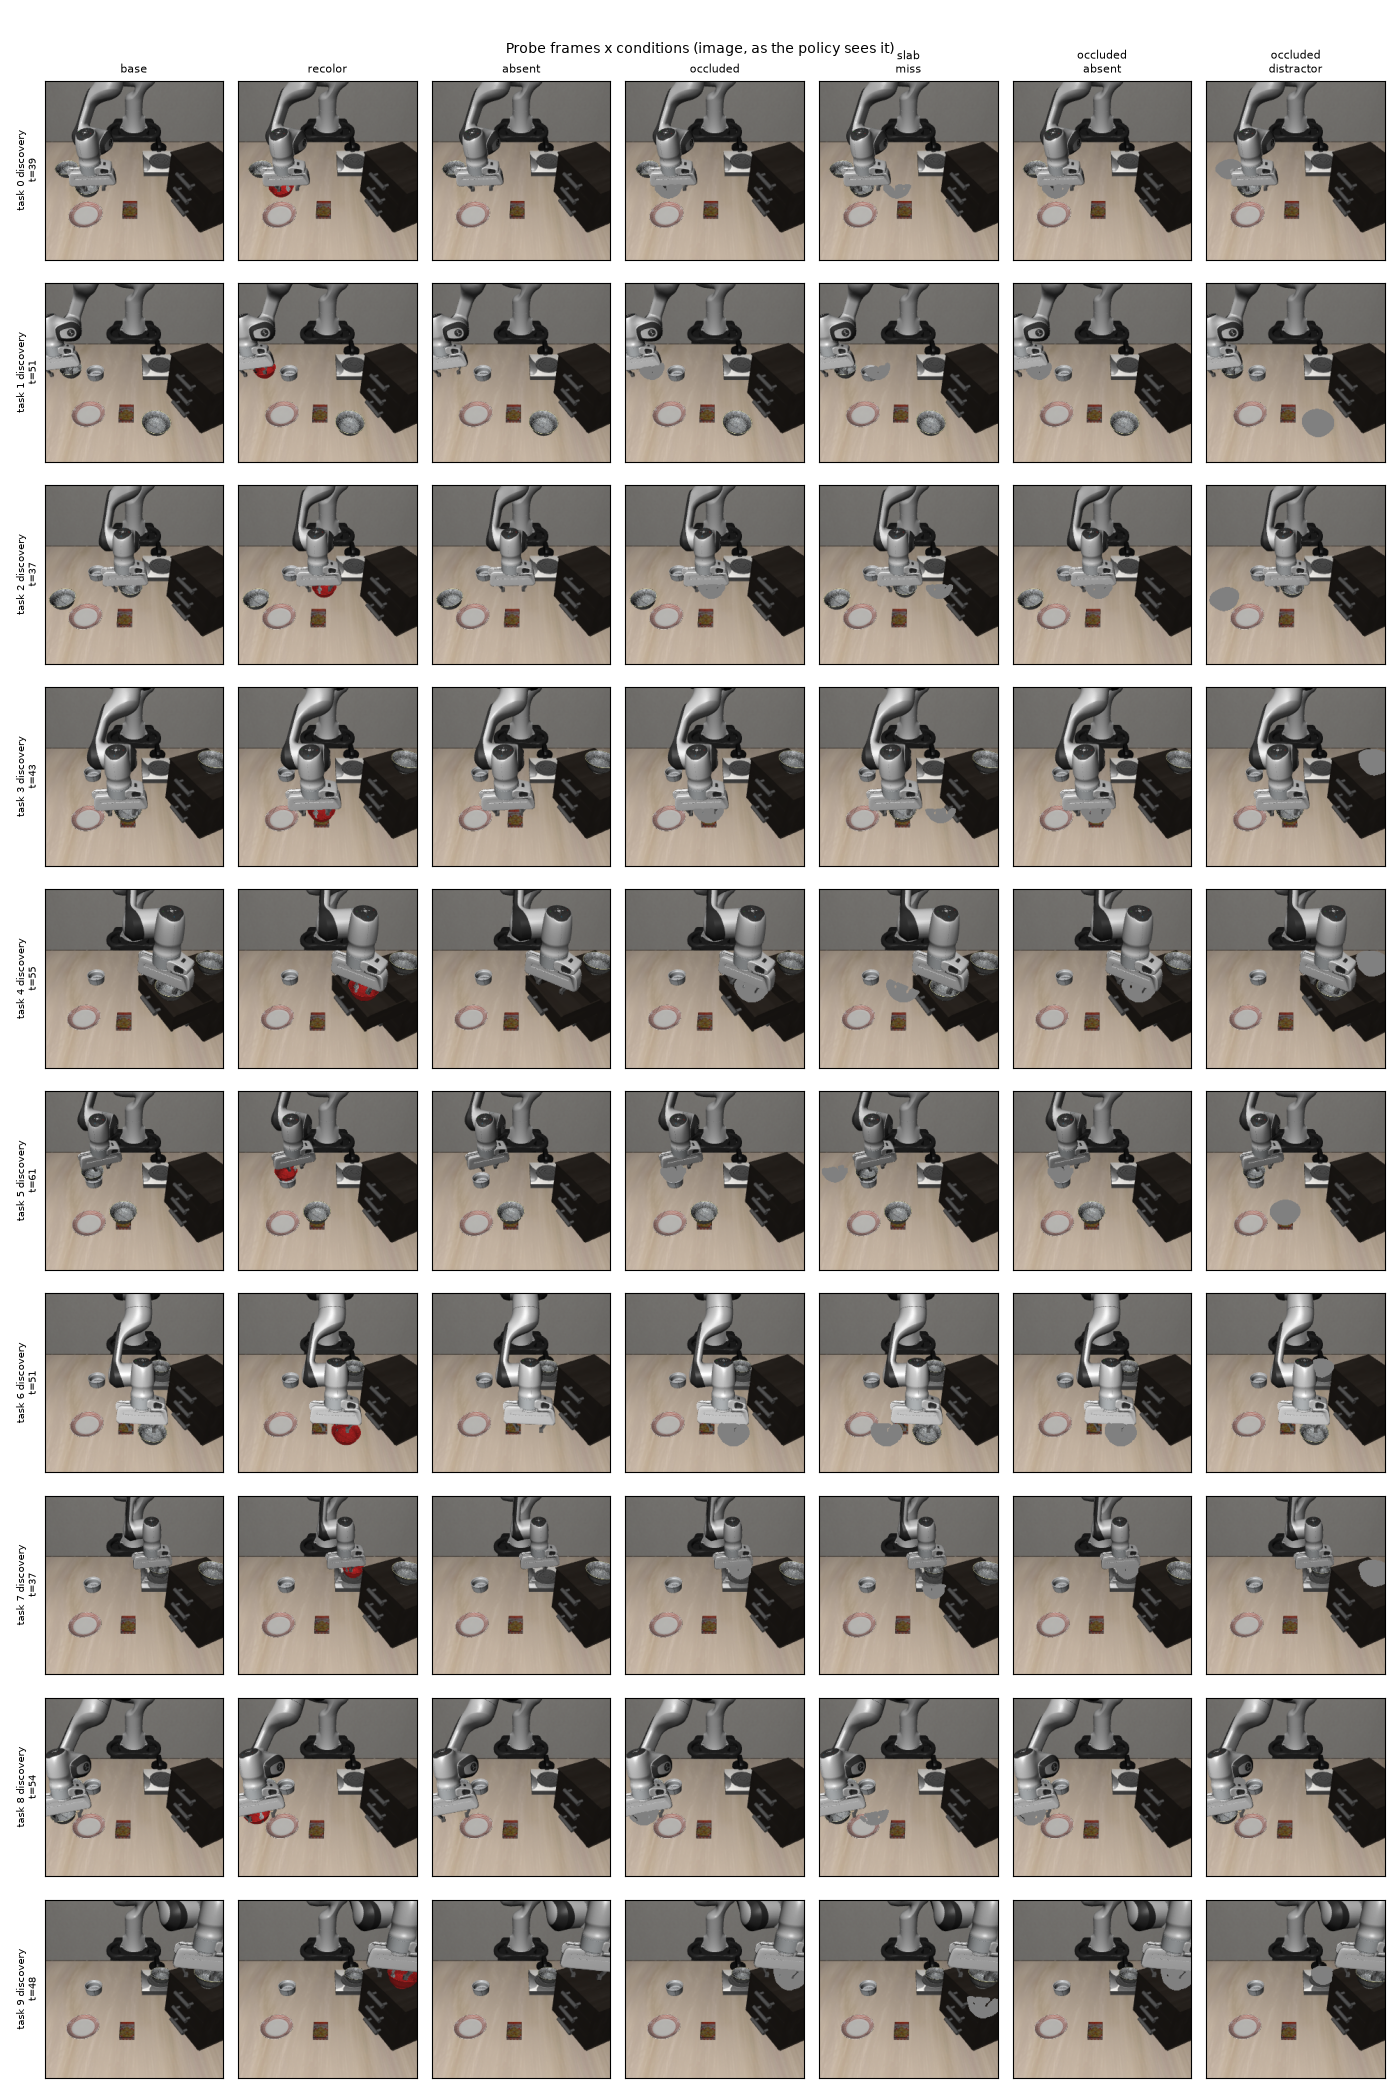

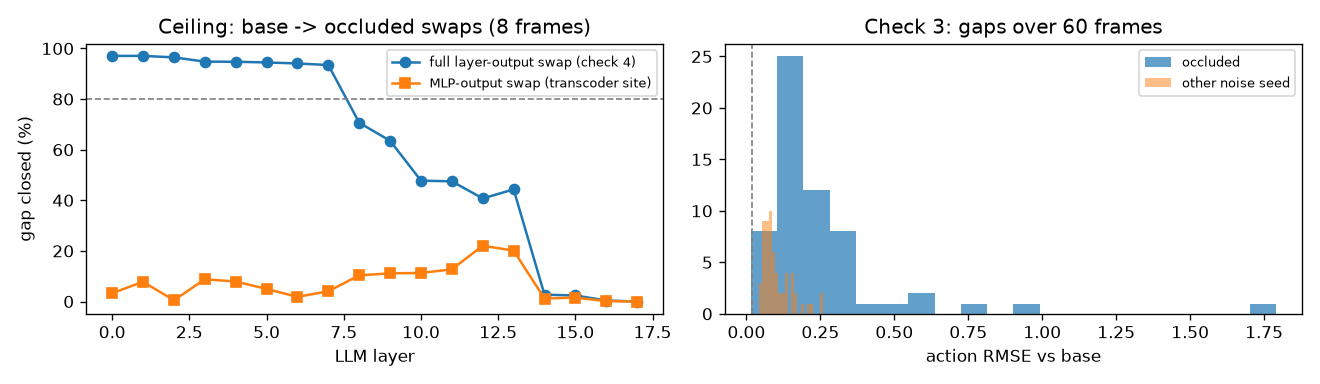

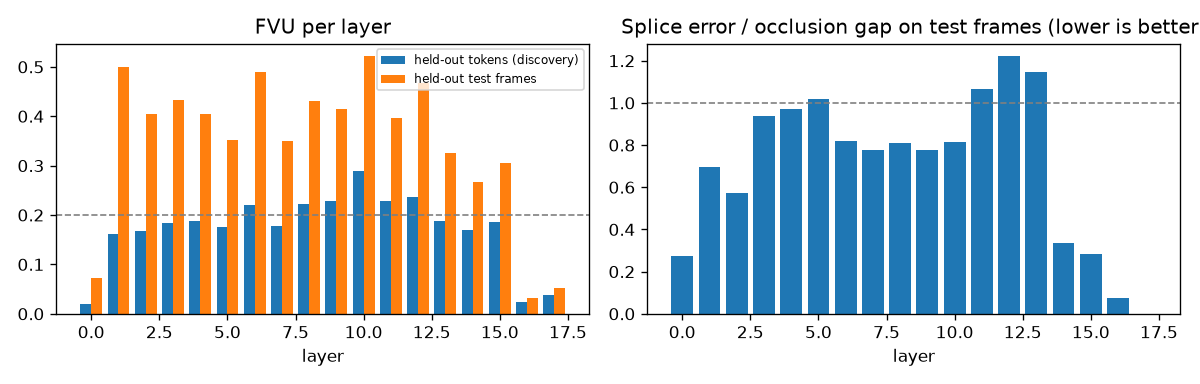

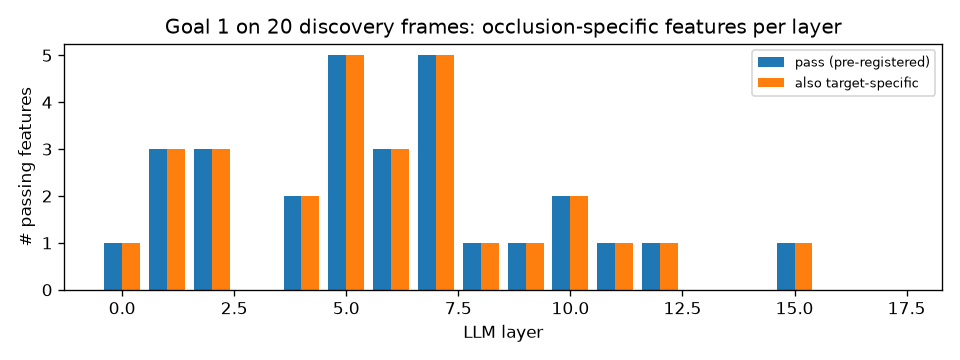

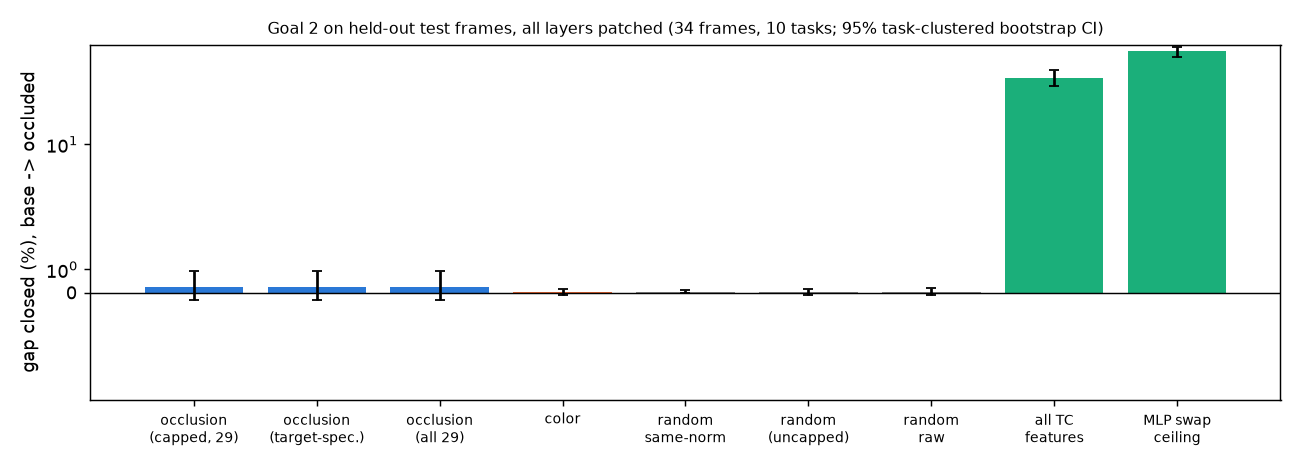

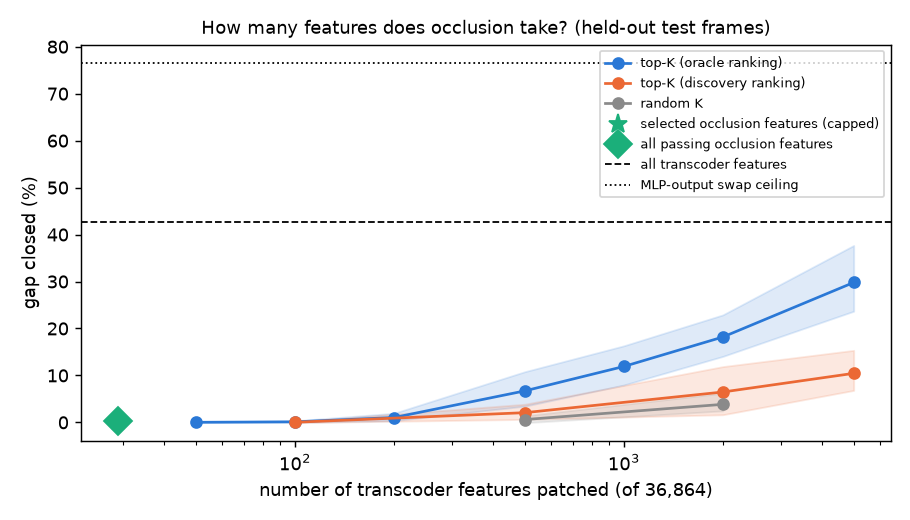

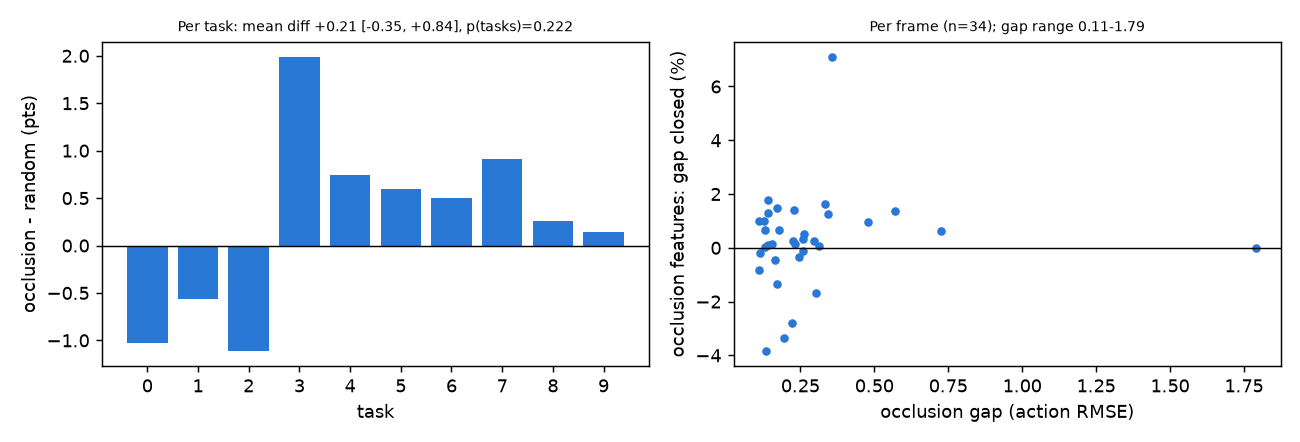

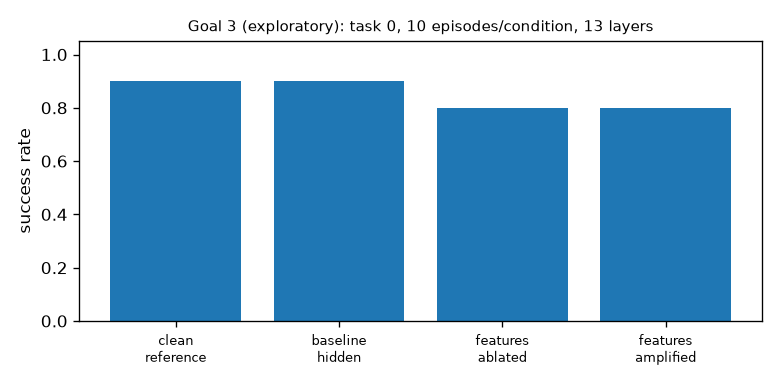

outputs: /content/groot-run/outputs/permanence/tc_circuit_v2 | Drive mirror: /content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit_v2


In [9]:
# @title Run v2: every step in one process (the policy loads once), then show the results

V2_STEPS = "frames,validate,capture,train,goal1,goal2,goal3"  # @param {type:"string"}

import json
import os
import subprocess
import time

from IPython.display import Image, Markdown, display

env = os.environ.copy()
env.update({"PYTHONUNBUFFERED": "1", "CUBLAS_WORKSPACE_CONFIG": ":4096:8", "LIBERO_CONFIG_PATH": str(LOCAL_LIBERO_CONFIG),
            "TOKENIZERS_PARALLELISM": "false"})
cmd = [str(PYTHON), "-u", str(TC_SCRIPT), V2_STEPS.replace(" ", ""), "--out", str(TC_OUT)]
print("$", " ".join(cmd), flush=True)
t_start = time.time()
log_path = TC_OUT / "run_v2.log"
proc = subprocess.Popen(cmd, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, stdin=subprocess.DEVNULL, text=True, bufsize=1)
with open(log_path, "a") as lf:
    for line in proc.stdout:
        print(line, end="", flush=True)
        lf.write(line)
        if "] == " in line and " finished in " in line:   # mirror to Drive after every step, so a dropped runtime can resume
            lf.flush()
            try:
                sync_tc_to_drive()
            except Exception as exc:
                print(f"[drive sync failed: {type(exc).__name__}: {exc}]", flush=True)
rc = proc.wait()
sync_tc_to_drive()
mins = (time.time() - t_start) / 60


def _st(step):
    p = TC_OUT / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def _f(x, nd=1, sign=False):
    try:
        return f"{float(x):+.{nd}f}" if sign else f"{float(x):.{nd}f}"
    except Exception:
        return "n/a"


def _ci(s, nd=1):
    if not s:
        return "n/a"
    return f"{_f(s.get('mean'), nd)} [{_f(s['ci95'][0], nd)}, {_f(s['ci95'][1], nd)}]"


pf = lambda x: "PASS" if x is True else ("FAIL" if x is False else "not run")
fr, v, t, g1, g2, g3 = _st("frames") or {}, _st("validate") or {}, _st("train") or {}, _st("goal1"), _st("goal2"), _st("goal3")
L = [f"### v2 run: exit code {rc} after {mins:.0f} min" + (" (stopped by a gate: an outcome, not a crash)" if rc == 3 else ""), ""]
if fr:
    L += [f"**Frames:** {fr.get('n_probe_frames')} probe frames from {fr.get('n_tasks')} tasks "
          f"({fr.get('n_discovery_frames')} discovery, {fr.get('n_test_frames')} held-out test), "
          f"{fr.get('n_frames_distractor_visible')} with the distractor bowl visible, {fr.get('n_extra_train_frames')} extra training frames.", ""]
L += ["| item | result |", "|---|---|",
      f"| Check 1: edits are clean | {pf(v.get('check1'))} |", f"| Check 2: determinism | {pf(v.get('check2'))} |",
      f"| Check 3: the signal exists | {pf(v.get('check3'))} ({_f(100 * (v.get('frac_frames_gap_ge_min') or 0), 0)}% of frames, median gap {_f(v.get('median_gap'), 3)}) |",
      f"| Check 4: the ceiling works | {pf(v.get('check4'))} ({_f(v.get('ceiling_best_pct'))}% at layer {v.get('ceiling_best_layer')}) |",
      f"| Check 5: transcoders faithful | {pf(t.get('check5'))} (median FVU {_f(t.get('median_fvu'), 3)} held-out, {_f(t.get('median_fvu_test_frames'), 3)} on test frames) |",
      f"| Goal 1: occlusion features exist | {pf(g1 and g1.get('passed'))}" + (f" ({g1.get('n_pass_total')} of {g1.get('n_features_total')} features, "
                                                                           f"{g1.get('n_pass_target_total')} also target-specific; top layers {g1.get('top_layers')})" if g1 else "") + " |",
      f"| Goal 2: they cause the action (held-out) | {pf(g2 and g2.get('passed'))} |",
      f"| Check 6: closed loop measurable | {pf(g3 and g3.get('check6'))} |",
      f"| Goal 3: task success shifts{' (exploratory)' if g3 and g3.get('exploratory') else ''} | {pf(g3 and g3.get('passed'))} |", ""]
S = json.loads((TC_OUT / "goal2_stats.json").read_text()) if (TC_OUT / "goal2_stats.json").exists() else None
if S:
    site = S["sites"].get("all", {})
    pr = S["protocol"]
    L += [f"**Goal 2, all layers patched at once** ({pr['n_included']} held-out test frames, {len(pr['tasks'])} tasks; "
          "mean gap closed % [95% task-clustered bootstrap CI])", "", "| method | gap closed % |", "|---|---|"]
    for m in ("occ_features", "occ_features_target_specific", "occ_features_uncapped", "color_features", "random_same_norm",
              "random_same_norm_uncapped", "random_raw", "all_tc_features", "mlp_swap_ceiling"):
        if m in site:
            L.append(f"| {m} | {_ci(site[m], 2)} |")
    P = S["paired"].get("all_occ_vs_random_same_norm")
    if P:
        L += ["", f"**occlusion − random (same norm):** {_f(P['mean_diff'], 2, True)} pts [{_f(P['ci95'][0], 2, True)}, {_f(P['ci95'][1], 2, True)}], "
              f"sign-flip p = {P['p_signflip_tasks']:.3g} over tasks / {P['p_signflip_frames']:.2g} over frames; "
              f"positive in {P['n_tasks_positive']}/{P['n_tasks']} tasks. Beats every random draw on "
              f"{S['occ_beats_every_random_draw']['count']}/{S['occ_beats_every_random_draw']['n']} frames.", ""]
    vd = S["verdict"]["all"]
    L += [f"**Verdict (pre-registered +{pr['margin_pts']:.0f} pt rule):** occlusion {_f(vd['occ'], 2)}% vs best control "
          f"{_f(vd['occ'] - vd['margin_vs_best_control'], 2)}% → margin {_f(vd['margin_vs_best_control'], 2, True)} pts → "
          f"**{'PASS' if vd['passed'] else 'FAIL'}**. Uncapped set ({vd.get('n_features_uncapped')} features): "
          f"{_f(vd.get('occ_uncapped'), 2)}% vs random {_f(vd.get('random_same_norm_uncapped'), 2)}%.", ""]
    kc = S["kcurve"]
    L += ["**k-curve** (features patched → gap closed %): "
          + " · ".join(f"{fam}: " + ", ".join(f"K={p['k']}: {_f(p.get('mean'))}" for p in kc[fam]) for fam in ("oracle", "discovery", "random") if kc[fam])
          + f" · all {kc['n_total_features']:,} features: {_f((kc.get('all_tc') or {}).get('mean'))}", ""]
    em = S.get("edit_mass_and_overlap") or {}
    if em.get("n_features_for_50pct_edit_mass"):
        L += [f"**Distributedness:** half of the occlusion-induced MLP-output change is carried by a median of "
              f"{_f(em['n_features_for_50pct_edit_mass']['median'], 0)} features (80%: {_f(em['n_features_for_80pct_edit_mass']['median'], 0)}); "
              f"the selected set carries {_f((em.get('capped_share_of_edit_mass_pct') or {}).get('median'))}% of it.", ""]
    H = S.get("heldout_selectivity") or {}
    L += [f"**Held-out replication of Goal 1:** {_f(100 * (H.get('replicate_frac_capped') or 0), 0)}% of the selected features pass the same "
          f"selectivity rule on the test frames (random features: {_f(100 * (H.get('replicate_frac_random_draws_mean') or 0), 1)}%, "
          f"all features: {_f(100 * (H.get('replicate_frac_all_alive_base_rate') or 0), 1)}%); Spearman ρ of the occlusion response "
          f"discovery vs test = {_f(H.get('spearman_d_occluded_discovery_vs_test_all_alive'), 2)}; distractor/target response ratio "
          f"(selected features) = {_f(H.get('distractor_over_occluded_median_capped'), 2)}.", ""]
if g3:
    L += [f"**Goal 3{' (exploratory)' if g3.get('exploratory') else ''}:** task {g3.get('task_id')}, {g3.get('n_episodes')} episodes/condition, "
          f"success {json.dumps({k: round(x, 2) for k, x in (g3.get('success') or {}).items()})}"]
    for k, s in (g3.get("stats") or {}).items():
        L.append(f"- {k}: diff vs baseline {_f(s['diff_vs_baseline'], 2, True)} [{_f(s['ci95'][0], 2, True)}, {_f(s['ci95'][1], 2, True)}]")
display(Markdown("\n".join(L)))
for name in ("fig_probe_conditions_agentview.png", "fig_check4_ceiling.png", "fig_check5_transcoders.png", "fig_goal1_counts.png",
             "fig_goal2_main.png", "fig_goal2_kcurve.png", "fig_goal2_per_task.png", "fig_goal3_success.png"):
    p = TC_OUT / name
    if p.exists():
        display(Image(filename=str(p)))
if rc not in (0, 3):
    raise RuntimeError(f"tc_occlusion.py failed (exit code {rc}) after {mins:.0f} min. The log is above and in {log_path}. "
                       "Re-run this cell with V2_STEPS set to the remaining steps once it is fixed (finished steps are kept).")
print("outputs:", TC_OUT, "| Drive mirror:", DRIVE_TC)

### Download (v2)
One zip with RESULTS.md, every figure, table and status file, the script, config and this notebook. Transcoders and frames.pkl stay on Drive unless you tick the boxes.

In [ ]:
# @title Download everything (v2): one zip to your computer (+ a copy on Drive)

import json
import shutil
import subprocess
import time
import zipfile
from pathlib import Path

# v2 transcoders are ~600 MB and frames.pkl ~300 MB; both stay on Drive (DRIVE_TC) either way.
INCLUDE_TRANSCODERS = True  # @param {type:"boolean"}
INCLUDE_PROBE_FRAMES = True  # @param {type:"boolean"}
INCLUDE_ACTIVATION_CACHE = True  # @param {type:"boolean"}
COPY_ZIP_TO_DRIVE = True  # @param {type:"boolean"}

g = globals()
out = Path(g.get("TC_OUT", "/content/groot-run/outputs/permanence/tc_circuit_v2"))
drive_tc = Path(g.get("DRIVE_TC", "/content/drive/MyDrive/groot-run-shared-programmer908/outputs/permanence/tc_circuit_v2"))
if not (out / "status").exists() and (drive_tc / "status").exists():
    print("Local results not found; using the Drive mirror:", drive_tc)
    out = drive_tc
if not (out / "status").exists():
    raise FileNotFoundError(f"No results found in {out} or {drive_tc}. Run the v2 cells first.")
script = Path(g.get("TC_SCRIPT", "/content/groot-run/scripts/tc_occlusion.py"))
python = str(g.get("PYTHON", "/content/lerobot-venv/bin/python"))

stamp = time.strftime("%Y%m%d_%H%M")
name = f"tc_circuit_v2_results_{stamp}"
bundle = Path("/content") / name
if bundle.exists():
    shutil.rmtree(bundle)
(bundle / "results").mkdir(parents=True)
(bundle / "code").mkdir()
(bundle / "env").mkdir()

skip = {"acts"} if not INCLUDE_ACTIVATION_CACHE else set()
if not INCLUDE_TRANSCODERS:
    skip.add("transcoders")
if not INCLUDE_PROBE_FRAMES:
    skip.add("frames.pkl")
shutil.copytree(out, bundle / "results", dirs_exist_ok=True, ignore=lambda d, names: [n for n in names if Path(d) == out and n in skip])
# (per-layer transcoder metrics are in results/train.json either way)

if script.exists():
    shutil.copy2(script, bundle / "code" / "tc_occlusion.py")
if (out / "config.json").exists():
    shutil.copy2(out / "config.json", bundle / "code" / "config.json")
try:
    from google.colab import _message

    nb = _message.blocking_request("get_ipynb", timeout_sec=60)["ipynb"]
    (bundle / "code" / "notebook.ipynb").write_text(json.dumps(nb, indent=1))
    print("saved the notebook (with outputs) into the bundle")
except Exception as exc:
    print(f"could not export the notebook itself ({type(exc).__name__}); use File -> Download -> .ipynb for it")


def _run(cmd):
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=120)
        return (r.stdout or "") + (r.stderr or "")
    except Exception as exc:
        return f"{cmd}: {exc}"


(bundle / "env" / "packages.txt").write_text(_run([python, "-c",
    "import importlib.metadata as m; print('\\n'.join(sorted(f\"{d.metadata['Name']}=={d.version}\" for d in m.distributions())))"]))
(bundle / "env" / "versions.txt").write_text(_run([python, "-c",
    "import sys, lerobot, transformers, torch, numpy, mujoco; print('python', sys.version); "
    "print('lerobot', lerobot.__version__); print('transformers', transformers.__version__); "
    "print('torch', torch.__version__, 'cuda', torch.version.cuda); print('numpy', numpy.__version__); print('mujoco', mujoco.__version__)"]))
(bundle / "env" / "gpu.txt").write_text(_run(["nvidia-smi"]))


# ---------------------------------------------------------------- RESULTS.md
def _st(step):
    p = out / "status" / f"{step}.json"
    return json.loads(p.read_text()) if p.exists() else None


def _f(x, nd=1, sign=False):
    try:
        return f"{float(x):+.{nd}f}" if sign else f"{float(x):.{nd}f}"
    except Exception:
        return "n/a"


def _ci(s, nd=2):
    return f"{_f(s.get('mean'), nd)} [{_f(s['ci95'][0], nd)}, {_f(s['ci95'][1], nd)}]" if s else "n/a"


pf = lambda x: "PASS" if x is True else ("FAIL" if x is False else "not run")
fr, v, t = _st("frames") or {}, _st("validate") or {}, _st("train") or {}
g1, g2, g3 = _st("goal1"), _st("goal2"), _st("goal3")
tm = _st("timings") or {}
cfg = json.loads((out / "config.json").read_text()) if (out / "config.json").exists() else {}
S = json.loads((out / "goal2_stats.json").read_text()) if (out / "goal2_stats.json").exists() else None
L = ["# Transcoder circuit tracing on π0.5 (LIBERO), protocol v2: results", "",
     f"Bundle created {time.strftime('%Y-%m-%d %H:%M')} from `{out}`. Total run time: {_f((tm.get('total_s') or 0) / 60, 0)} min.", "",
     f"Policy `{cfg.get('policy_path')}` · suite `{cfg.get('suite')}` tasks {cfg.get('task_ids')} · "
     f"{fr.get('n_probe_frames')} probe frames ({fr.get('n_discovery_frames')} discovery / {fr.get('n_test_frames')} held-out test) · "
     f"transcoders {cfg.get('tc_features')} features, k={cfg.get('tc_k')}, {cfg.get('tc_steps')} steps, trained on discovery samples only", "",
     "## What changed from v1", "",
     "- 10 tasks instead of 1; 60 probe frames instead of 4.",
     "- Frames sit at fixed phases (0.4, 0.8) of the pre-grasp window instead of being picked for the largest occlusion effect.",
     "- Discovery / test split by demonstration: features and transcoders use demo 0 (+ unedited frames from demos 3-4); "
     "the causal test uses demos 1-2 only.",
     "- New control condition `occluded_distractor`: the same gray paint on the second, identical bowl.",
     "- 4x wider transcoders (2048 features, k=32), FVU and splice also measured on held-out test frames.",
     "- Goal 2: 10 random draws, uncapped and target-specific feature sets, a k-curve (how many features it takes), "
     "task-clustered bootstrap CIs, sign-flip permutation tests, held-out replication of Goal-1 selectivity.",
     "- Primary Goal-2 site is all layers at once (pre-registered here; it was a post-hoc extension in v1). Same +10 pt rule.",
     "- Goal 3 runs as an explicitly exploratory closed-loop check (10 episodes/condition) when Goal 2 fails.", "",
     "## Checks and goals", "", "| item | result |", "|---|---|",
     f"| Check 1: edits are clean | {pf(v.get('check1'))} |", f"| Check 2: determinism | {pf(v.get('check2'))} |",
     f"| Check 3: the signal exists | {pf(v.get('check3'))} ({_f(100 * (v.get('frac_frames_gap_ge_min') or 0), 0)}% of frames ≥ {cfg.get('min_gap')}; median gap {_f(v.get('median_gap'), 3)}) |",
     f"| Check 4: the ceiling works | {pf(v.get('check4'))} ({_f(v.get('ceiling_best_pct'))}% at layer {v.get('ceiling_best_layer')}; threshold {cfg.get('ceiling_min_pct')}%) |",
     f"| Check 5: transcoder is faithful | {pf(t.get('check5'))} (median FVU {_f(t.get('median_fvu'), 3)} held-out tokens, {_f(t.get('median_fvu_test_frames'), 3)} held-out test frames) |",
     f"| Goal 1: occlusion features exist | {pf(g1 and g1.get('passed'))} |",
     f"| Goal 2: they cause the action (held-out test frames) | {pf(g2 and g2.get('passed'))} |",
     f"| Check 6: closed loop measurable | {pf(g3 and g3.get('check6'))} |",
     f"| Goal 3: task success shifts{' (exploratory)' if g3 and g3.get('exploratory') else ''} | {pf(g3 and g3.get('passed'))} |", ""]
if g1:
    L += ["## Goal 1 (discovery frames)", "",
          f"- {g1.get('n_pass_total')} of {g1.get('n_features_total')} features pass ({_f(g1.get('pass_frac_pct'), 2)}%); "
          f"{g1.get('n_pass_target_total')} also stay quiet when the distractor bowl is painted.",
          f"- Median distractor/target response ratio among passing features: {_f(g1.get('median_distractor_over_occluded_passing'), 2)}.",
          f"- Top layers: {g1.get('top_layers')}. Passing features per layer: {g1.get('n_pass_per_layer')}.", ""]
if S:
    pr = S["protocol"]
    site = S["sites"].get("all", {})
    L += ["## Goal 2 (held-out test frames, all layers patched at once)", "",
          f"{pr['n_included']} of {pr['n_test_frames']} test frames (gap ≥ {pr['min_gap']}), {len(pr['tasks'])} tasks. "
          "Gap closed %, mean [95% task-clustered bootstrap CI].", "", "| method | gap closed % |", "|---|---|"]
    for m, s in site.items():
        L.append(f"| {m} | {_ci(s)} |")
    L.append("")
    for k, P in S["paired"].items():
        if P:
            L.append(f"- {k}: {_f(P['mean_diff'], 2, True)} pts [{_f(P['ci95'][0], 2, True)}, {_f(P['ci95'][1], 2, True)}], "
                     f"p(tasks) = {P['p_signflip_tasks']:.3g}, p(frames) = {P['p_signflip_frames']:.2g}, "
                     f"positive in {P['n_tasks_positive']}/{P['n_tasks']} tasks")
    vd = S["verdict"]["all"]
    L += ["", f"**Verdict:** margin {_f(vd['margin_vs_best_control'], 2, True)} pts vs the +{pr['margin_pts']:.0f} pt rule → "
          f"{'PASS' if vd['passed'] else 'FAIL'}. Occlusion features = {_f(vd['occ_share_of_ceiling_pct'])}% of the MLP-swap ceiling.", ""]
    kc = S["kcurve"]
    L += ["### k-curve", "", "| ranking | " + " | ".join(f"K={p['k']}" for p in kc["oracle"]) + " |",
          "|---|" + "---|" * len(kc["oracle"]),
          "| oracle (this frame) | " + " | ".join(_f(p.get("mean")) for p in kc["oracle"]) + " |", ""]
    L += ["Discovery-ranked: " + ", ".join(f"K={p['k']}: {_f(p.get('mean'))}%" for p in kc["discovery"]) +
          " · random K: " + ", ".join(f"K={p['k']}: {_f(p.get('mean'))}%" for p in kc["random"]) +
          f" · all {kc['n_total_features']:,} features: {_f((kc.get('all_tc') or {}).get('mean'))}%", ""]
    L += ["### Other Goal-2 numbers", "", "```json", json.dumps({k: S[k] for k in ("edit_mass_and_overlap", "heldout_selectivity",
                                                                                   "occ_beats_every_random_draw", "scopes", "remove",
                                                                                   "single_features", "edges")}, indent=1, default=str), "```", ""]
if g3:
    L += [f"## Goal 3{' (exploratory)' if g3.get('exploratory') else ''}", "", f"- Task {g3.get('task_id')}, {g3.get('n_episodes')} episodes per condition.",
          f"- Success: {g3.get('success')}", f"- Stats: {json.dumps(g3.get('stats'))}", ""]
L += ["## Files", "", "- `results/`: figures (`fig_*.png`), `goal2_stats.json` (every number above), `goal2_circuit_trace_table.md/.csv`, "
      "`goal2_rows.csv` (per frame × method), `goal2_frames.json`, `goal2_test_feature_sums.npy`, `goal1_feature_table.csv`, "
      "`goal1_selected.json`, `validate.json`, `train.json`, `status/`, `run_v2.log`.",
      "- `code/`: `tc_occlusion.py`, `config.json`, `notebook.ipynb`.", "- `env/`: package versions and GPU."]
(bundle / "RESULTS.md").write_text("\n".join(L) + "\n")

zip_path = Path("/content") / f"{name}.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED, compresslevel=6) as z:
    for p in sorted(bundle.rglob("*")):
        if p.is_file():
            z.write(p, arcname=str(Path(name) / p.relative_to(bundle)))
size_mb = zip_path.stat().st_size / 2**20
print(f"\nbundle: {zip_path}  ({size_mb:.1f} MB, {sum(1 for p in bundle.rglob('*') if p.is_file())} files)")
if COPY_ZIP_TO_DRIVE:
    try:
        dst = drive_tc.parent / zip_path.name
        shutil.copy2(zip_path, dst)
        print("Drive copy:", dst)
    except Exception as exc:
        print(f"Drive copy failed ({type(exc).__name__}: {exc})")
try:
    from google.colab import files

    files.download(str(zip_path))
    print("download started in your browser")
except Exception as exc:
    print(f"browser download not available ({type(exc).__name__}); grab the zip from the Files panel or the Drive copy")